## Setup

### Imports

In [1]:
%load_ext autoreload
%autoreload 3 --print
# import os; os.environ['JAX_PLATFORM_NAME'] = 'cpu'
# import os; os.environ['XLA_PYTHON_CLIE|NT_MEM_FRACTION'] = '.95'

In [2]:
from shape_norm.project.paths import Project, create_model
from shape_norm.io import loaders
from shape_norm.models import joint
from shape_norm import config
from shape_norm.models import instantiation, setup, pose, morph, util as model_util
from shape_norm import fitting
from shape_norm.fitting import em
from shape_norm.io import alignment, features
from shape_norm.io.armature import Armature
from shape_norm.fitting import methods
from shape_norm.fitting import scans
from shape_norm.pca import fit_with_center, CenteredPCA, PCAData
from shape_norm.io.dataset import PytreeDataset
from shape_norm.io.dataset_refactor import Dataset, SessionMetadata, StackedArrayMetadata
from shape_norm.models.morph.lowrank_affine import LRAParams, model as lra_model
from shape_norm import clouds
from shape_norm import pca
from blscale_loader import loader, linear_skeletal as blscale_ls
import os, sys, shutil
import numpy as np
from pprint import pprint
from matplotlib import colors as mpl_col
import jax.numpy as jnp
import itertools as iit
from scipy import optimize
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.mixture import GaussianMixture
import matplotlib as mpl
from sklearn.decomposition import PCA
import pandas as pd
import seaborn as sns
from shape_norm import viz
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from shape_norm.viz import styles
from scipy.spatial.distance import jensenshannon
from tensorflow_probability.substrates import jax as tfp
from ruamel.yaml import YAML
from bidict import bidict
import matplotlib.pyplot as plt
from collections import defaultdict
import os, re
import tqdm
from cmap import Colormap
import joblib as jl

from pathlib import Path
import logging
logging.getLogger().setLevel(logging.INFO)

### Supporting functions

#### KPSN utility functions


In [3]:
from supporting_funcs.shapenorm_helpers import single_session_dataset, lra_anchor_poses, anchor_keypoints, unalign_scales, anchor_magnitudes, merge_morphs

# def single_session_dataset(data, body, session, meta: SessionMetadata):
#     session_id = meta.session_id(session)
#     body_id = meta.body_id(body)
#     return Dataset(
#         data=data,
#         session_meta=meta.update(
#             session_bodies={**meta._session_bodies, session_id: body_id}
#         ),
#         stack_meta=StackedArrayMetadata(
#             slices={session_id: (0, len(data))}, length=len(data)
#         ),
#     )


# # model manipulation
# def lra_anchor_poses(params: LRAParams, magnitudes=90):
#     """
#     Parameters:
#     params (LRAParams):
#         Parameters used for calculating anchor poses.
#     magnitudes (float, numpy.ndarray):
#         The magnitude value used in calculating anchor poses. If a float, the
#         same magnitude is used for all anchors. If an array, the magnitude
#         for each dimension is specified separately. Not applied to the centroid
#         anchor.

#     Returns, (array, shape (n_bodies, n_dims, n_modes + 1)):
#     numpy.ndarray:
#         The anchor poses in the canonical pose space.
#     """

#     L = params.n_dims

#     if isinstance(magnitudes, (int, float)):
#         magnitudes = magnitudes * np.ones(L)

#     # (n_bodies, n_dims, 1)
#     anchors = (params.offset + params.offset_updates).reshape(
#         params.n_bodies, -1, 1
#     )
#     # (n_bodies, n_dims, n_modes + 1)
#     anchors = np.concatenate(
#         [
#             anchors,
#             anchors
#             + magnitudes[None, None] * (params.modes + params.mode_updates),
#         ],
#         axis=-1,
#     )

#     return anchors


# def anchor_keypoints(
#     params: LRAParams,
#     align_meta: dict,
#     magnitudes=90,
#     _inflate=None,
#     config=None,
#     session_meta: SessionMetadata = None,
# ):
#     """
#     Calculate and return the anchor poses from a model in the original keypoint
#     space.

#     This function computes anchor poses based on the provided parameters and
#     alignment metadata, inflates the poses based on a given configuration (if
#     any), and then applies inverse alignment scaling to return the poses in
#     their original keypoint space.

#     Parameters
#     ----------
#     params, dict:
#         Parameters used for calculating anchor poses.
#     session_meta, SessionMetadata, optional:
#         Session metadata object (accessible via dataset.session_meta) for
#         mapping body indices to session indices for rescaling. Required if
#         align_meta is provided. If provided, first index of output is over
#         session ids, not body ids.
#     align_meta, dict:
#         Metadata for alignment, optionally including scaling factors under the
#         key `scale`.
#     magnitudes, int, optional:
#         The magnitude value used in calculating anchor poses. Defaults to 90.
#     _inflate, function, optional:
#         A custom function to inflate anchor poses. If None, a default inflation
#         based on the 'features' configuration is used.
#     config, dict, optional:
#         Configuration dictionary that, if provided, is used to inflate the
#         anchor poses using the '_inflate' function. It should contain a
#         'features' key if'_inflate' is not provided.

#     Returns
#     -------
#     numpy.ndarray, shape (n_bodies or n_sessions, n_anchor, n_keypt, n_spatial):
#         The anchor poses in the original keypoint space after applying inverse
#         alignment scaling. If session_meta is provided, the first index is over
#         sessions instead of bodies.



#     """
#     if _inflate is None:
#         _inflate = lambda x: features.inflate(x, config["features"])
#     anchor_poses = lra_anchor_poses(
#         params, magnitudes
#     )  # (n_bodies, n_feat, n_anch)
#     inflated = _inflate(anchor_poses.transpose(0, 2, 1))
#     if session_meta is not None:
#         inflated = jnp.array(
#             [
#                 inflated[session_meta.session_body_id(i)]
#                 for i in range(len(session_meta._session_ids))
#             ]
#         )
#         if "scale" in align_meta:
#             inflated = alignment._inverse_align_scales(
#                 inflated, align_meta["scale"][:, None], stacked=True
#             )
#     return inflated


# def unalign_scales(align_meta, dataset, split_meta=None, base_dataset=None):
#     """
#     Invert scaling alignment, potentially on a split dataset

#     Parameters
#     ----------
#     align_meta : dict
#         The alignment metadata, containing an array under key 'scale' whose
#         $i$th element is the scale factor to be applied to sesssion with id $i$.
#     dataset : Dataset
#         The dataset to invert the scaling on.
#     split_meta : tuple, optional
#         Tuple whos second element (index 1) maps original session names (in
#         `dataset`) to the names of sessions in `dataset`.
#     base_dataset : Dataset, optional
#         Dataset with session ids that match the indices of
#         `align_meta['scale']`. Can be provided if `dataset` is a split dataset
#         where alignment was already performed before splitting.
#     """
#     if base_dataset is not None:
#         scan_align_meta = {"scale": np.array([-1.0 for _ in dataset.sessions])}
#         for src_sess, splits in split_meta[1].items():
#             for s in splits:
#                 scan_align_meta["scale"][dataset.session_id(s)] = align_meta[
#                     "scale"
#                 ][base_dataset.session_id(src_sess)]
#         align_meta = scan_align_meta
#     return (
#         alignment._inverse_align_scales(dataset, align_meta["scale"]),
#         align_meta,
#     )


# def anchor_magnitudes(
#     dataset: Dataset, params: LRAParams, q=0.9, canonicalized=False
# ):
#     """
#     Sample the `q`th percentile in absolute value from distributions of anchor
#     pose coordinates.

#     Parameters
#     ----------
#     dataset : Dataset or jnp.array
#         Feature data, in canonical pose space if `canonicalized` is True. If an
#         array, it is assumed to be in canonical pose space.
#     model : MorphModel
#     params : LRAParams
#         Parameters of the model.
#     q : float, default 0.9
#         The quantile to sample from.
#     canonicalized : bool, default False
#         Whether the dataset is already in canonical pose space (magnitudes are
#         not session- or body-dependent)

#     Returns
#     -------
#     magnitudes : array, shape (n_modes,)
#         The selected magnitude in each morph mode.
#     """
#     if canonicalized:
#         canonical = dataset.data
#     elif isinstance(dataset, jnp.ndarray):
#         canonical = dataset
#     else:
#         canonical = model_util.apply_bodies(
#             lra_model,
#             params,
#             dataset,
#             {
#                 s: dataset.session_body_name(dataset.ref_session)
#                 for s in dataset.sessions
#             },
#         ).data

#     coords = canonical @ params.modes  # (n_pts, n_modes)
#     qix = jnp.argsort(coords, axis=0)[int(coords.shape[0] * q)]  # argquantile
#     selected_coord = coords[qix, jnp.arange(coords.shape[1])]
#     return selected_coord


# def merge_morphs(
#     params: LRAParams,
#     merged_session_meta: SessionMetadata,
#     split_session_meta: SessionMetadata,
#     split_meta: dict,
# ):
#     """
#     Merge morph parameters from a split dataset into a single dataset.

#     Parameters
#     ----------
#     params : LRAParams
#         The morph parameters.
#     merged_session_meta, split_session_metadata : SessionMetadata
#         Session metadata object (accessible via dataset.session_meta) for
#         identifying body ids.
#     split_meta : dict
#         Metadata for the split dataset, containing a mapping original body names
#         to sessions in the split dataset.

#     Returns
#     -------
#     numpy.ndarray, shape (n_sessions, n_modes, n_dims)
#         The merged morph parameters.
#     """
#     body_inv = {
#         b: [split_session_meta.session_body_name(s) for s in split_meta[b]]
#         for b in split_meta
#     }
#     new_nbod = len(merged_session_meta._body_ids)
#     new_ref = None
#     mode_upds = np.zeros((new_nbod, params.n_feats, params.n_dims))
#     ofs_upds = np.zeros((new_nbod, params.n_feats))
#     for i in range(new_nbod):
#         merged_bod = merged_session_meta.body_name(i)
#         i_mode_upds = []
#         i_ofs_upds = []
#         for split_bod in body_inv[merged_bod]:
#             j = split_session_meta.body_id(split_bod)
#             i_mode_upds.append(params.mode_updates[j])
#             i_ofs_upds.append(params.offset_updates[j])
#             if j == params.ref_body:
#                 new_ref = i
#         mode_upds[i] = np.mean(i_mode_upds, axis=0)
#         ofs_upds[i] = np.mean(i_ofs_upds, axis=0)

#     return LRAParams(
#         {
#             **params._tree,
#             **dict(
#                 n_bodies=new_nbod,
#                 ref_body=new_ref,
#                 _mode_updates=jnp.array(mode_upds),
#                 _offset_updates=jnp.array(ofs_upds),
#             ),
#         }
#     )

#### Dataset utility functions

In [4]:
from supporting_funcs.keypoint_data import mouse_data_armature_meta, _with_match, _name_func, load_all_mouse_sessions

# def mouse_data_armature_meta():
#     """Organize metadata on keypoints and skeleton of mouse data."""
#     names = [
#         'shldr', 'back', 'hips', 't_base','t_tip', 'head',
#         'l_ear', 'r_ear', 'nose', 'lr_knee', 'lr_foot',
#         'rr_knee', 'rr_foot', 'lf_foot', 'rf_foot']
#     parents = dict(zip(names, [
#         'back', 'hips', None, 'hips', 't_base', 'shldr',
#         'head', 'head', 'head', 'hips', 'lr_knee',
#         'hips', 'rr_knee', 'shldr', 'shldr']))
#     keypt_ix = lambda name: names.index(name)
#     bones = np.array([(keypt_ix(c), keypt_ix(p)) for c, p in parents.items() if p])
#     root = keypt_ix("shldr")
#     bones = blscale_ls.reroot(bones, root)
#     bones = bones[np.argsort(bones[:, 0])]
#     return names, parents, bones, root

# _with_match = lambda test, pattern, f: f(m) if (m := re.search(pattern, test)) else None
# _name_func = lambda path, *a: _with_match(
#     path, r"(?:/.*)+/\d{2}_\d{2}_\d{2}_(\d+wk_m\d+)\.npy",
#     lambda m: f"{m.group(1)}")

# def load_all_mouse_sessions(age_whitelist = None):
#     data_root = '../../../../data_explore/data'

#     # Create mapping of session names (ie 3wk_m0) to keypoint data paths

#     modata_npy_name_func = (lambda path, *a:
#         match.group(1) if ((match := re.search(r"\d{2}_\d{2}_\d{2}_(\d+wk_m\d+)\.npy", path)) is not None) else None)
#     session_paths = dict(filter(lambda x: x[0] is not None, [(modata_npy_name_func(m), str(Path(data_root) / m)) for m in os.listdir(data_root)]))
#     # throw out 9-12 week
#     session_ages = {s: s.split('_')[0].strip('wk') for s in session_paths}
#     ages = set(session_ages.values())
#     if age_whitelist is not None:
#         ages = list(filter(lambda x: x in age_whitelist, ages))
#     session_paths = {s: p for s, p in session_paths.items() if session_ages[s] in ages}
#     session_bodies = {s: f'body-{session_ages[s]}wk' for s in session_paths}
#     names, parents, _, _ = mouse_data_armature_meta()

#     age_dates =  {
#         "3" : "10_11_22",
#         "5" : "10_24_22",
#         "7" : "10_24_22",
#         "24": "11_03_22",
#         "52" : "11_03_22",
#         "72" : "10_14_22",
#     }

#     print("sessions:", session_paths.keys())

#     sesssion_kps = {
#         s: np.load(p) for s, p in session_paths.items()
#     }

#     project_config_kws = {
#         "session_names": list(sesssion_kps.keys()),
#         "bodies": session_bodies,
#         "keypoint_names": names,
#         "keypoint_parents": parents,
#     }

#     return project_config_kws, sesssion_kps

#### Plotting utility functions

In [5]:
from supporting_funcs.plotting import getc, plot_mouse_3d, plotdrop

# def getc(spec):
#     try:
#         from cmap import Colormap, Color
#         try:
#             return Color(spec)
#         except ValueError as e:
#             stop = spec.split(':')[-1]
#             if stop.startswith('.'):
#                 stop = float(stop)
#             else:
#                 stop = int(stop)
#             cm = Colormap(':'.join(spec.split(':')[:-1]))
#             return cm(stop)
#     except ImportError:
#         return spec

# def plot_mouse_3d(
#     frame,
#     ax,
#     armature,
#     elev,
#     rot,
#     colors=None,
#     bone_n=40,
#     point_size=10,
#     line_size=2,
#     line_colors=None,
#     point_kws={},
#     line_kws={},
#     boundary=True,
#     set_aspect=True,
#     label = None
# ):
#     """all keys in point kws should be present in line kws"""

#     if colors is None:
#         import seaborn as sns

#         colors = mpl_col.to_rgba(sns.color_palette("Blues", 10 + frame.shape[0])[10:])
#     if line_colors is None:
#         line_colors = colors
#     colors = np.array([mpl_col.to_rgba(x) for x in colors])
#     line_colors = np.array([mpl_col.to_rgba(x) for x in line_colors])
#     point_kws = {
#         **dict(
#             linewidths=np.array([0] * armature.n_kpts),
#         ),
#         **point_kws,
#     }
#     line_kws = {
#         **dict(
#             linewidths=np.array([0] * armature.n_kpts),
#         ),
#         **line_kws,
#     }

#     # --- points

#     x, y, z, c, s = [], [], [], [], []
#     x.append(frame[:, 0])
#     y.append(frame[:, 1])
#     z.append(frame[:, 2])
#     c.append(colors)
#     s.append([point_size] * armature.n_kpts)
#     kws = {k: [] for k in point_kws}
#     concat_keys = []
#     for k, v in point_kws.items():
#         if np.array(v).shape[:1] == (armature.n_kpts,):
#             concat_keys.append(k)
#             kws[k].append(v)
#         else:
#             kws[k] = v

#     x = np.concatenate(x)
#     y = np.concatenate(y)
#     z = np.concatenate(z)
#     c = np.concatenate(c)
#     s = np.concatenate(s)
#     for k, v in kws.items():
#         if k in concat_keys:
#             kws[k] = np.concatenate(kws[k])
#     point_artist = ax.scatter(x, y, z, c=c, s=s, depthshade=False, **kws)

#     # --- "lines"

#     x, y, z, c, s = [], [], [], [], []
#     kws = {k: [] for k in line_kws}
#     concat_keys = []
#     for i, (ch, pa) in enumerate(armature.bones):
#         x.append(np.linspace(frame[ch, 0], frame[pa, 0], bone_n)[1:-1])
#         y.append(np.linspace(frame[ch, 1], frame[pa, 1], bone_n)[1:-1])
#         z.append(np.linspace(frame[ch, 2], frame[pa, 2], bone_n)[1:-1])
#         c.append(np.full([bone_n - 2, 4], line_colors[ch]))
#         s.append(np.full([bone_n - 2], line_size))
#         for k, v in line_kws.items():
#             if np.array(v).shape[:1] == (armature.n_kpts,):
#                 concat_keys.append(k)
#                 kws[k].append(np.full((bone_n - 2,) + np.array(v).shape[1:], v[ch]))
#             else:
#                 kws[k] = v
#     x = np.concatenate(x)
#     y = np.concatenate(y)
#     z = np.concatenate(z)
#     c = np.concatenate(c)
#     s = np.concatenate(s)
#     for k, v in kws.items():
#         if k in concat_keys:
#             kws[k] = np.concatenate(kws[k])

#     line_artist = ax.scatter(x, y, z, c=c, s=s, depthshade=False, **kws)

#     ax.view_init(elev, rot)

#     ax.grid(False)
#     ax.xaxis.pane.fill = False
#     ax.yaxis.pane.fill = False
#     ax.zaxis.pane.fill = False
#     ax.xaxis.set_ticks([])
#     ax.yaxis.set_ticks([])
#     ax.zaxis.set_ticks([])
#     if not boundary:
#         ax.xaxis.pane.set_linewidth(0)
#         ax.yaxis.pane.set_linewidth(0)
#         ax.zaxis.pane.set_linewidth(0)
#         ax.xaxis.line.set_linewidth(0)
#         ax.yaxis.line.set_linewidth(0)
#         ax.zaxis.line.set_linewidth(0)

    
#     # use a.set_box_aspect to make the aspect equal to the ratio of the limits
#     if set_aspect:
#         xrng = np.ptp(ax.get_xlim())
#         yrng = np.ptp(ax.get_ylim())
#         zrng = np.ptp(ax.get_zlim())
#         ax.set_box_aspect([xrng, yrng, zrng])

#     return point_artist, line_artist


# drop_kws = lambda c, ps, ls, arms, override: {**dict(
#     armature = arms,
#     elev = 30, 
#     rot = -60,
#     colors = np.array([c] * arms.n_kpts),
#     point_size = ps,
#     line_size = ls,
#     boundary=False,
# ), **override}
# dropz = lambda x, z: np.concatenate([x[:, :2], np.broadcast_to(x[:, 2].min() + z, x.shape[:-1] + (1,))], axis = -1) 
# dropy = lambda x, y: np.concatenate([x[:, :1], np.broadcast_to(x[:, 1].max() + y, x.shape[:-1] + (1,)), x[:, 2:]], axis = -1)
# dropx = lambda x, xx: np.concatenate([np.broadcast_to(x[:, 0].min() + xx, x.shape[:-1] + (1,)), x[:, 1:]], axis = -1)
# plotdrop = lambda f, a, c, sm=1, lsm=1, shad=True, dropax=None, shadx=True, shady=True, shadz=True, arms=None, override={}: [
#     plot_mouse_3d(f, a, **drop_kws(c, sm * 15, 1.5 * lsm, arms, override))
#     ] + [
#     dropax := dropax if dropax is not None else a,
#     ] + ([
#     plot_mouse_3d(dropz(f, -7), dropax, **drop_kws('.9', sm * 7, 1 * lsm, arms, {})) if shadz else None,
#     plot_mouse_3d(dropy(f, 10), dropax, **drop_kws('.9', sm * 7, 1 * lsm, arms, {})) if shady else None,
#     plot_mouse_3d(dropx(f, -7), dropax, **drop_kws('.9', sm * 7, 1 * lsm, arms, {})) if shadx else None,
# ] if shad else [])

#### Naive model functions

In [6]:
from supporting_funcs.shapenorm_helpers import naive_model_params, naive_model_anchors

# def naive_model_params(ref_pc, upds_best, ref_center, alt_center, ref_body_id):
#     return LRAParams(dict(
#         n_bodies = len(alt_center) + 1,
#         n_feats = ref_pc.shape[0],
#         ref_body = ref_body_id,
#         n_dims = ref_pc.shape[1],
#         prior_mode = 'distance',
#         # --- hyperparams
#         upd_var_modes = 1.,
#         upd_var_ofs = 1.,
#         dist_var = 1.,
#         modes = jnp.array(ref_pc),
#         offset = jnp.array(ref_center),
#         # --- trainable params
#         _mode_updates = jnp.array(np.insert(upds_best, ref_body_id, 0, axis = 0)),
#         _offset_updates = jnp.array(np.insert(alt_center - ref_center[None], ref_body_id, 0, axis = 0)),
#     ))

# def naive_model_anchors(
#     canonicalized_dict,
#     session_params,
#     config,
#     magnitudes=None
# ):
#     """Compute anchor poses for a collection of naive models fit to session
#     half pairs.
    
#     Parameters
#     ----------
#     canonicalized_dict : dict
#         Dictionary of canonicalized keypoints, with keys <session>.<part>
#     session_params : dict
#         Dictionary of session morph parameters, with keys <session>
#     config : dict
#         Configuration used to inflate from features to keypoints
    
#     Returns
#     -------
#     anchors : dict[str, array (2,n_anchor, n_kpt, 3)]
#         Dictionary of anchor poses, with keys <session>, containing anchor poses
#         for each parameter set.
#     """
#     if magnitudes is None:
#         magnitudes = {
#             s: anchor_magnitudes(jnp.concatenate([
#                 canonicalized_dict[f"{s}.0"],
#                 canonicalized_dict[f"{s}.1"],
#             ]), session_params[s], q=0.1)
#             for s in session_params
#         }
#     if not isinstance(magnitudes, dict):
#         magnitudes = {s: magnitudes for s in session_params}
#     return {
#         s: anchor_keypoints(
#             session_params[s],
#             {},
#             magnitudes=magnitudes[s],
#             config=config,
#         )
#         for s in session_params
#     }

### Panel setup

#### Load data

In [15]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

# Output directory
plot_dir = '/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f5.1_learns-ontog'


# Index of locations for data files
data_paths_file = "/Users/kaifox/projects/mph/generative_api/test/notebooks/panels/data_paths.yml"
data_paths = YAML(typ='safe').load(open(data_paths_file, 'r'))


# Metadata for standardized plots
params_file = "/Users/kaifox/projects/mph/generative_api/test/notebooks/panels/plot_params.yml"

# Object for finalizing and saving plots
plot_meta = YAML(typ='safe').load(open(params_file, 'r'))
colors, plotter = styles.init_plt(plot_dir, style='default', fmt = 'pdf', **plot_meta['savefig'])
plt.rcParams.update(plot_meta['rc'])
plot_root = Path(plotter.plot_dir)




In [10]:
from supporting_funcs.data_loading import plotting_metadata

(
    sim_pal,
    age_pal,
    kp_order,
    kp_colors,
    kp_colormap,
    use_kpts,
    keypt_ix,
    _bones,
    arms,
    _,
    _,
    _,
    _,
    _,
    _,
    _,
    _,
    _,
    _,
) = plotting_metadata(params_file)

In [9]:
project_config_kws, dataset_keypoints = load_all_mouse_sessions(Path(data_paths['root']) / Path(data_paths['mouse_ont_keypoints']))

Reloading 'supporting_funcs.keypoint_data'.
sessions: dict_keys(['12wk_m3', '5wk_m6', '72wk_m2', '72wk_m3', '5wk_m7', '12wk_m2', '12wk_m0', '5wk_m5', '72wk_m1', '72wk_m0', '5wk_m4', '12wk_m1', '12wk_m5', '5wk_m0', '72wk_m4', '72wk_m5', '5wk_m1', '12wk_m4', '5wk_m3', '72wk_m7', '72wk_m6', '5wk_m2', '52wk_m0', '24wk_m1', '24wk_m0', '52wk_m1', '52wk_m3', '24wk_m2', '24wk_m3', '52wk_m2', '3wk_m1', '3wk_m0', '52wk_m5', '24wk_m4', '3wk_m2', '3wk_m3', '24wk_m5', '52wk_m4', '7wk_m3', '9wk_m1', '9wk_m0', '7wk_m2', '7wk_m0', '9wk_m2', '9wk_m3', '7wk_m1', '9wk_m4', '9wk_m5'])


In [16]:
# --- Select `shape_norm` project directory and metadata about the project

project_dir = Path(data_paths['root']) / Path(data_paths['mouse_ont_shapenorm'])

# project_dir = Path('../../projects/o2-ont/fit04-2_indiv-bodies_gmm10')


# assert project_dir.exists()
# project = Project(project_dir)
# plot_dir.mkdir(exist_ok = True)

# --- Load plotting style
# params_file = "/Users/kaifox/projects/mph/generative_api/test/notebooks/panels/plot_params.yml"
# plot_meta = YAML(typ='safe').load(open(params_file, 'r'))
# colors, plotter = styles.init_plt(plot_dir, style='default', fmt = 'pdf', **plot_meta['savefig'])
# plt.rcParams.update(plot_meta['rc'])
# plot_root = Path(plotter.plot_dir)

# plot_meta = YAML(typ='safe').load(open(params_file, 'r'))
# age_pal = {k: getc(c) for k, c in plot_meta['colors']['age'].items()}

# kp_order = []
# kp_colors = {}
# kp_colormap = Colormap(plot_meta['colors']['keypoint'][0])
# for kp_color in plot_meta['colors']['keypoint'][1:]:
#     for kp in kp_color[1:]:
#         kp_order.append(kp)
#         kp_colors[kp] = kp_colormap(kp_color[0])

# --- Organize metadata about reference and alternate groups
ref_age = '3'
tgt_age = '52'
scale_to = f"{ref_age}wk_m0"
tgt_ages = ['5', '7', '24', '52', '72']
ref_color = age_pal[ref_age]
tgt_color = age_pal[tgt_age]
tgt_colors = [age_pal[a] for a in tgt_ages]



In [18]:
from supporting_funcs.data_loading import load_ont_kpsn_model

scan_name = 'init-scan'
model_name = 'init-scan_1'

_kpsn_data = load_ont_kpsn_model(
    project_dir, scan_name, model_name, params_file, dataset_keypoints
)

project, ckpt, cfg, model, arms, params = _kpsn_data[0]
bone_names, short_names, bone_ix_order, bone_groups, bone_group_names = (
    _kpsn_data[1]
)
joint_names, joint_short_names, joint_kp_ixs = _kpsn_data[2]
(
    dataset,
    dataset_versions,
    split_meta,
    align_meta,
    scan_dataset,
    dataset_feats,
) = _kpsn_data[3]
(
    dataset_full,
    dataset_versions_full,
    scan_dataset_full,
    dataset_feats_full,
) = _kpsn_data[4]
merged_params = _kpsn_data[5]

# ckpt = methods.load_fit(project.model(model_name))
# cfg = ckpt["config"]
# model = instantiation.get_model(cfg)
# arms = Armature.from_config(cfg["dataset"])
# params = ckpt["params"]

# # --- Organize bone names and order
# bone_names = [f"{arms.keypoint_names[int(c)]}-{arms.keypoint_names[int(p)]}" for c, p in arms.bones]
# short_names = bidict(plot_meta['armature']['short_names'])
# bone_ix_order = [bone_names.index(short_names.inverse[b]) for b in plot_meta['armature']['order']]
# bone_groups = plot_meta['armature']['groups']
# bone_group_names = plot_meta['armature']['group_names']

# # organize joint names and order
# joint_names = plot_meta['armature']['joint_order']
# joint_short_names = bidict(plot_meta['armature']['joint_short_names'])
# joint_kp_ixs = np.array([[k for k in joint_short_names.inverse[j].split('-')] for j in joint_names])
# joint_kp_ixs = np.array([[arms.keypoint_names.inverse[k] for k in joint_short_names.inverse[j].split('-')] for j in joint_names])


# if cfg['dataset']['type'] == "arrays":
#     # Organize dataset_keypoints as Dataset object
#     dataset = loaders.arrays.from_arrays(dataset_keypoints, cfg["dataset"])
#     dataset_versions, split_meta, align_meta = scans.prepare_scan_dataset(dataset, cfg, return_session_inv=True, all_versions=True)
#     dataset_feats = dataset_versions["reduced"]
#     scan_dataset = dataset_versions["train"]

#     # Load full dataset without subsampling
#     dataset_full = loaders.arrays.from_arrays(dataset_keypoints, cfg["dataset"], allow_subsample=False)
#     dataset_versions_full, _, _ = scans.prepare_scan_dataset(dataset_full, cfg, return_session_inv=True, all_versions=True)
#     dataset_feats_full = dataset_versions_full["reduced"]
#     scan_dataset_full = dataset_versions_full["train"]

#     # Generate final merged paramerters object
#     print(split_meta[0])
#     merged_params = merge_morphs(params.morph, dataset.session_meta, scan_dataset.session_meta, split_meta[0])



# if cfg['dataset']['type'] == 'raw_npy':
#     raise ValueError

#     # Set location for keypoint data and calibration
#     root = Path(cfg['dataset']['root_path'])
#     print(root)
#     cfg['dataset']['root_path'] = Path('/Users/kaifox/projects/mph/data_explore/testsets/blscale-arrays/') / root.name
#     cfg['calibration_file'] = project_dir.resolve() / "project.calib.p"
    
#     # ignore any previously loaded blscale dataset
#     dataset_keypoints = None
#     project_config_kws = None
#     scales = None
    
#     # load dataset
#     dataset = loaders.load_dataset(cfg['dataset'])
#     scan_cfg = config.load_config(project.scan(scan_name) / 'scan.yml')
#     dataset_versions, split_meta, align_meta = scans.prepare_scan_dataset(dataset, cfg, return_session_inv=True, all_versions=True)
#     scan_dataset = dataset_versions["train"]
#     dataset_feats = dataset_versions["reduced"]
#     # load dataset without subsampling
#     dataset_full = loaders.load_dataset(cfg["dataset"], allow_subsample=False)
#     scan_dataset_full, _, _ = scans.prepare_scan_dataset(dataset_full, cfg)
#     dataset_versions_full, _, _ = scans.prepare_scan_dataset(dataset_full, cfg, return_session_inv=True, all_versions=True)
#     scan_dataset_full = dataset_versions_full["train"]
#     dataset_feats_full = dataset_versions_full["reduced"]

#     merged_params = merge_morphs(params.morph, dataset.session_meta, scan_dataset.session_meta, split_meta[0])
    
#     # integrate blscale "uniform" into alignment scales
#     blscale_metadata = YAML().load(cfg['dataset']['root_path'] / "metadata.yml")
#     blscale_uniform = {s: blscale_metadata['scale_dict'][s]['uniform'] for s in dataset.sessions}
#     align_meta['scale'] = [s / blscale_uniform[dataset.session_name(i)] for i, s in enumerate(align_meta['scale'])]

#### Naive models

In [10]:
# --- fit naive models across full (split-session) dataset

# sessions = list(dataset.sessions)
# naive_transformed = {}
# naive_canonicalized = {}
# naive_params = {}
# for s in tqdm.tqdm(sessions):
#     continue
#     ref_pc, upds_best, ref_center, alt_center, = pca.fit_covariance_alignment(
#         scan_dataset.get_session(f"{s}.0"),
#         scan_dataset.get_session(f"{s}.1")[None],
#         n_upd = 4,
#         alpha = 1e-3,
#         progress=False
#     )
#     alt_centered = scan_dataset.get_session(f"{s}.1") - alt_center
#     naive_transformed[s] = alt_centered @ pca.covariance_alignment_transform(ref_pc, upds_best)[0] #+ ref_center
#     naive_canonicalized[f"{s}.0" ] = scan_dataset.get_session(f"{s}.0")
#     naive_canonicalized[f"{s}.1" ] = naive_transformed[s]
#     naive_params[s] = naive_model_params(ref_pc, upds_best, ref_center, alt_center, 0)

100%|██████████| 36/36 [00:00<00:00, 501644.33it/s]


#### Load ethogram

In [11]:
from supporting_funcs.data_loading import ontogeny_data_ethograms

# sup_etho = jl.load('../../../../data_explore/data/moont_scalar-classifier-ethograms.p')
# bhv_pal = {k: getc(c) for k, c in plot_meta['colors']['bhv'].items()}
# bhv_keys = plot_meta['behavior']['keys']
# bhv_names = plot_meta['behavior']['names']
# bhv_order = list(bhv_keys.keys())
# bhv_masks = {
#     k: {
#         s: m[sup_etho["behaviors"].index(v)]
#         for s, m in sup_etho["masks"].items()
#     }
#     for k, v in bhv_keys.items()
# }

# sup_bhv = jl.load("../../../../data_explore/data/moont_scalar-classifier-behaviors.p")
# rawbhv_masks = {
#     k: sup_bhv['masks'][v]
#     for k, v in bhv_keys.items()
# }

(
    bhv_pal,
    bhv_keys,
    bhv_names,
    bhv_order,
    bhv_masks,
    _,
    _,
    sup_etho,
) = ontogeny_data_ethograms(
    Path(data_paths["root"])
    / Path(data_paths["mouse_ont_supervised_ethogram"]),
    mode="etho",
)

(
    _, _, _, _, rawbhv_masks,
    _,
    _,
    sup_bhv,
) = ontogeny_data_ethograms(
    Path(data_paths["root"])
    / Path(data_paths["mouse_ont_supervised_bouts"]),
    mode="etho",
)

#### Load subject weights

In [11]:
# subj_meta = pd.read_csv("../../../../data_explore/data/meta.csv")
subj_meta = pd.read_csv(Path(data_paths["root"]) / Path(data_paths["mouse_ont_keypoint_metadata"]))

age_weights = {
    a: subj_meta.loc[subj_meta['Age (wk)'].astype('str') == a, 'Weight (g)'].mean()
    for a in [ref_age] + tgt_ages
}
subj_df_masks = {
    s: (
        (subj_meta['Age (wk)'].astype('str') == re.search(r"(\d+)wk", s).group(1)) &
        (subj_meta['Subject #'].astype('str') == re.search(r"m(\d+)", s).group(1))
    )
    for s in dataset_feats.sessions
}
subj_weights = {
    s: subj_meta.loc[subj_df_masks[s], 'Weight (g)'].mean()
    for s in dataset_feats.sessions
}

NameError: name 'ref_age' is not defined

#### Supporting functions

In [13]:
def canonicalized_and_raw(dataset, params, base_dataset=None, rescale=True, scale_to=None, _align_meta=None, canon_to=None):
    
    if _align_meta is None:
        _align_meta = align_meta
    if canon_to is None:
        canon_to = dataset.session_body_name(dataset.ref_session)
    else:
        canon_to = dataset.session_body_name(canon_to)
    if hasattr(params, "morph"):
        params = params.morph
    
    print("canonicalizedin to:", canon_to)
    canonicalized = model_util.apply_bodies(
        model.morph,
        params,
        dataset,
        {
            s: canon_to
            for s in dataset.sessions
        },
    )
    canonicalized = features.inflate(canonicalized, cfg["features"])
    raw = features.inflate(dataset, cfg["features"])

    if rescale:
        raw, split_align_meta = unalign_scales(
            _align_meta, raw, split_meta, base_dataset
        )
        align_to = split_align_meta["scale"][dataset.session_id(scale_to)]
        canonical_meta = {"scale": np.full(dataset.n_sessions, align_to)}
        canonicalized, _ = unalign_scales(canonical_meta, canonicalized)
    return canonicalized, raw, (split_align_meta if rescale else {})


def canonicalized_raw_bls(
    canonicalized, raw, sessions, parts="01", group_bodies=True, sep='.'
):
    groups = (
        {s: re.search(r"(\d+)wk", s).group(1) for s in sessions}
        if group_bodies
        else {s: s for s in sessions}
    )
    bls_canon = {g: [] for g in set(groups.values())}
    bls_raw = {g: [] for g in set(groups.values())}
    for s in sessions:
        k = groups[s]
        bls_canon[k].extend(
            [
                _bone_lengths(canonicalized.get_session(f"{s}{sep}{part}"), arms)
                for part in parts
            ]
        )
        bls_raw[k].extend(
            [
                _bone_lengths(raw.get_session(f"{s}{sep}{part}"), arms)
                for part in parts
            ]
        )
    bls_canon = {k: jnp.concatenate(v) for k, v in bls_canon.items()}
    bls_raw = {k: jnp.concatenate(v) for k, v in bls_raw.items()}
    return bls_canon, bls_raw, groups



_bone_lengths = lambda kpts, arms: jnp.linalg.norm(
    kpts[..., arms.bones[:, 0], :] - kpts[..., arms.bones[:, 1], :], axis=-1
)
cos = lambda a, b, **k: (a * b).sum(**k) / jnp.sqrt((a * a).sum(**k) * (b * b).sum(**k))
_joint_angles = lambda kpts, joint_kp_ixs: np.array([(180/np.pi) * np.arccos(np.clip(cos(
    kpts[:, c, :] - kpts[:, p, :],
    kpts[:, g, :] - kpts[:, p, :],
axis = -1), -1, 1)) for c, p, g in joint_kp_ixs]).T

## Panels

### A. matched frames

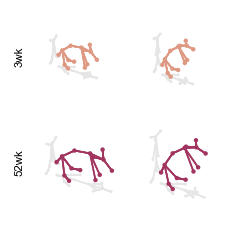

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/a-equivalent-poses-anchor.pdf')

In [14]:

n_display=2
_align_meta = {'scale': np.array(align_meta['scale'])}
anchors = anchor_keypoints(
    params.morph,
    {},
    magnitudes=anchor_magnitudes(dataset_feats, params.morph, q = 0.1),
    config=cfg,
    session_meta=dataset_feats.session_meta,
)
anchors_scaled = anchor_keypoints(
    params.morph,
    _align_meta,
    magnitudes=anchor_magnitudes(dataset_feats, params.morph, q = 0.1),
    config=cfg,
    session_meta=dataset_feats.session_meta,
)



gs = plt.GridSpec(2, n_display, height_ratios=[1, 1], wspace=0)
fig = plt.figure(figsize=(1.5, 1.5), dpi=150)
row0 = np.array([fig.add_subplot(gs[0, i], projection='3d') for i in range(n_display)])
row1 = np.array([fig.add_subplot(gs[1, i], projection='3d') for i in range(n_display)])

ref_body = dataset_feats.session_body_id(f'{ref_age}wk_m0')
tgt_body = dataset_feats.session_body_id(f'{tgt_age}wk_m0')
for i in range(n_display):
    row1[i].sharex(row0[i])
    row1[i].sharey(row0[i])
    row1[i].sharez(row0[i])

for i in range(n_display):
    plotdrop(anchors_scaled[ref_body, i], row0[i], ref_color, 0.3, 0.5, True, shady=False, arms=arms)
    plotdrop(anchors_scaled[tgt_body, i], row1[i], tgt_color, 0.3, 0.5, True, shady=False, arms=arms)

fig.tight_layout()
row0[0].text2D(-0.15, 0.55, f"{ref_age}wk", ha = 'center', va = 'center', rotation=90, size=5.5, transform=row0[0].transAxes)
row1[0].text2D(-0.15, 0.55, f"{tgt_age}wk", ha = 'center', va = 'center', rotation=90, size=5.5, transform=row1[0].transAxes)

plotter.finalize(fig, 'a-equivalent-poses-anchor', tight=False)

### B. Normalizes bone length distributions

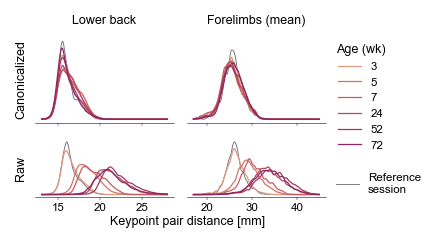

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/b-bls-raw-vs-canon.pdf')

In [15]:
rescale = True


loback_ix = bone_names.index('hips-back') if 'hips-back' in bone_names else bone_names.index('back-hips')
# hiback_ix = bone_names.index('back-shldr') if 'back-shldr' in bone_names else bone_names.index('shldr-back')
lfpaw_ix = bone_names.index('lf_foot-shldr') if 'lf_foot-shldr' in bone_names else bone_names.index('shldr-lf_foot')
rfpaw_ix = bone_names.index('rf_foot-shldr') if 'rf_foot-shldr' in bone_names else bone_names.index('shldr-rf_foot')

# ---- canonicalize, compute bone lengths of canonical and raw
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats, merged_params, None, rescale=rescale, scale_to=scale_to, _align_meta={'scale': np.array(align_meta['scale'])})
bls_canon, bls_raw, _ = canonicalized_raw_bls(canonicalized, raw, dataset.sessions, parts = [''], sep = '')


loback_canon = {k: v[:, loback_ix] for k, v in bls_canon.items()}
loback_raw = {k: v[:, loback_ix] for k, v in bls_raw.items()}
flimb_canon = {k: v[:, [lfpaw_ix, rfpaw_ix]].mean(axis = 1) for k, v in bls_canon.items()}
flimb_raw = {k: v[:, [lfpaw_ix, rfpaw_ix]].mean(axis = 1) for k, v in bls_raw.items()}

# reference animal BLs
ref_bls_canon = _bone_lengths(canonicalized.get_session(scale_to), arms)
ref_bls_raw = _bone_lengths(raw.get_session(scale_to), arms)
ref_loback_canon = ref_bls_canon[:, loback_ix]
ref_loback_raw = ref_bls_raw[:, loback_ix]
ref_flimb_canon = ref_bls_canon[:, [lfpaw_ix, rfpaw_ix]].mean(axis = 1)
ref_flimb_raw = ref_bls_raw[:, [lfpaw_ix, rfpaw_ix]].mean(axis = 1)


# ---- plot bone length distributions
fig, ax = plt.subplots(2, 2, figsize=(2.25, 1.5), sharex='col', sharey='col', height_ratios = [1.5, 1], dpi=150)
for group, color in zip([ref_age] + tgt_ages, [ref_color] + tgt_colors):

    loback_x = np.linspace(13, 28, 200)
    flimb_x = np.linspace(17, 45, 200)

    kw = dict(lw = 0.6, color = color, label = group)
    ax[0, 0].plot(*viz.util.kde(loback_canon[group], 0.2, 500, 5, True, loback_x), **kw)
    ax[0, 1].plot(*viz.util.kde(flimb_canon[group], 0.26, 500, 5, True, flimb_x), **kw)

    ax[1, 0].plot(*viz.util.kde(loback_raw[group], 0.2, 500, 5, True, loback_x), **kw)
    ax[1, 1].plot(*viz.util.kde(flimb_raw[group], 0.26, 500, 5, True, flimb_x), **kw)

    

for a in ax.ravel():
    a.set_yticks([])
    a.spines['left'].set_visible(False)

ax[0, 0].set_ylabel("Canonicalized")
ax[1, 0].set_ylabel("Raw")
# ax[1, 0].set_xlabel(" " * 25 + "Keypoint pair distance [mm]")
fig.text(0.55, 0.02, "Keypoint pair distance [mm]", ha='center', va='center')
ax[0, 0].set_title("Lower back")
ax[0, 1].set_title("Forelimbs (mean)")
plt.tight_layout()

leg = viz.util.legend(ax[0, 1], bbox_to_anchor = (1, 0.3), title_fontsize=6, title="Age (wk)")

# reference animal
kw = dict(lw = 0.4, color = '.4', label = 'Reference\nsession', zorder = -1)
ax[0, 0].plot(*viz.util.kde(ref_loback_canon, 0.2, 500, 5, True, loback_x), **kw)
h, = ax[0, 1].plot(*viz.util.kde(ref_flimb_canon, 0.26,500, 5, True, flimb_x), **kw)

ax[1, 0].plot(*viz.util.kde(ref_loback_raw, 0.2, 500, 5, True, loback_x), **kw)
ax[1, 1].plot(*viz.util.kde(ref_flimb_raw, 0.26,500, 5, True, flimb_x), **kw)

# second legend
viz.util.legend(ax[0, 1], bbox_to_anchor = (1, -0.7), handles=[h], labels=['Reference\nsession'])
ax[0, 1].add_artist(leg)

plotter.finalize(fig, 'b-bls-raw-vs-canon', despine=False, tight=False)



### C. Relative lengths

canonicalizedin to: body-3wk_m0


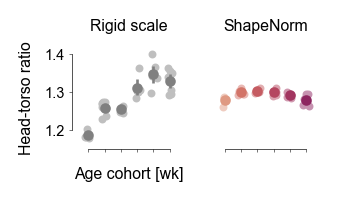

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/d-torso-head-ratio.pdf')

In [1012]:
head_ix = [bone_names.index(short_names.inverse[b]) for b in ['head', 'neck', 'rump']]
back_ix = [bone_names.index(short_names.inverse[b]) for b in ['lo back', 'hi back']]


rescale = True
_align_meta= {'scale': np.array(align_meta['scale'])}
canonicalized, _, _ = canonicalized_and_raw(dataset_feats, merged_params, None, rescale=rescale, scale_to=scale_to, _align_meta=_align_meta, canon_to=scale_to)
raw, _ = unalign_scales(_align_meta, dataset_versions['aligned'], None, None)

bls_canon = {s: np.array(_bone_lengths(canonicalized.get_session(s), arms).mean(axis = 0)) for s in dataset_feats.sessions}
bls_raw = {s: np.array(_bone_lengths(raw.get_session(s), arms).mean(axis = 0)) for s in dataset_feats.sessions}
rto_canon = {s: (bls_canon[s][back_ix].mean(axis = 0)) / bls_canon[s][head_ix].mean(axis = 0) for s in dataset_feats.sessions}
rto_raw = {s: (bls_raw[s][back_ix].mean(axis = 0)) / bls_raw[s][head_ix].mean(axis = 0) for s in dataset_feats.sessions}

# Data for strippplot
ages = [ref_age] + tgt_ages
age_groups = {a: [s for s in dataset_feats.sessions if re.search(r"(\d+)wk", s).group(1) == a] for a in ages}
rto_canon = [np.array([rto_canon[s] for s in age_groups[a]]) for a in ages]
rto_raw = [np.array([rto_raw[s] for s in age_groups[a]]) for a in ages]

kw = dict(
    error = lambda a, **kw: viz.util.ci(a, level=0.95, n=1000),
    jitter = 0.2,
    lighten_points = 0.5,
    lim_buffer = 1,
    offset=False,
    xticks=ages,
)

fig, ax = plt.subplots(1, 2, figsize = (1.7, 0.7), dpi=190)
viz.util.grouped_stripplot(viz.util.expand_groups(rto_raw, ages), x = np.arange(len(ages)), ax = ax[0], colors='.5', **kw)
viz.util.grouped_stripplot(viz.util.expand_groups(rto_canon, ages), x = np.arange(len(ages)), ax = ax[1], colors=age_pal, **kw)
for a in ax:
    a.set_ylim(1.15, 1.42)
    a.set_xticklabels([""] * len(ages))

ax[1].set_yticks([])
    
ax[0].set_ylabel('Head-torso ratio')
ax[0].set_xlabel('Age cohort [wk]')
ax[0].set_title("Rigid scale")
ax[1].set_title("ShapeNorm")
sns.despine(ax = ax[0], trim = True)
sns.despine(ax = ax[1], trim = True, left=True)

plotter.finalize(fig, 'd-torso-head-ratio', tight=False, despine=False)

#### All relative bone lengths

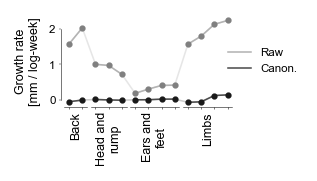

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/d-growth-rates.pdf')

In [17]:
rescale = True
group_order = [ref_age] + tgt_ages


sessions = dataset.sessions
_align_meta= {'scale': np.array(align_meta['scale'])}
canonicalized, _, _ = canonicalized_and_raw(dataset_feats, merged_params, None, rescale=rescale, scale_to=scale_to, _align_meta=_align_meta)
raw, _ = unalign_scales(_align_meta, dataset_versions['aligned'], None, None)
bls_canon, bls_raw, groups = canonicalized_raw_bls(canonicalized, raw, sessions, parts = [''], sep = '')



cov = lambda x, y: (x * y).mean(axis=-1) - x.mean(axis=-1) * y.mean(axis=-1)
coef = lambda a, b: cov(a, b) / cov(a, a)
coefs_raw = np.zeros([len(bone_names)] * 2)
coefs_canon = np.zeros([len(bone_names)] * 2)


for (r, r_ix), (c, c_ix) in iit.product(enumerate(bone_ix_order), enumerate(bone_ix_order)):
    # if r == c:
        # continue
    logage = np.log([int(g) for g in group_order])

    rto_canon = np.array([
        bls_canon[g][:, c_ix].mean() #/ bls_canon[g][:, r_ix].mean()
        for g in group_order
    ])
    coefs_canon[r, c] = coef(logage, rto_canon)

    rto_raw = np.array([
        bls_raw[g][:, c_ix].mean() #/ bls_raw[g][:, r_ix].mean()
        for g in group_order
    ])
    coefs_raw[r, c] = coef(logage, rto_raw)
    
fig, ax = plt.subplots(1, 1, figsize = (1.5, 0.8), dpi=150)
ax.plot(coefs_raw[0, :], '-', color = '.9', lw = 0.75, zorder = -2)
ax.plot(coefs_canon[0, :], '-', color = '.8', lw = 0.75, zorder = -2)
for bone_group in bone_groups:
    g = np.arange(bone_group[0], bone_group[1] + 1)
    ax.plot(g, coefs_raw[0, g], '-', color = '.7', lw = 0.75, label = 'Raw')
    ax.plot(g, coefs_canon[0, g], '-', color = '.3', lw = 0.75, label = 'Canon.')

ax.plot(coefs_raw[0, :], 'o', color = '.5', ms = 2)
ax.plot(coefs_canon[0, :], 'o', color = colors.neutral, ms = 2)
viz.util.legend(ax, viz.util.unique_handles(ax), bbox_to_anchor = (0.9, 0.5))

ax.set_xticks([])
ax.spines['bottom'].set_visible(False)
ax.set_ylabel("Growth rate\n[mm / log-week]")
ax.set_ylim(-0.2, 2.4)
sns.despine(ax = ax, trim = True, bottom=True)

ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax)
for bg, n in zip(bone_groups, bone_group_names):
    ax.add_artist(
        mpl.lines.Line2D(
            [bg[0] - 0.35, bg[1] + 0.35],
            [ymin, ymin],
            color="k",
            lw=0.25,
            clip_on=False,
        )
    )
    ax.add_artist(
        mpl.text.Text(
            (bg[0] + bg[1]) / 2,
            -0.05,
            n,
            ha="center",
            va="top",
            clip_on=False,
            fontsize=6,
            rotation=90,
            transform=mpl.transforms.blended_transform_factory(
                ax.transData, ax.transAxes
            ),
        )
    )

# convert inches to data coordinates
# (1 mm = 0.0393701 inches)
mm_to_data_y = ax.transData.inverted().transform([0, fig.dpi_scale_trans.transform((0, 0.039))[1]])[1] - ax.transData.inverted().transform([0, fig.dpi_scale_trans.transform((0, 0))[1]])[1]

for x in range(0, len(bone_names)):
    ax.add_artist(
        mpl.lines.Line2D(
            [x, x],
            [ymin, ymin-mm_to_data_y*0.3],
            color="k",
            lw=0.25,
            clip_on=False,
            solid_capstyle="butt",
        )
    )


plotter.finalize(fig, 'd-growth-rates', tight=False, despine=False)

0.007597402597402589


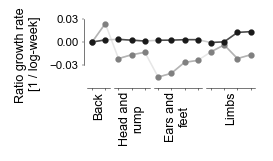

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/d-growth-rates.pdf')

In [18]:
rescale = True
group_order = [ref_age] + tgt_ages


sessions = dataset.sessions
_align_meta= {'scale': np.array(align_meta['scale'])}
canonicalized, _, _ = canonicalized_and_raw(dataset_feats, merged_params, None, rescale=rescale, scale_to=scale_to, _align_meta=_align_meta)
raw, _ = unalign_scales(_align_meta, dataset_versions['aligned'], None, None)
bls_canon, bls_raw, groups = canonicalized_raw_bls(canonicalized, raw, sessions, parts = [''], sep = '')



cov = lambda x, y: (x * y).mean(axis=-1) - x.mean(axis=-1) * y.mean(axis=-1)
coef = lambda a, b: cov(a, b) / cov(a, a)
coefs_raw = np.zeros([len(bone_names)] * 2)
coefs_canon = np.zeros([len(bone_names)] * 2)


for (r, r_ix), (c, c_ix) in iit.product(enumerate(bone_ix_order), enumerate(bone_ix_order)):
    # if r == c:
        # continue
    logage = np.log([int(g) for g in group_order])

    rto_canon = np.array([
        bls_canon[g][:, c_ix].mean() / bls_canon[g][:, r_ix].mean()
        for g in group_order
    ])
    coefs_canon[r, c] = coef(logage, rto_canon)

    rto_raw = np.array([
        bls_raw[g][:, c_ix].mean() / bls_raw[g][:, r_ix].mean()
        for g in group_order
    ])
    coefs_raw[r, c] = coef(logage, rto_raw)
    
fig, ax = plt.subplots(1, 1, figsize = (1.5, 0.6), dpi=150)
ax.plot(coefs_raw[0, :], '-', color = '.9', lw = 0.75, zorder = -2)
ax.plot(coefs_canon[0, :], '-', color = '.8', lw = 0.75, zorder = -2)
for bone_group in bone_groups:
    g = np.arange(bone_group[0], bone_group[1] + 1)
    ax.plot(g, coefs_raw[0, g], '-', color = '.7', lw = 0.75, label = 'Raw')
    ax.plot(g, coefs_canon[0, g], '-', color = '.3', lw = 0.75, label = 'Canon.')

ax.plot(coefs_raw[0, :], 'o', color = '.5', ms = 2)
ax.plot(coefs_canon[0, :], 'o', color = colors.neutral, ms = 2)

ax.set_xticks([])
ax.spines['bottom'].set_visible(False)
ax.set_ylabel("Ratio growth rate \n[1 / log-week]")
ax.set_ylim(-0.06, 0.03)
ax.set_yticks([-0.03, 0, 0.03])
sns.despine(ax = ax, trim = True, bottom=True)

ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax)
for bg, n in zip(bone_groups, bone_group_names):
    ax.add_artist(
        mpl.lines.Line2D(
            [bg[0] - 0.35, bg[1] + 0.35],
            [ymin, ymin],
            color="k",
            lw=0.25,
            clip_on=False,
        )
    )
    ax.add_artist(
        mpl.text.Text(
            (bg[0] + bg[1]) / 2,
            -0.05,
            n,
            ha="center",
            va="top",
            clip_on=False,
            fontsize=6,
            rotation=90,
            transform=mpl.transforms.blended_transform_factory(
                ax.transData, ax.transAxes
            ),
        )
    )

# convert inches to data coordinates
# (1 mm = 0.0393701 inches)
mm_to_data_y = ax.transData.inverted().transform([0, fig.dpi_scale_trans.transform((0, 0.039))[1]])[1] - ax.transData.inverted().transform([0, fig.dpi_scale_trans.transform((0, 0))[1]])[1]
print(mm_to_data_y)
for x in range(0, len(bone_names)):
    ax.add_artist(
        mpl.lines.Line2D(
            [x, x],
            [ymin, ymin-mm_to_data_y*0.3],
            color="k",
            lw=0.25,
            clip_on=False,
            solid_capstyle="butt",
        )
    )


plotter.finalize(fig, 'd-growth-rates', tight=False, despine=False)

##### Experiments around head-torso ratio

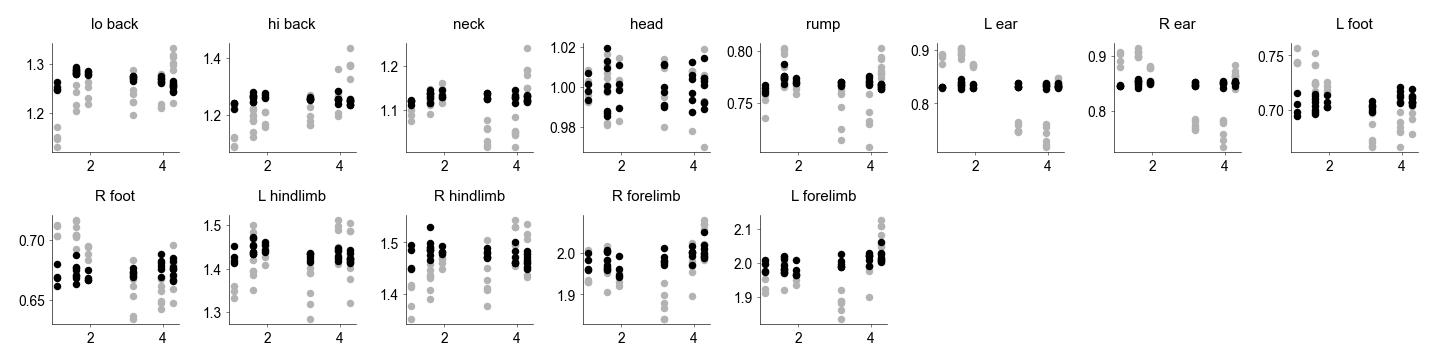

In [81]:
rescale = True
group_order = [ref_age] + tgt_ages

head_ix = bone_names.index(short_names.inverse['head'])

sessions = dataset.sessions
_align_meta= {'scale': np.array(align_meta['scale'])}
canonicalized, _, _ = canonicalized_and_raw(dataset_feats, merged_params, None, rescale=rescale, scale_to=scale_to, _align_meta=_align_meta)
raw, _ = unalign_scales(_align_meta, dataset_versions['aligned'], None, None)

bls_canon = {s: np.array(_bone_lengths(canonicalized.get_session(s), arms).mean(axis = 0)) for s in dataset_feats.sessions}
bls_raw = {s: np.array(_bone_lengths(raw.get_session(s), arms).mean(axis = 0)) for s in dataset_feats.sessions}
age_groups = {a: [s for s in dataset_feats.sessions if re.search(r"(\d+)wk", s).group(1) == a] for a in [ref_age] + tgt_ages}
age_order = [ref_age] + tgt_ages


cov = lambda x, y: (x * y).mean(axis=-1) - x.mean(axis=-1) * y.mean(axis=-1)
coef = lambda a, b: cov(a, b) / cov(a, a)
coefs_raw = np.zeros([len(bone_names)] * 2)
coefs_canon = np.zeros([len(bone_names)] * 2)
 

fig, axes, ax_grid = viz.util.flat_grid(len(bone_ix_order), 8, (1, 1), sharex=False, sharey=False, dpi=180)

for (r, r_ix), (c, (c_ix, ax)) in iit.product(enumerate(bone_ix_order), enumerate(zip(bone_ix_order, axes))):
    # if r == c:
        # continue
    logage = np.log([int(a) for a in age_order])

    rto_canon = ([
        np.array([bls_canon[s][c_ix] for s in age_groups[a]]) / np.array([bls_canon[s][head_ix] for s in age_groups[a]]).mean()
        for a in age_order
    ])
    # coefs_canon[r, c] = [coef(logage, rto_canon[i]) for i in range(rto_canon.shape[1])]

    rto_raw = ([
        np.array([bls_raw[s][c_ix] for s in age_groups[a]]) / np.array([bls_raw[s][head_ix] for s in age_groups[a]]).mean()
        for a in age_order
    ])
    # coefs_raw[r, c] = [coef(logage, rto_raw[i]) for i in range(rto_raw.shape[1])]
    if r_ix == 0:
        for i, a in enumerate(age_order):
            ax.plot([logage[i]] * len(rto_raw[i]), rto_raw[i], 'o', ms = 3, mew = 0, color = '.7')
            ax.plot([logage[i]] * len(rto_raw[i]), rto_canon[i], 'o', ms = 3,  mew = 0, color = 'k')
        ax.set_title(short_names[bone_names[c_ix]])
    


# viz.util.legend(ax, loc = 'upper left', fontsize = 6, frameon = False)
# ax.set_yticks([0, 3e-2, 6e-2])
plotter.finalize(fig, None)

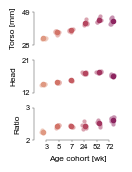

In [79]:
import numpy.linalg as la

# names, parents, bones, root = mouse_data_armature_meta()
# keypt_ix = lambda k: names.index(k)
# obs_keypts = dataset_keypoints

# keypt_ix = lambda k: arms.keypoint_names.inverse[k]
# obs_keypts = {s: dataset_versions['aligned'].get_session(s) for s in dataset_feats.sessions}

# keypt_ix = lambda k: arms.keypoint_names.inverse[k]
# inflated = features.inflate(dataset_versions['reduced'], cfg['features'])
# obs_keypts = {s: inflated.get_session(s) for s in dataset_feats.sessions}

# keypt_ix = lambda k: arms.keypoint_names.inverse[k]
_align_meta= {'scale': np.array(align_meta['scale'])}
raw, _ = unalign_scales(_align_meta, dataset_versions['aligned'], None, None)
obs_keypts = {s: raw.get_session(s) for s in dataset_feats.sessions}

# keypt_ix = lambda k: arms.keypoint_names.inverse[k]
# _align_meta= {'scale': np.array(align_meta['scale'])}
# canonicalized, raw, _ = canonicalized_and_raw(dataset_feats, merged_params, None, rescale=False)
# obs_keypts = {s: raw.get_session(s) for s in dataset_feats.sessions}

# torso_length = lambda kpts: (
#     la.norm(kpts[:, keypt_ix('shldr'), :] - kpts[:, keypt_ix('back'), :], axis = -1) +
#     la.norm(kpts[:, keypt_ix('back'), :] - kpts[:, keypt_ix('hips'), :], axis = -1)
# )
# head_length = lambda kpts: la.norm(kpts[:, keypt_ix('nose'), :] - kpts[:,
# keypt_ix('head'), :], axis = -1)
bone_ix = lambda b: bone_names.index(short_names.inverse[b])
torso_length = lambda kpts: (
    _bone_lengths(kpts, arms)[:, bone_ix('lo back')] +
    _bone_lengths(kpts, arms)[:, bone_ix('hi back')]
)
head_length = lambda kpts: _bone_lengths(kpts, arms)[:, bone_ix('head')]
tl = [np.array([torso_length(obs_keypts[s]).mean() for s in age_groups[a]]) for a in ages]
hl = [np.array([head_length(obs_keypts[s]).mean() for s in age_groups[a]]) for a in ages]
rto = [np.array([(torso_length(obs_keypts[s]) / head_length(obs_keypts[s])).mean() for s in age_groups[a]]) for a in ages]


tl_samp = [viz.util.ci(l, n = 1000, return_samples=True) for l in [tl[0], tl[-1]]]
hl_samp = [viz.util.ci(l, n = 1000, return_samples=True) for l in [hl[0], hl[-1]]]

kw = dict(
    error = lambda a, **kw: viz.util.ci(a, level=0.95, n=1000),
    jitter = 0.2,
    lighten_points = 0.5,
    lim_buffer = 1,
    colors = age_pal,
)
fig = plt.figure(figsize = (1.3, 1.7))
ax = fig.add_subplot(311)
viz.util.grouped_stripplot(viz.util.expand_groups(tl, ages), ax = ax, xticks = "", **kw)
ax.set_ylabel('Torso [mm]')
viz.util.nticks(ax, 2, x = False)
viz.util.round_limits(ax, x = False, precision=0.4)
ax.set_xticks([])
sns.despine(ax = ax, bottom = True)

ax = fig.add_subplot(312)
ax.set_ylabel('Head')
viz.util.grouped_stripplot(viz.util.expand_groups(hl, ages), ax = ax, xticks = "", **kw)
ax.set_ylim(13, 20)
viz.util.nticks(ax, 2, x = False)
viz.util.round_limits(ax, x = False, precision=0.4)
ax.set_xticks([])
sns.despine(ax = ax, bottom = True)


ax = fig.add_subplot(313)
viz.util.grouped_stripplot(viz.util.expand_groups(rto, ages), ax = ax, xticks = ages, **kw)
ax.set_ylabel('Ratio')
ax.set_xlabel('Age cohort [wk]')
ax.set_ylim(2, 3)
viz.util.nticks(ax, 2, x = False)
sns.despine(ax = ax, trim = True)

plotter.finalize(fig, None, despine=False)

### E. Impact of joint angle on morph

#### Supporting function: remove angular component

In [19]:
def remove_angular_morph(frame_A, frame_B, arms):
    """
    Given two frames of keypoints, construct a copy of B with the joint angles
    of A.
    """
    bones, root = arms.bones, arms.keypoint_names.inverse[arms.root]
    single_frame = False
    if frame_A.ndim == 2:
        frame_A = frame_A[None]
        frame_B = frame_B[None]
        single_frame = True
    root, bones, ls_mat = blscale_ls.roots_and_bones(
        {"A": frame_A, "B": frame_B}, bones, root
    )
    bls = {s: np.linalg.norm(b, axis = -1) for s, b in bones.items()}
    bl_ratio = bls["B"] / bls["A"]
    bones_scaled = bones["A"] * bl_ratio[..., None]
    frame_C = blscale_ls.inverse_transform(root["A"], bones_scaled, ls_mat)
    return frame_C[0] if single_frame else frame_C

#### Example poses

/var/folders/yl/fzvpkkfs7md45qk6gcq3q27r0000gn/T/ipykernel_6369/309130061.py:42: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  fig.tight_layout()
/var/folders/yl/fzvpkkfs7md45qk6gcq3q27r0000gn/T/ipykernel_6369/309130061.py:48: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


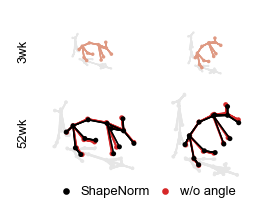

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/e-equivalent-poses-anchor.pdf')

In [26]:

_align_meta = {'scale': np.array(align_meta['scale'])}
anchors = anchor_keypoints(
    params.morph,
    {},
    magnitudes=anchor_magnitudes(dataset_feats, params.morph, q = 0.1),
    config=cfg,
    session_meta=dataset_feats.session_meta,
)
anchors_scaled = anchor_keypoints(
    params.morph,
    _align_meta,
    magnitudes=anchor_magnitudes(dataset_feats, params.morph, q = 0.1),
    config=cfg,
    session_meta=dataset_feats.session_meta,
)


ref_id = dataset_feats.session_id(f'{ref_age}wk_m0')
tgt_id = dataset_feats.session_id(f'{tgt_age}wk_m0')
anchors_bl_only = remove_angular_morph(anchors_scaled[ref_id], anchors_scaled[tgt_id], arms)

gs_r0 = plt.GridSpec(2, 6, height_ratios=[1, 1.5], width_ratios = [0.13, 0.5, 0.1, 0.13, 0.5, 0.1], wspace=0, hspace=0)
gs_r1 = plt.GridSpec(2, 4, height_ratios=[0.5, 1.5], wspace=0, hspace=0)
fig = plt.figure(figsize=(1.7, 1.5), dpi=170)
row0_shad = np.array([fig.add_subplot(gs_r0[0, 3*i+1], projection='3d') for i in range(2)])
row1_shad = np.array([fig.add_subplot(gs_r1[1, 2*i:2*i+2], projection='3d') for i in range(2)])
row0_back = np.array([fig.add_subplot(gs_r0[0, 3*i+1], projection='3d') for i in range(2)])
row1_back = np.array([fig.add_subplot(gs_r1[1, 2*i:2*i+2], projection='3d') for i in range(2)])
row1_frnt = np.array([fig.add_subplot(gs_r1[1, 2*i:2*i+2], projection='3d') for i in range(2)])

for i in range(2):
    for tgt in [row0_shad, row1_shad, row1_back, row1_frnt]:
        tgt[i].sharex(row0_back[i])
        tgt[i].sharey(row0_back[i])
        tgt[i].sharez(row0_back[i])

for i in range(2):
    plotdrop(anchors_scaled[ref_body, i], row0_back[i], ref_color, 0.15, 0.3, True, shady=False, dropax=row0_shad[i], arms=arms)
    plotdrop(anchors_scaled[tgt_body, i], row1_frnt[i], mpl_col.to_rgba('k'), 0.3, 0.3, True, shady=False, dropax=row1_shad[i], arms=arms)
    plotdrop(anchors_bl_only[i], row1_back[i], mpl_col.to_rgba('C3'), 0.3, 0.5, True, shady=False, dropax=row1_shad[i], arms=arms)

fig.tight_layout()
t = mpl.transforms.blended_transform_factory(fig.transFigure, row0_back[0].transAxes)
row0_back[0].text2D(0.07, 0.55, f"{ref_age}wk", ha = 'center', va = 'center', rotation=90, size=5.5, transform=t)
t = mpl.transforms.blended_transform_factory(fig.transFigure, row1_back[0].transAxes)
row1_back[0].text2D(0.07, 0.55, f"{tgt_age}wk", ha = 'center', va = 'center', rotation=90, size=5.5, transform=t)

plt.tight_layout()

legax = fig.add_subplot(335)
legax.set_axis_off()
legax.scatter([np.nan], [np.nan], color=mpl_col.to_rgba('k'), s=4, label = "ShapeNorm")
legax.scatter([np.nan], [np.nan], color=mpl_col.to_rgba('C3'), s=4, label = "w/o angle")
viz.util.legend(legax, loc='center', bbox_to_anchor = (0.4, -0.85), ncol = 2, columnspacing=0.2, handletextpad=0.1)

plotter.finalize(fig, 'e-equivalent-poses-anchor', tight=False)

/var/folders/yl/fzvpkkfs7md45qk6gcq3q27r0000gn/T/ipykernel_6369/1660704133.py:50: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  fig.tight_layout()
/var/folders/yl/fzvpkkfs7md45qk6gcq3q27r0000gn/T/ipykernel_6369/1660704133.py:56: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


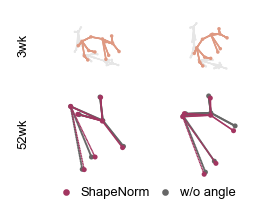

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/e-equivalent-poses-anchor-head.pdf')

In [27]:

_align_meta = {'scale': np.array(align_meta['scale'])}
anchors = anchor_keypoints(
    params.morph,
    {},
    magnitudes=anchor_magnitudes(dataset_feats, params.morph, q = 0.1),
    config=cfg,
    session_meta=dataset_feats.session_meta,
)
anchors_scaled = anchor_keypoints(
    params.morph,
    _align_meta,
    magnitudes=anchor_magnitudes(dataset_feats, params.morph, q = 0.1),
    config=cfg,
    session_meta=dataset_feats.session_meta,
)


ref_id = dataset_feats.session_id(f'{ref_age}wk_m0')
tgt_id = dataset_feats.session_id(f'{tgt_age}wk_m0')
anchors_bl_only = remove_angular_morph(anchors_scaled[ref_id], anchors_scaled[tgt_id], arms)

gs_r0 = plt.GridSpec(2, 6, height_ratios=[0.7, 1.5], width_ratios = [0.13, 0.5, 0.1, 0.13, 0.5, 0.1], wspace=0, hspace=0)
gs_r1 = plt.GridSpec(2, 4, height_ratios=[0.5, 1.5], wspace=0, hspace=0)
fig = plt.figure(figsize=(1.7, 1.5), dpi=170)
row0_shad = np.array([fig.add_subplot(gs_r0[0, 3*i+1], projection='3d') for i in range(2)])
row1_shad = np.array([fig.add_subplot(gs_r1[1, 2*i:2*i+2], projection='3d') for i in range(2)])
row0_back = np.array([fig.add_subplot(gs_r0[0, 3*i+1], projection='3d') for i in range(2)])
row1_back = np.array([fig.add_subplot(gs_r1[1, 2*i:2*i+2], projection='3d') for i in range(2)])
row1_frnt = np.array([fig.add_subplot(gs_r1[1, 2*i:2*i+2], projection='3d') for i in range(2)])

mask_kps = lambda frame, whitelist: (
    np.array([np.nan if arms.keypoint_names[i] not in whitelist else 1 for i in range(len(arms.keypoint_names))])[:, None]
    * frame
)
kp_whitelist = ['shldr', 'head', 'l_ear', 'r_ear', 'nose', 'lf_foot', 'rf_foot']

# for i in range(2):
#     for tgt in [row0_shad, row1_shad, row1_back, row1_frnt]:
#         tgt[i].sharex(row0_back[i])
#         tgt[i].sharey(row0_back[i])
#         tgt[i].sharez(row0_back[i])

for i in range(2):
    plotdrop(anchors_scaled[ref_id, i], row0_back[i], ref_color, 0.15, 0.3, True, shady=False, dropax=row0_shad[i], arms=arms)
    tgt_lra = mask_kps(anchors_scaled[tgt_id, i], kp_whitelist)
    plotdrop(tgt_lra, row1_frnt[i], tgt_color, 0.3, 0.3, True, shady=False, dropax=row1_shad[i], arms=arms)
    tgt_blscale = mask_kps(anchors_bl_only[i], kp_whitelist)
    plotdrop(tgt_blscale, row1_back[i], mpl_col.to_rgba('.4'), 0.3, 0.5, True, shady=False, dropax=row1_shad[i], arms=arms)

fig.tight_layout()
t = mpl.transforms.blended_transform_factory(fig.transFigure, row0_back[0].transAxes)
row0_back[0].text2D(0.07, 0.55, f"{ref_age}wk", ha = 'center', va = 'center', rotation=90, size=5.5, transform=t)
t = mpl.transforms.blended_transform_factory(fig.transFigure, row1_back[0].transAxes)
row1_back[0].text2D(0.07, 0.55, f"{tgt_age}wk", ha = 'center', va = 'center', rotation=90, size=5.5, transform=t)

plt.tight_layout()

legax = fig.add_subplot(335)
legax.set_axis_off()
legax.scatter([np.nan], [np.nan], color=tgt_color, s=4, label = "ShapeNorm")
legax.scatter([np.nan], [np.nan], color='.4', s=4, label = "w/o angle")
viz.util.legend(legax, loc='center', bbox_to_anchor = (0.4, -0.85), ncol = 2, columnspacing=0.2, handletextpad=0.1)

plotter.finalize(fig, 'e-equivalent-poses-anchor-head', tight=False)

#### Keypoint distances from removing joint angle

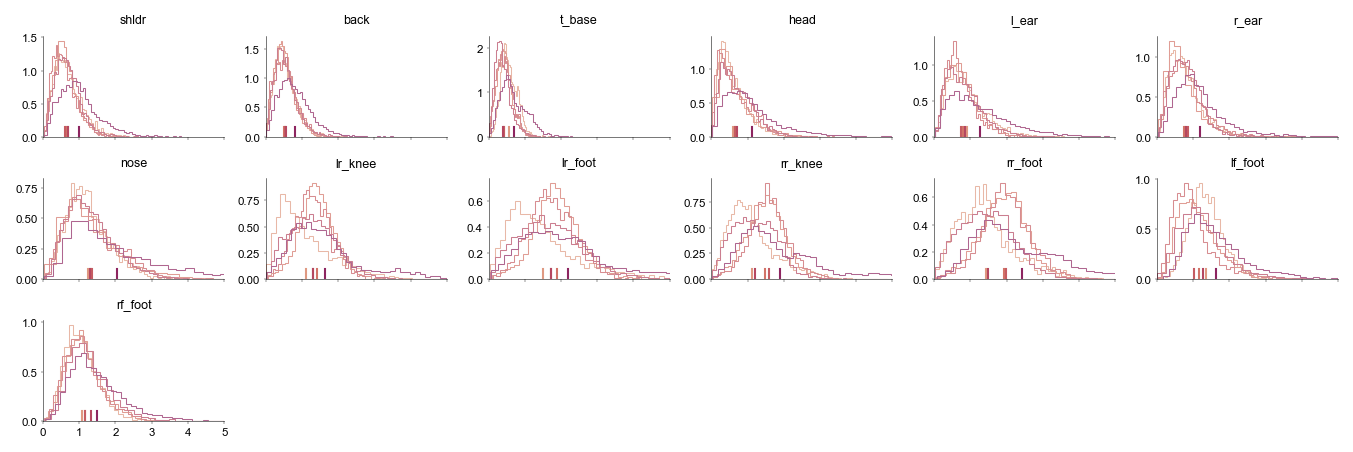

In [34]:


# ---- canonicalize, compute bone lengths of canonical and raw
rescale = True
_align_meta= {'scale': np.array(align_meta['scale'])}
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats, merged_params, None, rescale=rescale, scale_to=scale_to, _align_meta=_align_meta)
# raw, _ = unalign_scales(_align_meta, dataset_versions['aligned'], None, None)
age_groups = {a: [s for s in dataset_feats.sessions if re.search(r"(\d+)wk", s).group(1) == a] for a in [ref_age] + tgt_ages}

frames_C = {s: remove_angular_morph(canonicalized.get_session(s), raw.get_session(s), arms) for s in dataset_feats.sessions}
dists = {s: model_util.reconst_errs(frames_C[s], raw.get_session(s), average=False) for s in dataset_feats.sessions}
morph_ref = dataset_feats.body_name(merged_params.ref_body)
morph_ref_age = re.search(r"(\d+)wk", morph_ref).group(1)

# ---- plot in verbose form
nohips = [ix for ix, n in arms.keypoint_names.items() if 'hips' not in n]
fig, axes, ax_grid = viz.util.flat_grid(arms.n_kpts - 1, min(6, arms.n_kpts - 1), ax_size = (1.5, 1), dpi=150, sharex=True)
for i, (kp_ix, ax) in enumerate(zip(nohips, axes)):
    ax.set_title(arms.keypoint_names[kp_ix])
    for a, age_sessions in age_groups.items():
        if a == morph_ref_age: continue
        x = np.concatenate([dists[s][:, kp_ix] for s in age_sessions])
        ax.hist(
            x,
            bins=50, color=viz.util.lighten(age_pal[a], 0.3), label=a, lw = 0.5, density=True, histtype='step'
        )
        ax.axvline(x.mean(), ymax=0.1, color=age_pal[a], lw=1, ls='-')
        ax.set_xlim(0, 5)
    # ax.set_yscale('log')

plotter.finalize(fig, None)

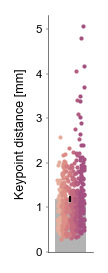

In [219]:
rescale = True
_align_meta= {'scale': np.array(align_meta['scale'])}
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats, merged_params, None, rescale=rescale, scale_to=scale_to, _align_meta=_align_meta)
# raw, _ = unalign_scales(_align_meta, dataset_versions['aligned'], None, None)
ages = [ref_age] + tgt_ages
age_groups = {a: [s for s in dataset_feats.sessions if re.search(r"(\d+)wk", s).group(1) == a] for a in [ref_age] + tgt_ages}

frames_C = {s: remove_angular_morph(canonicalized.get_session(s), raw.get_session(s), arms) for s in dataset_feats.sessions}
dists = {s: model_util.reconst_errs(frames_C[s], raw.get_session(s), average=False) for s in dataset_feats.sessions}
morph_ref = dataset_feats.body_name(merged_params.ref_body)
morph_ref_age = re.search(r"(\d+)wk", morph_ref).group(1)

# ---- plot in verbose form
nohips = [ix for ix, n in arms.keypoint_names.items() if 'hips' not in n]
dists_by_age = {a: np.array([dists[s][:, nohips].mean(axis = 0) for s in age_groups[a] if dataset_feats.session_body_id(s) != merged_params.ref_body]) for a in ages}

fig, ax = plt.subplots(figsize = (0.7, 1.8), dpi=150)



viz.util.grouped_stripplot(
    {a: [arr.ravel()] for a, arr in dists_by_age.items()},
    x = [0],
    colors = age_pal,
    points_kw={'ms': 1},
    lighten_points=0.2,
    errorbar=False,
)
viz.util.grouped_stripplot(
    [np.concatenate([arr.ravel() for a, arr in dists_by_age.items()])],
    x = [0],
    colors = 'k',
    points=False,
    errorbar_kw=dict(ms=0),
    error = lambda a, **kw: viz.util.ci(a, level=0.95, n=1000),
)
ax.bar([0], color = '.7', width=0.7, **viz.util.stem_bar(np.concatenate([arr.ravel() for arr in dists_by_age.values()]).mean(), 0),)

ax.set_ylabel("Keypoint distance [mm]")
ax.set_xticks([1])
ax.set_xticklabels([""])
ax.set_xlim(-0.5, 0.5)


plotter.finalize(fig, None, despine=False)


#### Normalizes joint angles?

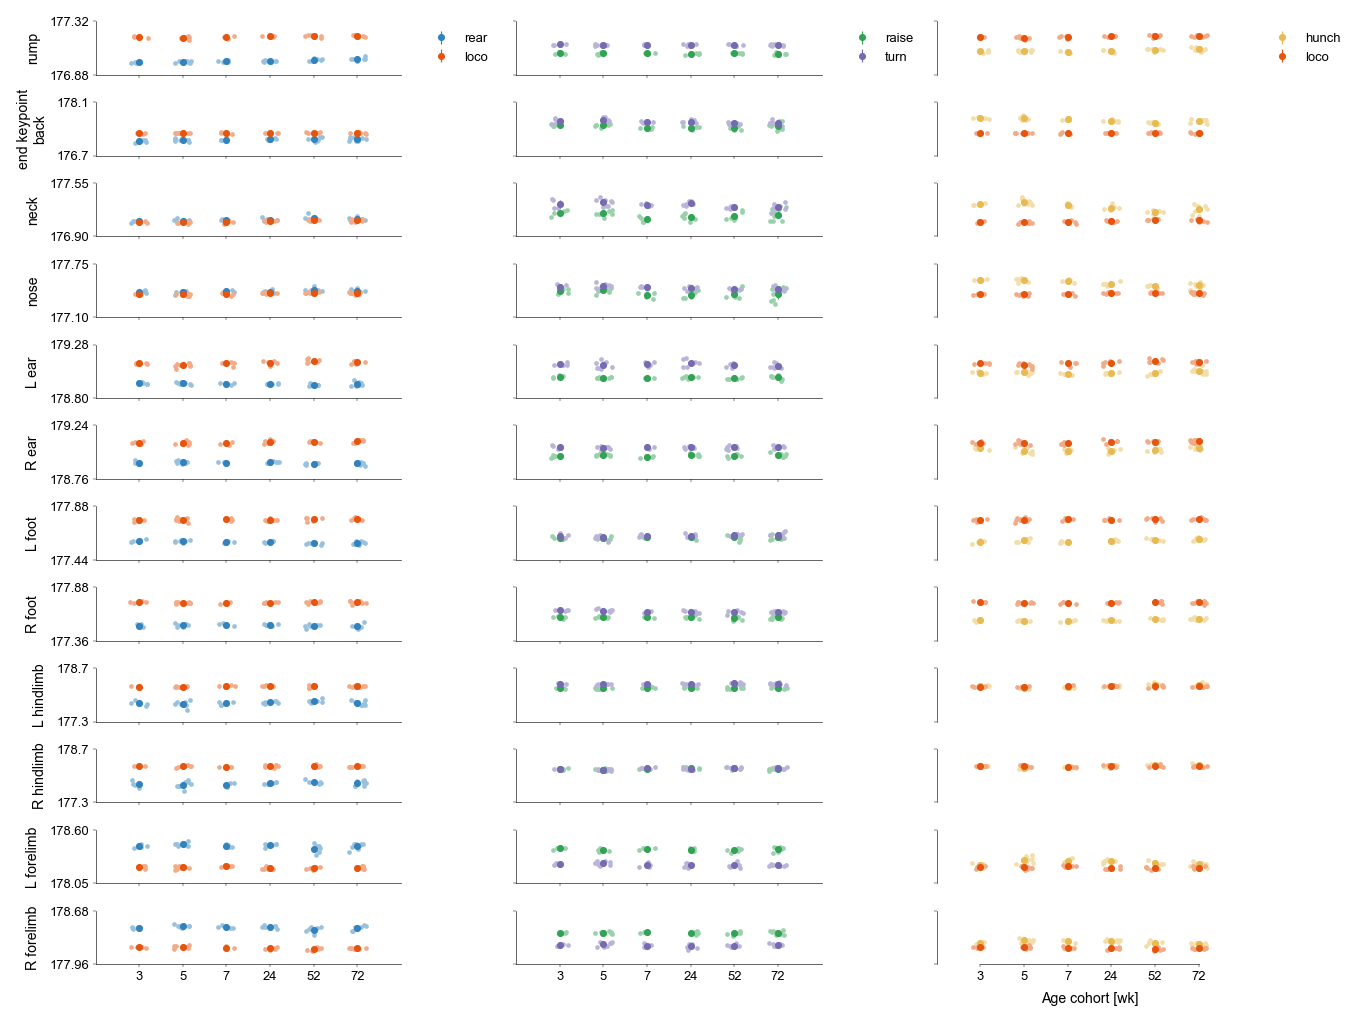

In [66]:
rescale = True
_align_meta= {'scale': np.array(align_meta['scale'])}
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats_full, merged_params, None, rescale=rescale, scale_to=scale_to, _align_meta=_align_meta)
ja_canon = {s: _joint_angles(canonicalized.get_session(s), joint_kp_ixs) for s in dataset_feats.sessions}
ages = [ref_age] + tgt_ages
age_groups = {a: [s for s in dataset_feats.sessions if re.search(r"(\d+)wk", s).group(1) == a] for a in ages}
age_bhv_ja_canon = {k: [np.array([ja_canon[s][bhv_masks[k][s]].mean(axis = 0) for s in age_groups[a]]) for a in ages] for k in bhv_order}


kw = dict(
    error = lambda a, **kw: viz.util.ci(a, level=0.95, n=1000),
    jitter = 0.2,
    lighten_points = 0.5,
    lim_buffer = 1,
    points_kw = {'ms': 1},
    errorbar_kw = {'elinewidth': 0.5, 'ms': 2},
)

fig, ax = plt.subplots(len(joint_names), 3, figsize = ((8), 0.5 * len(joint_names)), dpi=170, sharey='row')
for i, n in enumerate(joint_names):
    is_bottom = i == len(joint_names) - 1
    for col, bhvs in enumerate([['rear', 'loco'], ['raise', 'turn'], ['hunch', 'loco']]):
        viz.util.grouped_stripplot(
            {k: [arr[:, i] for arr in age_bhv_ja_canon[k]] for k in bhvs},
            ax = ax[i, col],
            xticks = ages if is_bottom else "",
            **{**kw, **{'colors': bhv_pal}},
            offset=False,
            labels = True if i == 0 else None
        )

    viz.util.nticks(ax[i, col], 2, x = False)
    viz.util.round_limits(ax[i, col], x = False, precision=1, pad = 0.3)
    if is_bottom:
        ax[i, col].set_xlabel('Age cohort [wk]')


    if is_bottom:
        sns.despine(ax = ax[i, col], trim = True)
    else:
        ax[i, col].set_xticks([])
        sns.despine(ax = ax[i, col], bottom = True)

for i in range(0, len(joint_names)):
    ax[i, 0].set_ylabel(joint_names[i].split('-')[0])
ax[1, 0].set_ylabel("end keypoint\n" + joint_names[1].split('-')[0])

plotter.finalize(fig, None, despine=False)

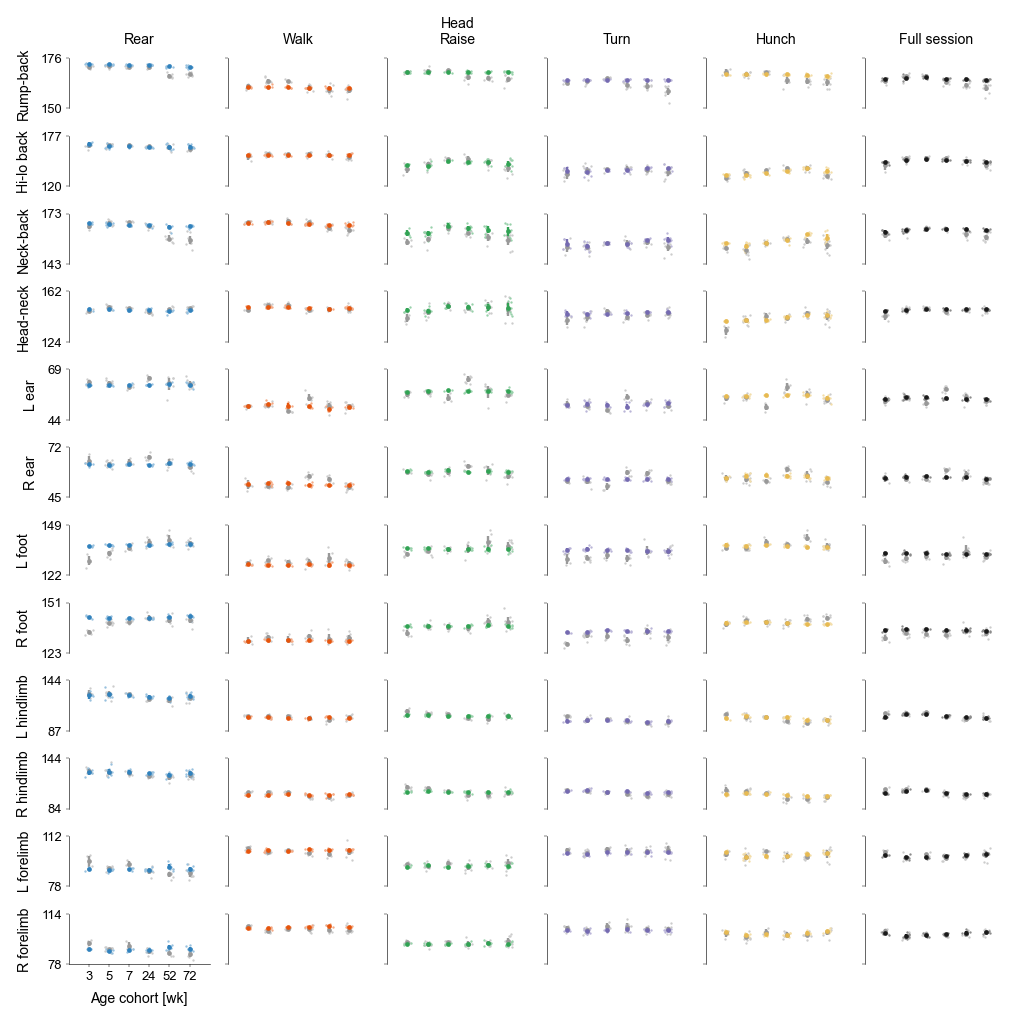

In [322]:
rescale = True
_align_meta= {'scale': np.array(align_meta['scale'])}
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats_full, merged_params, None, rescale=rescale, scale_to=scale_to, _align_meta=_align_meta)
raw, _ = unalign_scales(_align_meta, dataset_versions_full['aligned'], None, None)
ja_canon = {s: _joint_angles(canonicalized.get_session(s), joint_kp_ixs) for s in dataset_feats.sessions}
ja_raw = {s: _joint_angles(raw.get_session(s), joint_kp_ixs) for s in dataset_feats.sessions}
ages = [ref_age] + tgt_ages
age_groups = {a: [s for s in dataset_feats.sessions if re.search(r"(\d+)wk", s).group(1) == a] for a in ages}
age_bhv_ja_canon = {k: [np.array([ja_canon[s][bhv_masks[k][s]].mean(axis = 0) for s in age_groups[a]]) for a in ages] for k in bhv_order}
age_ja_canon = [np.array([ja_canon[s].mean(axis = 0) for s in age_groups[a]]) for a in ages]
age_bhv_ja_raw = {k: [np.array([ja_raw[s][bhv_masks[k][s]].mean(axis = 0) for s in age_groups[a]]) for a in ages] for k in bhv_order}
age_ja_raw = [np.array([ja_raw[s].mean(axis = 0) for s in age_groups[a]]) for a in ages]


kw = dict(
    error = lambda a, **kw: viz.util.ci(a, level=0.95, n=1000),
    jitter = 0.2,
    lighten_points = 0.5,
    lim_buffer = 1,
    points_kw = {'ms': 1, 'mew': 0},
    errorbar_kw = {'elinewidth': 1, 'ms': 2, 'mew': 0},
)

fig, ax = plt.subplots(len(joint_names), len(bhv_order) + 1, figsize = ((6), 0.5 * len(joint_names)), dpi=170, sharey='row')
for i, n in enumerate(joint_names):
    is_bottom = i == len(joint_names) - 1
    for col, k in enumerate(bhv_order + [None]):
        if k is not None:
            d = {x: [arr[:, i] for arr in jas[k]] for x, jas in {'canon': age_bhv_ja_canon, 'raw': age_bhv_ja_raw}.items()}
            c = {"canon": bhv_pal[k], "raw": '.6'}
        else:
            d = {x: [arr[:, i] for arr in jas] for x, jas in {'canon': age_ja_canon, 'raw': age_ja_raw}.items()}
            c = {"canon": colors.neutral, "raw": '.6'}

        viz.util.grouped_stripplot(
            d,
            ax = ax[i, col],
            xticks = ages if is_bottom else "",
            **{**kw, **{'colors': c}},
            group_order = ['raw', 'canon'],
            offset=False,
            labels = None,
        )
        # for x in ['canon', 'raw']:
        #     ax[i, col].plot([arr.mean() for arr in d[x]], color=c[x], lw=0.5, ls='-')

        if is_bottom and col == 0:
            ax[i, col].set_xlabel('Age cohort [wk]')

        if not is_bottom:
            ax[i, col].set_xticks([])
            sns.despine(ax = ax[i, col], bottom = True)
        
        if i == 0:
            ax[i, col].set_title(bhv_names[k] if k is not None else 'Full session')

for a in ax[:, 0]:
    viz.util.nticks(a, 2, x = False)
    viz.util.round_limits(a, x = False, precision=1.2)

for i in range(0, len(joint_names)):
    ax[i, 0].set_ylabel(joint_names[i])

fig.tight_layout()


plotter.finalize(fig, None, despine=False, tight=False)

#### Normalized JA: examples

/Users/kaifox/projects/mph/generative_api/shape_norm/viz/util.py:219: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  return ax.legend(**kw)


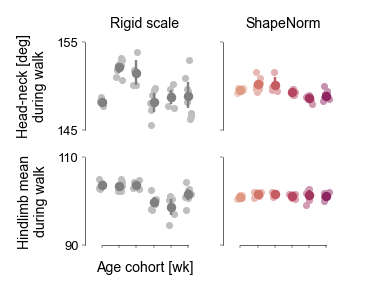

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/e-example-ja-bhv.pdf')

In [32]:
rescale = True
_align_meta= {'scale': np.array(align_meta['scale'])}
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats_full, merged_params, None, rescale=rescale, scale_to=scale_to, _align_meta=_align_meta)
raw, _ = unalign_scales(_align_meta, dataset_versions_full['aligned'], None, None)
ja_canon = {s: _joint_angles(canonicalized.get_session(s), joint_kp_ixs) for s in dataset_feats.sessions}
ja_raw = {s: _joint_angles(raw.get_session(s), joint_kp_ixs) for s in dataset_feats.sessions}
ages = [ref_age] + tgt_ages
age_groups = {a: [s for s in dataset_feats.sessions if re.search(r"(\d+)wk", s).group(1) == a] for a in ages}
age_bhv_ja_canon = {k: [np.array([ja_canon[s][bhv_masks[k][s]].mean(axis = 0) for s in age_groups[a]]) for a in ages] for k in bhv_order}
age_ja_canon = [np.array([ja_canon[s].mean(axis = 0) for s in age_groups[a]]) for a in ages]
age_bhv_ja_raw = {k: [np.array([ja_raw[s][bhv_masks[k][s]].mean(axis = 0) for s in age_groups[a]]) for a in ages] for k in bhv_order}
age_ja_raw = [np.array([ja_raw[s].mean(axis = 0) for s in age_groups[a]]) for a in ages]


head_ix = joint_names.index('Head-neck')
lh_ix = joint_names.index('L hindlimb')
rh_ix = joint_names.index('R hindlimb')

kws = dict(
    error = lambda a, **kw: viz.util.ci(a, level=0.95, n=1000),
    jitter = 0.2,
    lighten_points = 0.5,
    lim_buffer = 1,
    offset=False,
)

fig, axes = plt.subplots(2, 2, figsize = (2.2, 1.7), sharey='row', dpi=170)

for col, (ax, ja_arr, c) in enumerate(zip(axes.T, [age_bhv_ja_raw, age_bhv_ja_canon], ['.5', age_pal])):
    viz.util.grouped_stripplot(
        viz.util.expand_groups([(arr[:, head_ix]) for arr in ja_arr['loco']], ages),
        ax = ax[0],
        xticks = "",
        colors=c,
        **kws,
    )
    viz.util.grouped_stripplot(
        viz.util.expand_groups([(arr[:, lh_ix] + arr[:, rh_ix]) / 2 for arr in ja_arr['loco']], ages),
        ax = ax[1],
        xticks = "",
        colors=c,
        **kws,
    )
    ax[0].set_xticks([])

axes[0, 0].set_yticks([145, 155])
axes[1, 0].set_yticks([90, 110])

ax = axes[:, 0]
ax[0].set_ylabel('Head-neck [deg]\nduring walk')
ax[1].set_ylabel('Hindlimb mean\nduring walk')
ax[1].set_xlabel('Age cohort [wk]')
for ax in axes[0]:
    sns.despine(ax = ax, bottom = True)
for ax in axes[1]:
    sns.despine(ax = ax, trim = True)

viz.util.legend(axes[0, 1])

axes[0, 0].set_title("Rigid scale")
axes[0, 1].set_title("ShapeNorm")

plotter.finalize(fig, 'e-example-ja-bhv', despine=False)

#### Normalized JA: systematically across behaviors / joints

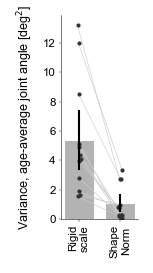

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/e-ja-variance.pdf')

In [29]:
rescale = True
_align_meta= {'scale': np.array(align_meta['scale'])}
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats_full, merged_params, None, rescale=rescale, scale_to=scale_to, _align_meta=_align_meta)
raw, _ = unalign_scales(_align_meta, dataset_versions_full['aligned'], None, None)
ja_canon = {s: _joint_angles(canonicalized.get_session(s), joint_kp_ixs) for s in dataset_feats.sessions}
ja_raw = {s: _joint_angles(raw.get_session(s), joint_kp_ixs) for s in dataset_feats.sessions}
ages = [ref_age] + tgt_ages
age_groups = {a: [s for s in dataset_feats.sessions if re.search(r"(\d+)wk", s).group(1) == a] for a in ages}
age_bhv_ja_canon = {k: [np.array([ja_canon[s][bhv_masks[k][s]].mean(axis = 0) for s in age_groups[a]]) for a in ages] for k in bhv_order}
age_ja_canon = [np.array([ja_canon[s].mean(axis = 0) for s in age_groups[a]]) for a in ages]
age_bhv_ja_raw = {k: [np.array([ja_raw[s][bhv_masks[k][s]].mean(axis = 0) for s in age_groups[a]]) for a in ages] for k in bhv_order}
age_ja_raw = [np.array([ja_raw[s].mean(axis = 0) for s in age_groups[a]]) for a in ages]
age_bhv_ja_canon_mean = {k: np.var([arr.mean(axis = 0) for arr in age_bhv_ja_canon[k]], axis = 0) for k in bhv_order}
age_ja_canon_mean = np.var([arr.mean(axis = 0) for arr in age_ja_canon], axis = 0)
age_bhv_ja_raw_mean = {k: np.var([arr.mean(axis = 0) for arr in age_bhv_ja_raw[k]], axis = 0) for k in bhv_order}
age_ja_raw_mean = np.var([arr.mean(axis = 0) for arr in age_ja_raw], axis = 0)



fig, ax = plt.subplots(figsize = (1, 1.8), dpi=150)


viz.util.grouped_stripplot(
    [age_ja_raw_mean, age_ja_canon_mean],
    x = [0, 1],
    colors = mpl_col.to_rgba('k'),
    points_kw={'ms': 1},
    lighten_points=0.2,
    errorbar_kw=dict(ms=0),
    error = lambda a, **kw: viz.util.ci(a, level=0.95, n=1000),
    connect=True,
    connection_kw = dict(lw=0.3, color='.8', ls='-'),
)
ax.bar([0], color = '.7', width=0.7, **viz.util.stem_bar(np.mean(age_ja_raw_mean), 0),)
ax.bar([1], color = '.7', width=0.7, **viz.util.stem_bar(np.mean(age_ja_canon_mean), 0),)

ax.set_ylabel("Variance, age-average joint angle [deg$^2$]")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Rigid\nscale", "Shape\nNorm"], rotation=90)
ax.set_ylim([0, 13.9])


plotter.finalize(fig, 'e-ja-variance', despine=False)

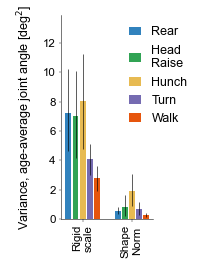

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/e-ja-variance-bhv.pdf')

In [31]:

fig, ax = plt.subplots(figsize = (1.1, 1.8), dpi=150)

tmp_bhv_order = ['rear', 'raise', 'hunch', 'turn', 'loco']
for i, k in enumerate(tmp_bhv_order):
    x = np.array([0, 1]) + 1.2 * viz.util.get_offsets(len(bhv_order), i)
    viz.util.grouped_stripplot(
        [age_bhv_ja_raw_mean[k], age_bhv_ja_canon_mean[k]],
        x = x,
        colors = 'k',
        points_kw={'ms': 1},
        lighten_points=0.2,
        errorbar_kw=dict(ms=0, elinewidth = 0.3),
        points=False,
        error = lambda a, **kw: viz.util.ci(a, level=0.95, n=1000),
    )
    ax.bar([x[0]], color = bhv_pal[k], width=0.12, **viz.util.stem_bar(np.mean(age_bhv_ja_raw_mean[k]), 0),)
    ax.bar([x[1]], color = bhv_pal[k], width=0.12, **viz.util.stem_bar(np.mean(age_bhv_ja_canon_mean[k]), 0), label=bhv_names[k])



ax.set_xticks([0, 1])
ax.set_xticklabels(["Rigid\nscale", "Shape\nNorm"], rotation=90)
ax.set_ylim([0, 13.9])
ax.set_ylabel("Variance, age-average joint angle [deg$^2$]")

fig.tight_layout()
ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1), fontsize=6, frameon=False,  handlelength=1.)

plotter.finalize(fig, 'e-ja-variance-bhv', despine=False, tight=False)


#### Normalized JA: affect on cohort GMM JSD

In [33]:

_align_meta = {"scale": np.array(align_meta["scale"])}
canonicalized, raw, _ = canonicalized_and_raw(
    dataset_feats, merged_params, None, rescale=True, scale_to=scale_to, _align_meta=_align_meta,
)
_, rigid, _ = canonicalized_and_raw(
    dataset_feats, merged_params, None, rescale=False
)
ages = [ref_age] + tgt_ages
age_groups = {
    a: [
        s for s in dataset_feats.sessions if re.search(r"(\d+)wk", s).group(1) == a
    ]
    for a in ages
}

# 52wk pose with bone lengths of morph onto 3wk ( = canon with joint angles of raw)
frames_C = {
    s: remove_angular_morph(
        raw.get_session(s), canonicalized.get_session(s), arms
    )
    for s in dataset_feats.sessions
}

# --- measure JSDs to reference session aross each
jsds = {}
for k, kpts in {
    "raw": {s: raw.get_session(s) for s in dataset_feats.sessions},
    "canon": {s: canonicalized.get_session(s) for s in dataset_feats.sessions},
    "rigid": {s: rigid.get_session(s) for s in dataset_feats.sessions},
    "noang": frames_C,
}.items():
    feats = {s: features.reduce_to_features(a, cfg["features"]) for s, a in kpts.items()}
    ref_cloud = clouds.PointCloudDensity(k=15).fit(feats[scale_to])
    jsds[k] = np.array([
        clouds.ball_cloud_js(
            ref_cloud, clouds.PointCloudDensity(k=15).fit(feats[s])
        )
        for s in dataset_feats.sessions if s != scale_to
    ])

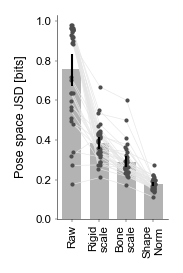

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/e-posespace-jsd-progression.pdf')

In [41]:
fig, ax = plt.subplots(figsize = (1.2, 1.8), dpi=150)

viz.util.grouped_stripplot(
    [jsds['raw'], jsds['rigid'], jsds['noang'], jsds['canon']],
    x = [0, 1, 2, 3],
    colors = mpl_col.to_rgba('k'),
    points_kw={'ms': 1},
    lighten_points=0.3,
    errorbar_kw=dict(ms=0),
    error = lambda a, **kw: viz.util.ci(a, level=0.95, n=1000),
    connect=True,
    connection_kw = dict(lw=0.3, color='.9', ls='-'),
)
ax.bar([0], color = '.7', width=0.7, **viz.util.stem_bar(np.mean(jsds['raw']), 0),)
ax.bar([1], color = '.7', width=0.7, **viz.util.stem_bar(np.mean(jsds['rigid']), 0),)
ax.bar([2], color = '.7', width=0.7, **viz.util.stem_bar(np.mean(jsds['noang']), 0),)
ax.bar([3], color = '.7', width=0.7, **viz.util.stem_bar(np.mean(jsds['canon']), 0),)

ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(["Raw", "Rigid\nscale", "Bone\nscale", "Shape\nNorm"], rotation=90)
ax.set_ylabel("Pose space JSD [bits]")

plotter.finalize(fig, 'e-posespace-jsd-progression', despine=False)

### F. pose-dependence of morph

#### Supporting functions: get bone length ratio and angle component

In [42]:
def frame_spherical_morph(frame_A, frame_B, arms):
    """
    Given two frames of keypoints, construct a copy of B with the joint angles
    of A.
    """
    angles_A = _joint_angles(frame_A, joint_kp_ixs)
    angles_B = _joint_angles(frame_B, joint_kp_ixs)
    lengths_A = _bone_lengths(frame_A, arms)
    lengths_B = _bone_lengths(frame_B, arms)
    return angles_B - angles_A, lengths_B / lengths_A

#### Example frames

0 : 1.3169683
1 : 1.436468


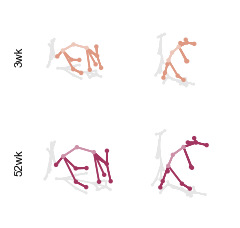

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/f-example-poses.pdf')

In [44]:
ex_sess = f"{tgt_age}wk_m1"

# canoncialize ex_sess onto 3wk_m0 body
rescale = True
_align_meta= {'scale': np.array(align_meta['scale'])}
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats, merged_params, None, rescale=rescale, scale_to=scale_to, _align_meta=_align_meta, canon_to=scale_to)
tgt_canon = canonicalized.get_session(ex_sess)
tgt_raw = raw.get_session(ex_sess)


back_ix = [bone_names.index(short_names.inverse[b]) for b in ['lo back', 'hi back']]
tl_canon = _bone_lengths(tgt_canon, arms)[:, back_ix].mean(axis = 1)
tl_raw = _bone_lengths(tgt_raw, arms)[:, back_ix].mean(axis = 1)
tl_ratio = tl_raw / tl_canon
frame_order = np.argsort(tl_ratio)


n_display=2
display = [20, -25]
_align_meta = {'scale': np.array(align_meta['scale'])}
anchors = anchor_keypoints(
    params.morph,
    {},
    magnitudes=anchor_magnitudes(dataset_feats, params.morph, q = 0.1),
    config=cfg,
    session_meta=dataset_feats.session_meta,
)
anchors_scaled = anchor_keypoints(
    params.morph,
    _align_meta,
    magnitudes=anchor_magnitudes(dataset_feats, params.morph, q = 0.1),
    config=cfg,
    session_meta=dataset_feats.session_meta,
)



gs = plt.GridSpec(2, n_display, height_ratios=[1, 1], wspace=0)
fig = plt.figure(figsize=(1.5, 1.5), dpi=150)
row0 = np.array([fig.add_subplot(gs[0, i], projection='3d') for i in range(n_display)])
row1 = np.array([fig.add_subplot(gs[1, i], projection='3d') for i in range(n_display)])

ref_body = dataset_feats.session_body_id(f'{ref_age}wk_m0')
tgt_body = dataset_feats.session_body_id(f'{tgt_age}wk_m0')
for i in range(n_display):
    row1[i].sharex(row0[i])
    row1[i].sharey(row0[i])
    row1[i].sharez(row0[i])

darken = lambda c, f: np.array([0, 0, 0, 1]) * f + (1 - f) * np.array(mpl_col.to_rgba(c))
back_clr = lambda c, d: [mpl_col.to_rgba(c) if arms.keypoint_names[i] not in ['hips', 'back', 'shldr'] else d for i in range(arms.n_kpts)]
for i in range(n_display):
    print(i, ":", tl_ratio[frame_order[display[i]]])
    plotdrop(canonicalized.get_session(ex_sess)[frame_order[display[i]]], row0[i], ref_color, 0.3, 0.5, True, shady=False, arms=arms, override=dict(colors=back_clr(ref_color, viz.util.lighten(ref_color, 0.45))))
    plotdrop(raw.get_session(ex_sess)[frame_order[display[i]]], row1[i], tgt_color, 0.3, 0.5, True, shady=False, arms=arms, override=dict(colors=back_clr(tgt_color, viz.util.lighten(tgt_color, 0.45))))

for a in [row0, row1]:
    a[0].view_init(30, -70)

fig.tight_layout()
row0[0].text2D(-0.15, 0.55, f"{ref_age}wk", ha = 'center', va = 'center', rotation=90, size=5.5, transform=row0[0].transAxes)
row1[0].text2D(-0.15, 0.55, f"{tgt_age}wk", ha = 'center', va = 'center', rotation=90, size=5.5, transform=row1[0].transAxes)


plotter.finalize(fig, 'f-example-poses', tight=False)

#### Ratio distributions by supervised behavior

In [159]:

rescale=True
_align_meta = {'scale': np.array(align_meta['scale'])}
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats_full, merged_params, None, rescale=rescale, scale_to=scale_to, _align_meta=_align_meta, canon_to=scale_to)
back_ix = [bone_names.index(short_names.inverse[b]) for b in ['lo back', 'hi back']]
tl_ratio = {
    s: _bone_lengths(raw.get_session(s), arms)[:, back_ix].mean(axis = 1) / _bone_lengths(canonicalized.get_session(s), arms)[:, back_ix].mean(axis = 1)
    for s in dataset_feats.sessions
}
tl_ratio_z = {
    s: (tl_ratio[s] - tl_ratio[s].mean()) / tl_ratio[s].std()
    for s in dataset_feats.sessions
}
ages = [ref_age] + tgt_ages
age_groups = {a: [s for s in dataset_feats.sessions if re.search(r"(\d+)wk", s).group(1) == a if s != scale_to] for a in ages}
bhv_tl_ratio_z = {k: {
    a: np.concatenate([tl_ratio_z[s][bhv_masks[k][s]] for s in age_groups[a]]) for a in ages
} for k in bhv_keys}
tl_ratio_z = {
    a: np.concatenate([tl_ratio_z[s] for s in age_groups[a]]) for a in ages
}



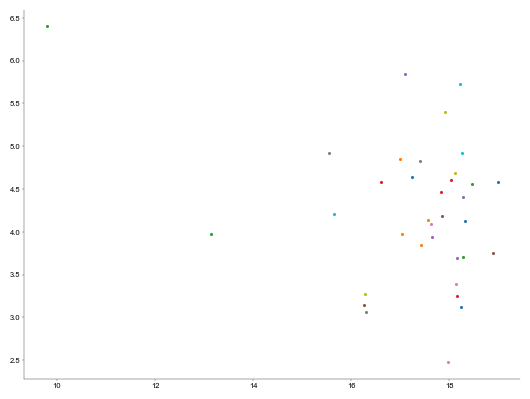

In [164]:

tl_ratio = {
    s: _bone_lengths(raw.get_session(s), arms)[:, back_ix].mean(axis = 1) / _bone_lengths(canonicalized.get_session(s), arms)[:, back_ix].mean(axis = 1)
    for s in dataset_feats.sessions
}
tl_ratio_z = {
    s: (tl_ratio[s] - tl_ratio[s].mean()) / tl_ratio[s].std()
    for s in dataset_feats.sessions
}
for s in dataset_feats.sessions:
    if s == scale_to:
        continue
    x =  _bone_lengths(canonicalized.get_session(s), arms)[:, back_ix].mean(axis = 1)
    y = tl_ratio_z[s]
    i = np.argsort(y)[-100]
    plt.scatter(x[i], y[i], s = 5, linewidths=0)

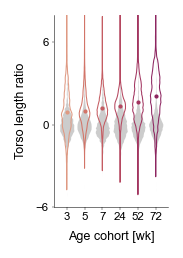

In [162]:
fig, ax = plt.subplots(figsize = (1.2, 1.7), dpi=150)
kw = dict(
    bw = 0.2,
    jitter = 0.,
    width=0.5,
    points=False,
    errorbar=False,
    fill=True,
    fill_kw=dict(linewidth=0.05),
    offset=False,
)
for i, a in enumerate(ages):
    # viz.util.grouped_violins(
    #     {a: [[tl_ratio_z[a]]]},
    #     x = [i],
    #     ax = ax,
    #     colors = '.6',
    #     **kw
    # )
    # viz.util.grouped_violins(
    #     {a: [[bhv_tl_ratio_z['rear'][a]]]},
    #     x = [i],
    #     ax = ax,
    #     colors = age_pal,
    #     **kw
    # )
    sns.violinplot(
        x = i,
        y = tl_ratio_z[a],
        bw_method=0.001,
        ax = ax,
        color = '.8',
        inner=None,
        linewidth=0,
    )
    sns.violinplot(
        x = i,
        y = bhv_tl_ratio_z['rear'][a],
        bw_method=0.05,
        width=0.6,
        ax = ax,
        color = age_pal[a],
        inner=None,
        linewidth=0.5,
        fill=False
    )
    viz.util.grouped_stripplot(
        {a: [bhv_tl_ratio_z['rear'][a]]},
        x = [i],
        colors = age_pal,
        points=False,
        errorbar_kw=dict(ms=1, elinewidth=.5),
        error = lambda a, **kw: viz.util.ci(a, level=0.95, n=1000),
        
    )
    # ax.hist(bhv_tl_ratio_z['rear'][a], bins=50, color=age_pal[a], lw = 0.5, density=True, histtype='step')
ax.set_ylim(-6, 8)
ax.set_yticks([-6, 0, 6])

ax.set_xticks(range(len(ages)))
ax.set_xticklabels(ages)
ax.set_xlabel("Age cohort [wk]")
ax.set_ylabel("Torso length ratio")
plotter.finalize(fig, None)

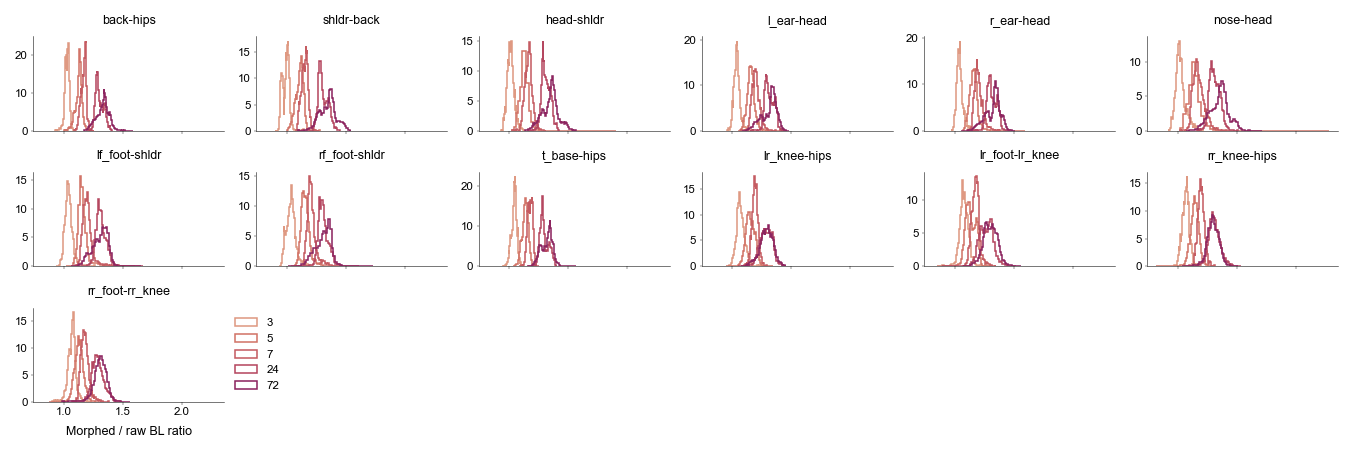

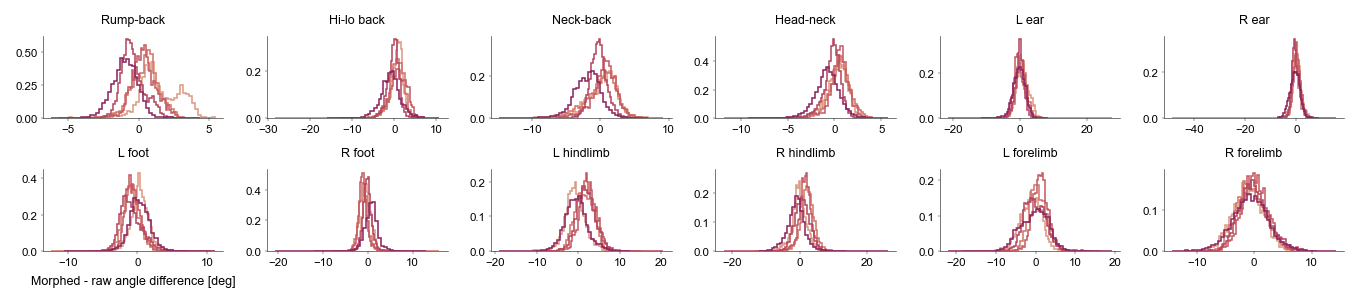

In [21]:
rescale = True


# ---- canonicalize, compute bone lengths of canonical and raw
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats, merged_params, rescale=True, _align_meta=align_meta, scale_to=scale_to)
spheres = {s: frame_spherical_morph(canonicalized.get_session(s), raw.get_session(s), arms) for s in dataset_feats.sessions}

morph_ref = dataset_feats.body_name(merged_params.ref_body)
morph_ref_age = re.search(r"(\d+)wk", morph_ref).group(1)


fig, axes, ax_grid = viz.util.flat_grid(arms.n_kpts - 1, min(6, arms.n_kpts - 1), ax_size = (1.5, 1), dpi=150, sharex=True)
age_order = sorted(age_groups.keys(), key=lambda x: int(x))
for i, (bname, ax) in enumerate(zip(bone_names, axes)):
    ax.set_title(bname)
    for a in age_order:
        age_sessions = age_groups[a]
        if a == morph_ref_age: continue
        ax.hist(
            np.concatenate([spheres[s][1][:, i] for s in age_sessions]),
            bins=50, color=age_pal[a], label=a, lw = 0.75, density=True, histtype='step'
        )
ax_grid[-1, 0].set_xlabel("Morphed / raw BL ratio")
fig.tight_layout()
viz.util.legend(ax_grid[-1, 0])
plotter.finalize(fig, 'posedep_bl_hist', tight=False)


fig, axes, ax_grid = viz.util.flat_grid(len(joint_names), min(6, len(joint_names)), ax_size = (1.5, 1), dpi=150, sharex=False)
for i, (jname, ax) in enumerate(zip(joint_names, axes)):
    ax.set_title(jname)
    for a in age_order:
        age_sessions = age_groups[a]
        if a == morph_ref_age: continue
        ax.hist(
            np.concatenate([spheres[s][0][:, i] for s in age_sessions]),
            bins=50, color=age_pal[a], label=a, lw = 0.75, density=True, histtype='step'
        )
ax_grid[-1, 0].set_xlabel("Morphed - raw angle difference [deg]")

plotter.finalize(fig, None)

In [170]:
bhv_masks.keys()

dict_keys(['rear', 'loco', 'raise', 'turn', 'hunch'])

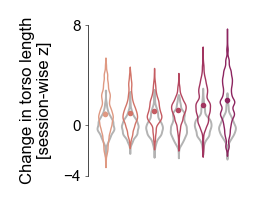

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/e-tl-ratio-bhv.pdf')

In [228]:
rescale = False


# ---- canonicalize, compute bone lengths of canonical and raw
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats_full, merged_params, rescale=True, _align_meta=align_meta, scale_to=scale_to, canon_to=scale_to)
spheres = {s: frame_spherical_morph(canonicalized.get_session(s), raw.get_session(s), arms) for s in dataset_feats.sessions}

morph_ref = dataset_feats.body_name(merged_params.ref_body)
morph_ref_age = re.search(r"(\d+)wk", morph_ref).group(1)
bhv_order = list(bhv_keys.keys())
sub_to = lambda x, n: x[::int(np.ceil(len(x)/n))][:n]
no_z_outs = lambda x: x[abs(x - x.mean()) / np.std(x) < 3]
back_ix = [bone_names.index(short_names.inverse[b]) for b in ['lo back', 'hi back']]

fig, ax = plt.subplots(figsize = (1.3, 1.), dpi=200)

for a, age_sessions in age_groups.items():
    age_order = sorted(list(age_groups.keys()), key=lambda x: int(x))
    i_age = age_order.index(a)

    i = back_ix[0]
    tl = [spheres[s][1][:, back_ix].mean(axis = -1) for s in age_sessions]
    spheres_z = [(x - x.mean()) / x.std() for x in tl]
    measure = np.concatenate(spheres_z)
    mask = np.concatenate([bhv_masks['rear'][s] for s in age_sessions])
    
    # conditioned on rearing: distribution and mean
    viz.util.grouped_violins(
        [[sub_to(no_z_outs(measure[mask]), 300)]],
        bw = 0.22,
        thumb_bandwidth=True,
        x=[i_age],
        ax = ax,
        colors=age_pal[a],
        points=False,
        jitter=0.,
        width=0.6,
        errorbar=False,
        fill=False,
        bw_buffer=2,
        fill_kw=dict(linewidth=0.5),
    )
    viz.util.grouped_stripplot(
        {a: [sub_to(no_z_outs(measure[mask]), 300)]},
        x = [i_age],
        colors = age_pal,
        points=False,
        errorbar_kw=dict(ms=1, elinewidth=.5),
        error = lambda a, **kw: viz.util.ci(a, level=0.95, n=1000),
    )

    # all frames
    viz.util.grouped_violins(
        [[sub_to(no_z_outs(measure), 300)]],
        bw = 0.2,
        thumb_bandwidth=True,
        x=[i_age],
        ax = ax,
        colors='.7',
        points=False,
        jitter=0.,
        width=0.7,
        errorbar=False,
        fill=False,
        fill_kw=dict(linewidth=0.7, zorder=-3),
    )

ax.set_ylim(-4, 8)
ax.set_yticks([-4, 0, 8])
ax.set_xlim(-0.7, len(age_groups) - 0.3)

# ax.set_xticks(range(len(ages)))
# ax.set_xticklabels(ages)
# ax.set_xlabel("Age cohort [wk]")
ax.set_xticks([])
ax.spines['bottom'].set_visible(False)
ax.set_ylabel("Change in torso length\n[session-wise z]")

# sns.despine(ax = ax, trim = True)

plotter.finalize(fig, 'e-tl-ratio-bhv', despine=False)

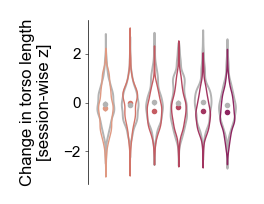

In [949]:
rescale = False


# ---- canonicalize, compute bone lengths of canonical and raw
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats_full, merged_params, rescale=True, _align_meta=align_meta, scale_to=scale_to, canon_to=scale_to)
spheres = {s: frame_spherical_morph(canonicalized.get_session(s), raw.get_session(s), arms) for s in dataset_feats.sessions}

morph_ref = dataset_feats.body_name(merged_params.ref_body)
morph_ref_age = re.search(r"(\d+)wk", morph_ref).group(1)
bhv_order = list(bhv_keys.keys())
sub_to = lambda x, n: x[::int(np.ceil(len(x)/n))][:n]
no_z_outs = lambda x: x[abs(x - x.mean()) / np.std(x) < 3]
back_ix = [bone_names.index(short_names.inverse[b]) for b in ['lo back', 'hi back']]

fig, ax = plt.subplots(figsize = (1.3, 1.), dpi=200)

for a, age_sessions in age_groups.items():
    age_order = sorted(list(age_groups.keys()), key=lambda x: int(x))
    i_age = age_order.index(a)

    i = back_ix[0]
    tl = [spheres[s][1][:, back_ix].mean(axis = -1) for s in age_sessions]
    spheres_z = [(x - x.mean()) / x.std() for x in tl]
    measure = np.concatenate(spheres_z)
    mask = np.concatenate([bhv_masks['hunch'][s] for s in age_sessions])
    
    # conditioned on rearing: distribution and mean
    viz.util.grouped_violins(
        [[sub_to(no_z_outs(measure[mask]), 300)]],
        bw = 0.22,
        thumb_bandwidth=True,
        x=[i_age],
        ax = ax,
        colors=age_pal[a],
        points=False,
        jitter=0.,
        width=0.6,
        errorbar=False,
        fill=False,
        bw_buffer=2,
        fill_kw=dict(linewidth=0.5),
    )
    viz.util.grouped_stripplot(
        {a: [sub_to(no_z_outs(measure[mask]), 300)]},
        x = [i_age],
        colors = age_pal,
        points=False,
        errorbar_kw=dict(ms=1, elinewidth=.5),
        error = lambda a, **kw: viz.util.ci(a, level=0.95, n=1000),
    )

    # all frames
    viz.util.grouped_violins(
        [[sub_to(no_z_outs(measure), 300)]],
        bw = 0.2,
        thumb_bandwidth=True,
        x=[i_age],
        ax = ax,
        colors='.7',
        points=False,
        jitter=0.,
        width=0.7,
        errorbar=False,
        fill=False,
        fill_kw=dict(linewidth=0.7, zorder=-3),
    )
    viz.util.grouped_stripplot(
        {a: [sub_to(no_z_outs(measure), 300)]},
        x = [i_age],
        colors = '.7',
        points=False,
        errorbar_kw=dict(ms=1, elinewidth=.5),
        error = lambda a, **kw: viz.util.ci(a, level=0.95, n=1000),
    )

# ax.set_ylim(-4, 8)
# ax.set_yticks([-4, 0, 8])
ax.set_xlim(-0.7, len(age_groups) - 0.3)

# ax.set_xticks(range(len(ages)))
# ax.set_xticklabels(ages)
# ax.set_xlabel("Age cohort [wk]")
ax.set_xticks([])
ax.spines['bottom'].set_visible(False)
ax.set_ylabel("Change in torso length\n[session-wise z]")

# sns.despine(ax = ax, trim = True)

plotter.finalize(fig, None, despine=False)

[-0.04988741  0.02786793 -0.02379679]
[-0.0103629  -0.04365224  0.00131041 -0.00235696 -0.02171643 -0.04367904
 -0.00744124  0.0154203 ]
[ 0.00047443 -0.00409689 -0.03203019  0.01298049]
[-0.00779545  0.01815663  0.01386955  0.01331061  0.02423109  0.01506927]
[ 0.00781698 -0.02087938 -0.00403851  0.02466165  0.0272659   0.0229129 ]
[-0.01519312 -0.0225005  -0.00216417  0.04046144  0.02392716  0.01772963
  0.02427617  0.00726464]


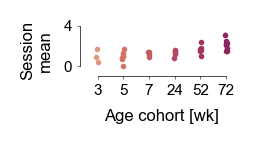

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/e-tl-ratio-bhv-subj.pdf')

In [240]:
rescale = False


# ---- canonicalize, compute bone lengths of canonical and raw
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats_full, merged_params, rescale=True, _align_meta=align_meta, scale_to=scale_to, canon_to=scale_to)
spheres = {s: frame_spherical_morph(canonicalized.get_session(s), raw.get_session(s), arms) for s in dataset_feats.sessions}

morph_ref = dataset_feats.body_name(merged_params.ref_body)
morph_ref_age = re.search(r"(\d+)wk", morph_ref).group(1)
bhv_order = list(bhv_keys.keys())
sub_to = lambda x, n: x[::int(np.ceil(len(x)/n))][:n]
no_z_outs = lambda x: x[abs(x - x.mean()) / np.std(x) < 2.8]
back_ix = [bone_names.index(short_names.inverse[b]) for b in ['lo back', 'hi back']]

fig, ax = plt.subplots(figsize = (1.3, 0.7), dpi=200)

for a, age_sessions in age_groups.items():
    age_order = sorted(list(age_groups.keys()), key=lambda x: int(x))
    i_age = age_order.index(a)

    i = back_ix[0]
    tl = [spheres[s][1][:, back_ix].mean(axis = -1) for s in age_sessions]
    spheres_z = [(x - x.mean()) / x.std() for x in tl]
    measure = spheres_z
    mask = ([bhv_masks['rear'][s] for s in age_sessions])
    
    # conditioned on rearing: distribution and mean
    # viz.util.grouped_violins(
    #     [[sub_to(no_z_outs(me[ma]), 300) for me, ma in zip(measure, mask)],],
    #     bw = 0.22,
    #     thumb_bandwidth=True,
    #     x=[i_age],
    #     ax = ax,
    #     colors=age_pal[a],
    #     points=False,
    #     jitter=0.,
    #     width=0.6,
    #     errorbar=False,
    #     fill=False,
    #     bw_buffer=2,
    #     fill_kw=dict(linewidth=0.5),
    # )
    jtr = viz.util.jitter_points(np.zeros(len(measure)), scale = 0.05)
    print(jtr)
    for me, ma, j in zip(measure, mask, jtr):
        viz.util.grouped_stripplot(
            {a: [sub_to(no_z_outs(me[ma]), 300)]},
            x = [i_age + j],
            colors = age_pal,
            points=False,
            errorbar_kw=dict(ms=1, elinewidth=.5),
            error = lambda a, **kw: viz.util.ci(a, level=0.95, n=1000),
        )

ax.set_xticks(range(len(bhv_order)))
ax.set_xticklabels([bhv_names[k] for k in bhv_order])
ax.set_ylabel("Morphed bone length\n[agewise z]")

ax.set_ylim(-1, 4)
ax.set_yticks([0, 4])
# ax.axhline(0, ls = '--', color='.5', lw=0.5)
ax.set_xlim(-0.7, len(age_groups) - 0.3)

ax.set_xticks(range(len(ages)))
ax.set_xticklabels(ages)
ax.set_xlabel("Age cohort [wk]")
ax.set_ylabel("Session\nmean")

sns.despine(ax = ax, trim = True)

plotter.finalize(fig, 'e-tl-ratio-bhv-subj')

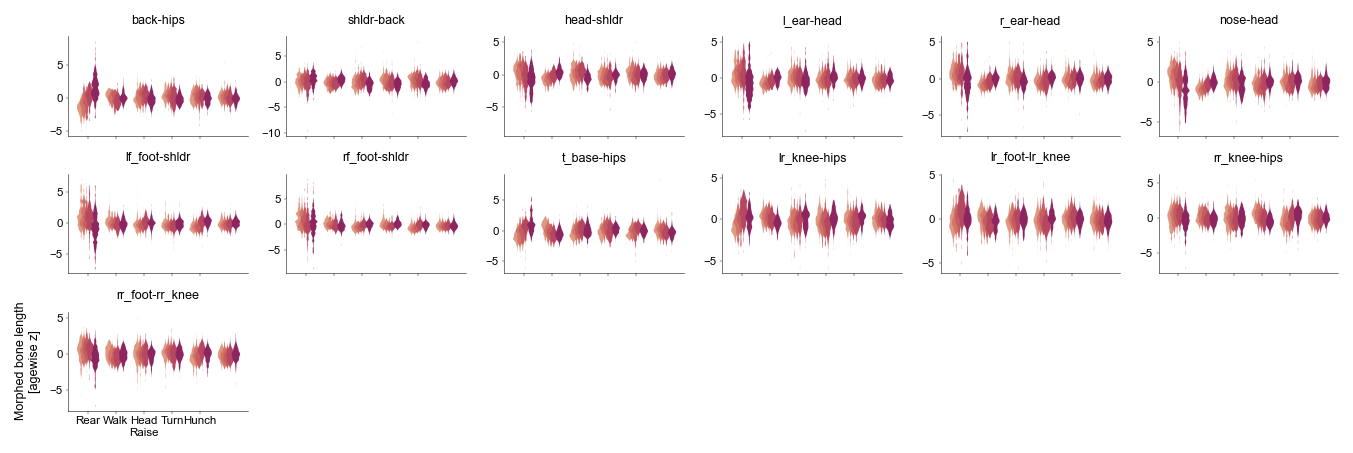

In [22]:
rescale = False


# ---- canonicalize, compute bone lengths of canonical and raw
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats_full, merged_params, rescale=True, _align_meta=align_meta, scale_to=scale_to)
spheres = {s: frame_spherical_morph(canonicalized.get_session(s), raw.get_session(s), arms) for s in dataset_feats.sessions}

morph_ref = dataset_feats.body_name(merged_params.ref_body)
morph_ref_age = re.search(r"(\d+)wk", morph_ref).group(1)
bhv_order = list(bhv_keys.keys())
sub_to = lambda x, n: x[::int(np.ceil(len(x)/n))][:n]
no_z_outs = lambda x: x[abs(x) < 10]

fig, axes, ax_grid = viz.util.flat_grid((arms.n_kpts - 1), min(6, arms.n_kpts - 1), ax_size = (1.5, 1), dpi=150, sharex=True)
for i, (bname, ax) in enumerate(zip(bone_names, axes)):
    ax.set_title(bname)
    for a, age_sessions in age_groups.items():
        age_order = sorted(list(age_groups.keys()), key=lambda x: int(x))
        i_age = age_order.index(a)
        if a == morph_ref_age: continue
        spheres_z = [(spheres[s][1][:, i] - spheres[s][1][:, i].mean()) / spheres[s][1][:, i].std() for s in age_sessions]
        measure = np.concatenate(spheres_z)
        mask = {k: np.concatenate([bhv_masks[k][s] for s in age_sessions]) for k in bhv_order}
        nonemask = ~np.any([mask[k] for k in bhv_order], axis=0)
        # measure_z = (measure - np.mean(measure)) / np.std(measure)
        
        viz.util.grouped_violins(
            [[sub_to(no_z_outs(measure[mask[k]]), 190)] for k in bhv_order],
            bw = 0.2,
            x=np.arange(len(bhv_order)) + viz.util.get_offsets(len(age_groups), i_age),
            ax = ax,
            colors=age_pal[a],
            points=False,
            jitter=0.,
            width=0.6,
            stroke=False,
            errorbar=False,
            fill=True,
        )

        viz.util.grouped_violins(
            [[sub_to(no_z_outs(measure[nonemask]), 190)]],
            bw = 0.2,
            x=[len(bhv_order) + viz.util.get_offsets(len(age_groups), i_age)],
            ax = ax,
            colors=age_pal[a],
            points=False,
            jitter=0.,
            width=0.7,
            stroke=False,
            errorbar=False,
            fill=True,
        )
    ax.set_xticks(range(len(bhv_order)))
    ax.set_xticklabels([bhv_names[k] for k in bhv_order])
ax_grid[-1, 0].set_ylabel("Morphed bone length\n[agewise z]")

plotter.finalize(fig, None)

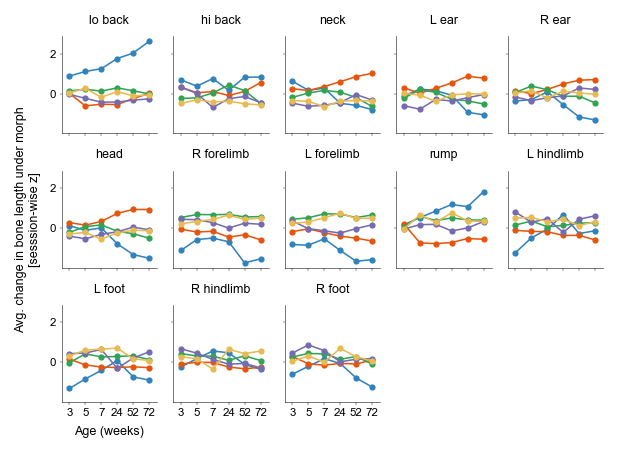

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/fS-bone-lengths.pdf')

In [992]:
rescale = False


# ---- canonicalize, compute bone lengths of canonical and raw
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats_full, merged_params, rescale=True, _align_meta=align_meta, scale_to=scale_to, canon_to=scale_to)
spheres = {s: frame_spherical_morph(canonicalized.get_session(s), raw.get_session(s), arms) for s in dataset_feats.sessions}

morph_ref = dataset_feats.body_name(merged_params.ref_body)
morph_ref_age = re.search(r"(\d+)wk", morph_ref).group(1)
bhv_order = list(bhv_keys.keys())
sub_to = lambda x, n: x[::int(np.ceil(len(x)/n))][:n]
no_z_outs = lambda x: x[abs(x) < 10]

fig, axes, ax_grid = viz.util.flat_grid((arms.n_kpts - 1), min(5, arms.n_kpts - 1), ax_size = (0.82, 1), dpi=150, sharex=True, sharey=True)
for i, (bname, ax) in enumerate(zip(bone_names, axes)):
    means = {k: [] for k in bhv_order}
    cis = {k: [] for k in bhv_order}
    
    ax.set_title(short_names[bname])
    for a, age_sessions in age_groups.items():
        age_order = sorted(list(age_groups.keys()), key=lambda x: int(x))
        i_age = age_order.index(a)
        
        spheres_z = [(spheres[s][1][:, i] - spheres[s][1][:, i].mean()) / spheres[s][1][:, i].std() for s in age_sessions if s != scale_to]
        measure = np.concatenate(spheres_z)
        mask = {k: np.concatenate([bhv_masks[k][s] for s in age_sessions if s != scale_to]) for k in bhv_order}
        nonemask = ~np.any([mask[k] for k in bhv_order], axis=0)
        # measure_z = (measure - np.mean(measure)) / np.std(measure)
        
        for j, k in enumerate(bhv_order):
            # viz.util.grouped_violins(
            #     [[sub_to(no_z_outs(measure[mask[k]]), 190)]],
            #     bw = 0.2,
            #     x=[viz.util.get_offsets(len(bhv_order), j) + i_age],
            #     ax = ax,
            #     colors=viz.util.lighten(bhv_pal[k], 0.5),
            #     points=False,
            #     jitter=0.,
            #     width=0.3,
            #     stroke=False,
            #     errorbar=False,
            #     fill=True,
            # )
            means[k].append((i_age, np.mean(measure[mask[k]])))
            cis[k].append((i_age, viz.util.ci(measure[mask[k]], level=0.95, n=50, absolute=True)))
    ax.set_xticks(range(len(age_order)))
    ax.set_xticklabels(age_order)
    ax.set_xlim(-0.5, len(age_order) - 0.5)

    for j, k in enumerate(bhv_order):
        x = sorted(means[k], key=lambda x: int(x[0]))
        ax.plot(
            *zip(*x),
            color=bhv_pal[k],
            lw=0.75,
            marker='o',
            mew=0,
            ms = 3,
            label=bhv_names[k],
        )
        for x, ci in sorted(cis[k], key=lambda x: int(x[0])):
            ax.plot([x, x], ci, color=bhv_pal[k], lw=0.5)

ax_grid[-1, 0].set_xlabel("Age (weeks)")
ax_grid[1, 0].set_ylabel("Avg. change in bone length under morph\n[sesssion-wise z]")

plotter.finalize(fig, 'fS-bone-lengths')

In [134]:
joint_short_names

bidict({'t_base-hips-back': 'Rump-back', 'hips-back-shldr': 'Hi-lo back', 'back-shldr-head': 'Neck-back', 'shldr-head-nose': 'Head-neck', 'l_ear-head-shldr': 'L ear', 'r_ear-head-shldr': 'R ear', 'lr_knee-hips-back': 'L hindlimb', 'lr_foot-lr_knee-hips': 'L foot', 'rr_knee-hips-back': 'R hindlimb', 'rr_foot-rr_knee-hips': 'R foot', 'lf_foot-shldr-back': 'L forelimb', 'rf_foot-shldr-back': 'R forelimb'})

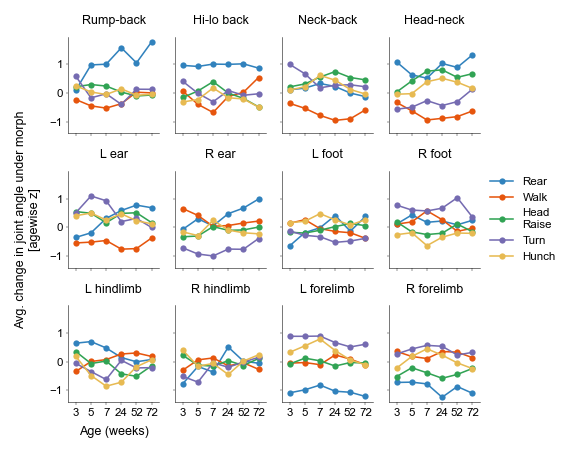

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/fS-all-joint-angles.pdf')

In [993]:
rescale = False


# ---- canonicalize, compute bone lengths of canonical and raw
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats_full, merged_params, rescale=True, _align_meta=align_meta, scale_to=scale_to, canon_to=scale_to)
spheres = {s: frame_spherical_morph(canonicalized.get_session(s), raw.get_session(s), arms) for s in dataset_feats.sessions}

morph_ref = dataset_feats.body_name(merged_params.ref_body)
morph_ref_age = re.search(r"(\d+)wk", morph_ref).group(1)
bhv_order = list(bhv_keys.keys())
sub_to = lambda x, n: x[::int(np.ceil(len(x)/n))][:n]
no_z_outs = lambda x: x[abs(x) < 10]

fig, axes, ax_grid = viz.util.flat_grid((len(joint_names)), min(4, len(joint_names)), ax_size = (0.82, 1), dpi=150, sharex=True, sharey=True)
for i, (jname, ax) in enumerate(zip(joint_names, axes)):
    means = {k: [] for k in bhv_order}
    cis = {k: [] for k in bhv_order}
    
    ax.set_title(jname)
    for a, age_sessions in age_groups.items():
        age_order = sorted(list(age_groups.keys()), key=lambda x: int(x))
        i_age = age_order.index(a)
        
        spheres_z = [(spheres[s][0][:, i] - spheres[s][0][:, i].mean()) / spheres[s][0][:, i].std() for s in age_sessions if s != scale_to]
        measure = np.concatenate(spheres_z)
        mask = {k: np.concatenate([bhv_masks[k][s] for s in age_sessions if s != scale_to]) for k in bhv_order}
        nonemask = ~np.any([mask[k] for k in bhv_order], axis=0)
        
        for j, k in enumerate(bhv_order):
            means[k].append((i_age, np.mean(measure[mask[k]])))
            cis[k].append((i_age, viz.util.ci(measure[mask[k]], level=0.95, n=50, absolute=True)))
    ax.set_xticks(range(len(age_order)))
    ax.set_xticklabels(age_order)
    ax.set_xlim(-0.5, len(age_order) - 0.5)

    for j, k in enumerate(bhv_order):
        x = sorted(means[k], key=lambda x: int(x[0]))
        ax.plot(
            *zip(*x),
            color=bhv_pal[k],
            lw=0.75,
            marker='o',
            mew=0,
            ms = 3,
            label=bhv_names[k],
        )
        for x, ci in sorted(cis[k], key=lambda x: int(x[0])):
            ax.plot([x, x], ci, color=bhv_pal[k], lw=0.5)

ax_grid[-1, 0].set_xlabel("Age (weeks)")
ax_grid[1, 0].set_ylabel("Avg. change in joint angle under morph\n[agewise z]")

fig.tight_layout()
viz.util.legend(ax_grid[1, -1])

plotter.finalize(fig, "fS-all-joint-angles", tight=False)

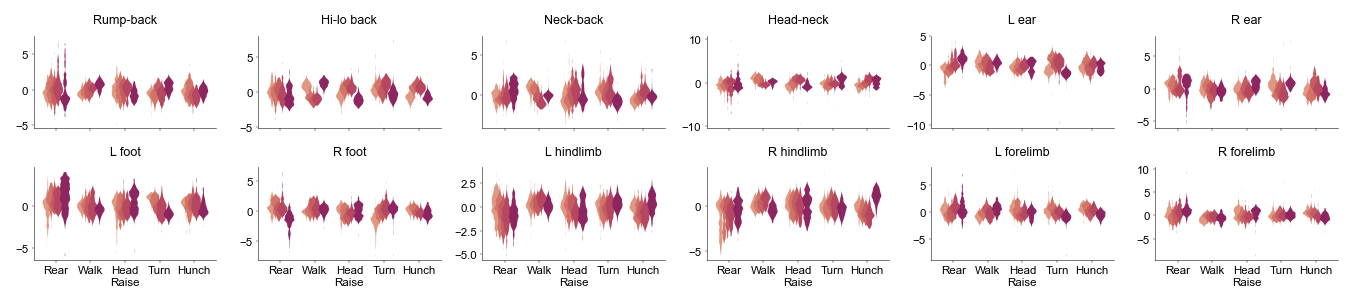

In [39]:
rescale = False


# ---- canonicalize, compute bone lengths of canonical and raw
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats_full, merged_params, rescale=True, _align_meta=align_meta, scale_to=scale_to)
spheres = {s: frame_spherical_morph(canonicalized.get_session(s), raw.get_session(s), arms) for s in dataset_feats.sessions}

morph_ref = dataset_feats.body_name(merged_params.ref_body)
morph_ref_age = re.search(r"(\d+)wk", morph_ref).group(1)
bhv_order = list(bhv_keys.keys())
sub_to = lambda x, n: x[::int(np.ceil(len(x)/n))][:n]
no_z_outs = lambda x: x[abs(x) < 10]

fig, axes, ax_grid = viz.util.flat_grid((len(joint_names)), min(6, len(joint_names)), ax_size = (1.5, 1), dpi=150, sharex=True)
for i, (bname, ax) in enumerate(zip(joint_names, axes)):
    ax.set_title(bname)
    for a, age_sessions in age_groups.items():
        age_order = sorted(list(age_groups.keys()), key=lambda x: int(x))
        i_age = age_order.index(a)
        if a == morph_ref_age: continue
        measure = np.concatenate([spheres[s][0][:, i] for s in age_sessions])
        mask = {k: np.concatenate([bhv_masks[k][s] for s in age_sessions]) for k in bhv_order}
        measure_z = (measure - np.mean(measure)) / np.std(measure)
        
        viz.util.grouped_violins(
            [[sub_to(no_z_outs(measure_z[mask[k]]), 190)] for k in bhv_order],
            bw = 0.2,
            x=np.arange(len(bhv_order)) + viz.util.get_offsets(len(age_groups), i_age),
            ax = ax,
            colors=age_pal[a],
            points=False,
            jitter=0.,
            width=0.3,
            stroke=False,
            errorbar=False,
            fill=True,
        )
    ax.set_xticks(range(len(bhv_order)))
    ax.set_xticklabels([bhv_names[k] for k in bhv_order])
            

plotter.finalize(fig, None)

In [978]:
nframes = int(30000 * 0.03)
print(nframes)
frames = []
bls_z = []
bls_q = []
ages = []
ids = []
session_ids = []
bone = []
hilo = []

def quantileofscore(x):
    ret = np.zeros(x.shape)
    ret[np.argsort(x)] = np.linspace(0, 1, len(x)+1)[1:] - (1/len(x)/2)
    return ret
age_order = sorted(list(age_groups.keys()), key=lambda x: int(x))

canonicalized, raw, _ = canonicalized_and_raw(dataset_feats_full, merged_params, rescale=True, _align_meta=align_meta, scale_to=scale_to, canon_to=scale_to)
_spheres = {s: frame_spherical_morph(canonicalized.get_session(s), raw.get_session(s), arms) for s in dataset_feats.sessions}
morph_ref = scan_dataset.body_name(merged_params.ref_body)
morph_ref_age = re.search(r"(\d+)wk", morph_ref).group(1)
session_ages = {s: re.search(r"(\d+)wk", s).group(1) for s in dataset_feats.sessions}
back_ix = [bone_names.index(short_names.inverse[b]) for b in ['lo back', 'hi back']]


for session in dataset_feats.sessions:
    if session == scale_to:
        continue
    animal_id = re.search(r"m(\d+)", session).group(1)

    measure = _spheres[session][1][:, back_ix].mean(axis = 1) # bone lengths
    frames_sorted = np.argsort(measure)
    ixs = np.concatenate([frames_sorted[:nframes], frames_sorted[-nframes:]])
    measure_z = (measure - measure.mean()) / measure.std()
    measure_q = quantileofscore(measure)

    frames.append(canonicalized.get_session(session)[ixs])
    bls_z.append(measure_z[ixs])
    bls_q.append(measure_q[ixs])
    ages.append(np.full(nframes * 2, session_ages[session]))
    ids.append(np.full(nframes * 2, int(animal_id)))
    bone.append(np.full(nframes * 2, bname))
    hilo.append(np.concatenate([np.full(nframes, 0), np.full(nframes, 1)]))
    session_ids.append(np.full(nframes * 2, dataset_feats.session_id(session)))

shared_pc = PCA(n_components=4).fit(canonicalized._data.reshape(-1, arms.n_kpts * 3))
frames_pc = shared_pc.transform(np.concatenate(frames).reshape(-1, arms.n_kpts * 3))
df = pd.DataFrame(dict(
    z = np.concatenate(bls_z),
    q = np.concatenate(bls_q),
    age = np.concatenate(ages),
    id = np.concatenate(ids),
    session_id = np.concatenate(session_ids),
    hilo = np.concatenate(hilo),
    bone = np.concatenate(bone),
    **{f"pc{i}": frames_pc[:, i] for i in range(4)}
))


900


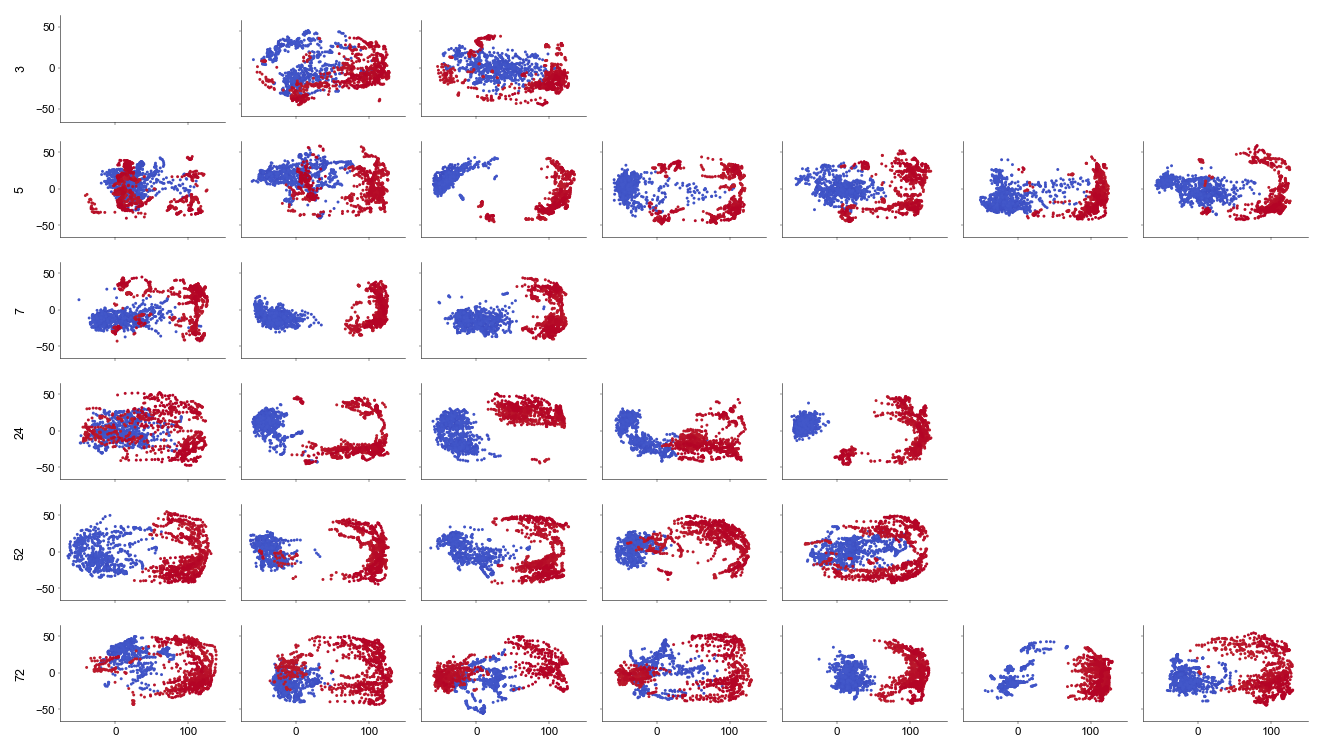

In [25]:
fig, ax = plt.subplots(len(age_groups), df.id.max() + 1, figsize = (10, 5), dpi=150, sharex=True, sharey=True)
for i, a in enumerate([a for a in age_order]):
    d = df[df.age == a]
    for j in d.id.unique():
        f = d[d.id == j]
        ax[i, j].scatter(f.pc0, f.pc1, c=f.q, s=2, cmap='coolwarm', lw=0)
        ax[i, j].set_aspect('equal')
    for j in range(d.id.max(), ax.shape[1]):
        ax[i, j].set_visible(False)
    ax[i, 0].set_ylabel(a)
plotter.finalize(fig, None)

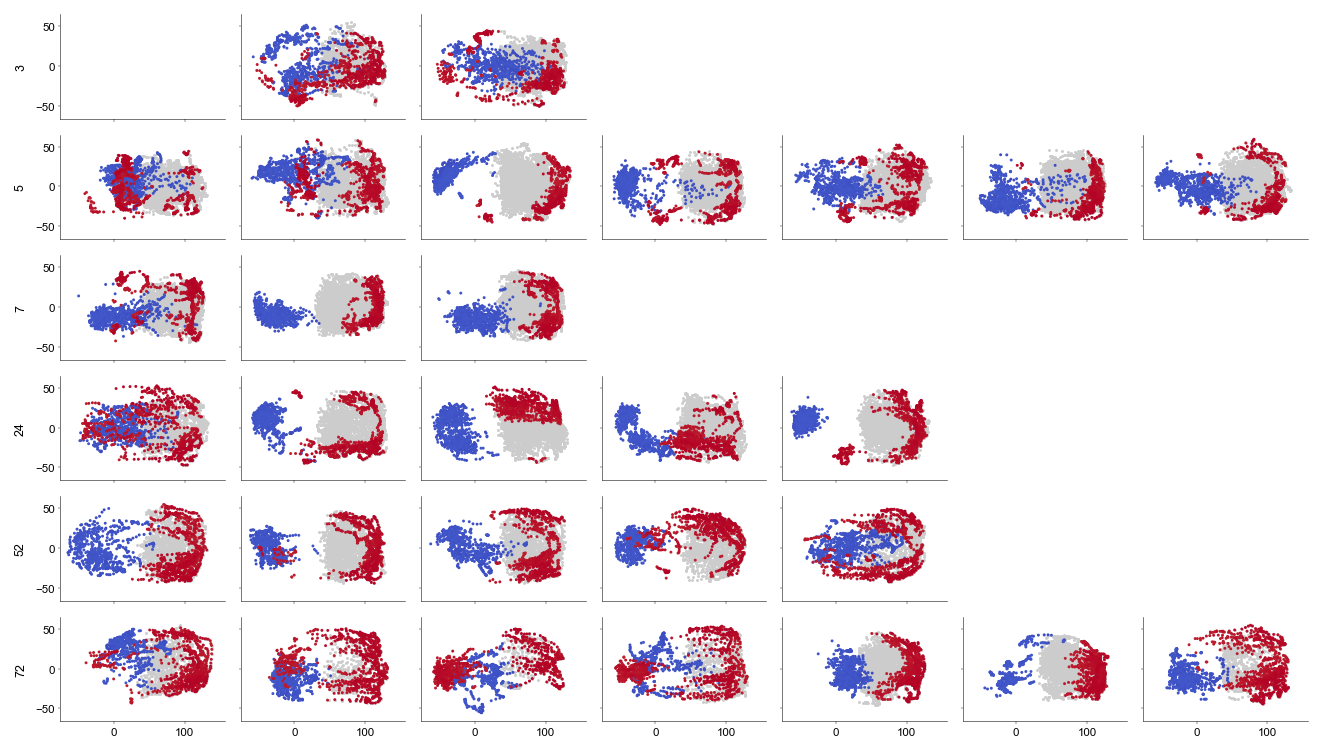

In [26]:
fig, ax = plt.subplots(len(age_groups), df.id.max() + 1, figsize = (10, 5), dpi=150, sharex=True, sharey=True)
for i, a in enumerate([a for a in age_order]):
    d = df[df.age == a]
    for j in d.id.unique():
        f = d[d.id == j]
        session_id = f.session_id.values[0]
        session = dataset_feats.session_name(session_id)
        
        x = shared_pc.transform(canonicalized.get_session(session).reshape(-1, arms.n_kpts * 3))
        ax[i, j].scatter(*x[bhv_masks['rear'][session]][:, [0, 1]].T, s=2, lw=0, color = '.8')
        ax[i, j].scatter(f.pc0, f.pc1, c=f.q, s=2, cmap='coolwarm', lw=0)
    for j in range(d.id.max(), ax.shape[1]):
        ax[i, j].set_visible(False)
    ax[i, 0].set_ylabel(a)
plotter.finalize(fig, None)

In [30]:
df.bone.unique()

array(['rr_foot-rr_knee'], dtype=object)

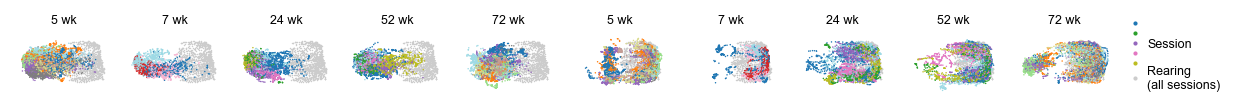

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/eS-subj-consistency.pdf')

In [995]:
fig, axes = plt.subplots(1, 2*(len(age_groups) - 1), figsize = (7.5, 1.), dpi=150, sharex=True, sharey=True)
axes = axes[:]


for i, (a, (ax_lo, ax_hi)) in enumerate(zip([a for a in age_order if a != ref_age], axes.T.reshape(2, len(age_groups) - 1).T)):
    
    d = df[(df.age == a)]
    dhi = d[d.hilo == 1]
    dlo = d[d.hilo == 0]
    cmap = Colormap('tab20').to_mpl()
    x = dlo.pc0.values; y = dlo.pc1.values; c = dlo.id.values
    shuf = np.random.permutation(len(x))
    # ax_lo.scatter(dhi.pc0, dhi.pc1, c='.9', s=0.5, lw=0)
    ax_lo.scatter(x[shuf], y[shuf], c=c[shuf], s=0.5, cmap=cmap, lw=0)

    
    x = dhi.pc0.values; y = dhi.pc1.values; c = dhi.id.values
    shuf = np.random.permutation(len(x))
    # ax_hi.scatter(dlo.pc0, dlo.pc1, c='.9', s=0.5, lw=0)
    ax_hi.scatter(x[shuf], y[shuf], c=c[shuf], s=0.5, cmap=cmap, lw=0)

    x = shared_pc.transform(canonicalized.get_session(session).reshape(-1, arms.n_kpts * 3))
    ax_hi.scatter(*x[bhv_masks['rear'][session]][:, [0, 1]].T, s=0.5, lw=0, color = '.8', zorder = -2, rasterized=True)
    ax_lo.scatter(*x[bhv_masks['rear'][session]][:, [0, 1]].T, s=0.5, lw=0, color = '.8', zorder = -2, rasterized=True)
    
    ax_lo.set_title(f"{a} wk")
    ax_hi.set_title(f"{a} wk")
    ax_lo.set_axis_off()
    ax_hi.set_axis_off()
    ax_lo.set_aspect('equal')
    ax_hi.set_aspect('equal')

    clrs = Colormap('tab20')(np.linspace(0, 1, 6))
    handles = [ax_hi.plot([np.nan], [np.nan], 'o', color=c, ms=1, label = " ")[0] for c in clrs]
    handles_shuf = ax_hi.plot([np.nan], [np.nan], 'o', color='.8', ms=1, label = " ")

fig.tight_layout()


leg = viz.util.legend(axes[-1], (handles, " " * len(tgt_ages)), loc='center left', bbox_to_anchor = (1.0, 0.85), labelspacing=0,)
axes[-1].text(1.35, 0.85, "Session", ha='left', va='center', transform=axes[-1].transAxes)
viz.util.legend(axes[-1], (handles_shuf, [" "]), loc='center left', bbox_to_anchor = (1.0, 0.25), labelspacing=0.,)
axes[-1].text(1.35, 0.25, "Rearing\n(all sessions)", ha='left', va='center', transform=axes[-1].transAxes)
axes[-1].add_artist(leg)

plotter.finalize(fig, 'eS-subj-consistency', tight=False)

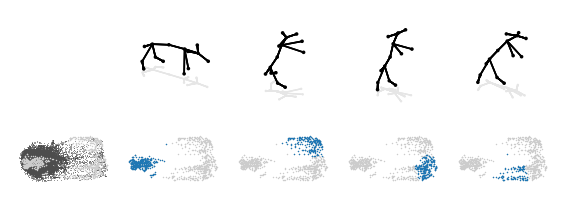

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/eS-example-high-clust.pdf')

In [985]:
session = "72wk_m3"
measure = _spheres[session][1][:, back_ix].mean(axis = 1) # bone lengths
selected = measure.argsort()[-nframes:]
X = canonicalized.get_session(session)[selected].reshape(-1, arms.n_kpts * 3)
shared_pc_10 = PCA(n_components=10).fit(canonicalized._data.reshape(-1, arms.n_kpts * 3))
X_pc = shared_pc_10.transform(X)
ncl=4
clust = KMeans(n_clusters=ncl, random_state=0).fit_predict(X_pc)

fig = plt.figure(figsize = (0.75 * ncl + 0.75, 1.5), dpi=150)
row0 = [fig.add_subplot(2, ncl+1, i+2, projection='3d') for i in range(ncl)]
row1 = [fig.add_subplot(2, ncl+1, i+3+ncl) for i in range(ncl)]
clord = [0, 3, 1, 2]
for i, ic in enumerate(clord):
    row1[i].scatter(*X_pc[:, [0, 1]].T, s=0.5, lw=0, c='.8')
    row1[i].scatter(*X_pc[clust == ic][:, [0, 1]].T, s=0.5, lw=0)
    row1[i].set_aspect('equal')
    center = shared_pc_10.inverse_transform(X_pc[clust == ic].mean(axis = 0)[None]).reshape(-1, 3)
    plotdrop(center, row0[i], 'k', 0.2, 0.5, True, shady=False, shadx=False, arms=arms)
    row1[i].set_axis_off()

Xall = shared_pc_10.transform(canonicalized.get_session(session).reshape(-1, arms.n_kpts * 3))
ax = fig.add_subplot(2, ncl+1, ncl+2)
ax.scatter(*Xall[:, [0, 1]].T, s=0.1, lw=0, c='.3', rasterized=True)
ax.scatter(*X_pc[:, [0, 1]].T, s=0.5, lw=0, c = '.8')
ax.set_aspect('equal')
ax.set_axis_off()

plotter.finalize(fig, "eS-example-high-clust", despine=False)

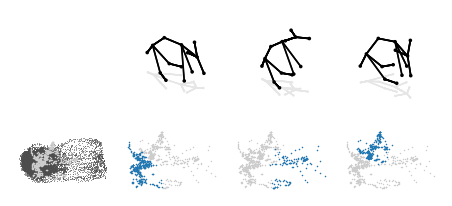

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/eS-example-low-clust.pdf')

In [987]:
session = "72wk_m3"
measure = _spheres[session][1][:, back_ix].mean(axis = 1) # bone lengths
selected = measure.argsort()[:nframes]
X = canonicalized.get_session(session)[selected].reshape(-1, arms.n_kpts * 3)
shared_pc_10 = PCA(n_components=10).fit(canonicalized._data.reshape(-1, arms.n_kpts * 3))
X_pc = shared_pc_10.transform(X)
ncl=3
clust = KMeans(n_clusters=ncl, random_state=0).fit_predict(X_pc)

fig = plt.figure(figsize = (0.75 * ncl + 0.75, 1.5), dpi=150)
row0 = [fig.add_subplot(2, ncl+1, i+2, projection='3d') for i in range(ncl)]
row1 = [fig.add_subplot(2, ncl+1, i+3+ncl) for i in range(ncl)]
clord = [0, 1, 2,]
for i, ic in enumerate(clord):
    row1[i].scatter(*X_pc[:, [0, 1]].T, s=0.5, lw=0, c='.8')
    row1[i].scatter(*X_pc[clust == ic][:, [0, 1]].T, s=0.5, lw=0)
    row1[i].set_aspect('equal')
    center = shared_pc_10.inverse_transform(X_pc[clust == ic].mean(axis = 0)[None]).reshape(-1, 3)
    plotdrop(center, row0[i], 'k', 0.2, 0.5, True, shady=False, shadx=False, arms=arms)
    row1[i].set_axis_off()

Xall = shared_pc_10.transform(canonicalized.get_session(session).reshape(-1, arms.n_kpts * 3))
ax = fig.add_subplot(2, ncl+1, ncl+2)
ax.scatter(*Xall[:, [0, 1]].T, s=0.1, lw=0, c='.3', rasterized=True)
ax.scatter(*X_pc[:, [0, 1]].T, s=0.5, lw=0, c = '.8')
ax.set_aspect('equal')
ax.set_axis_off()

plotter.finalize(fig, "eS-example-low-clust", despine=False)

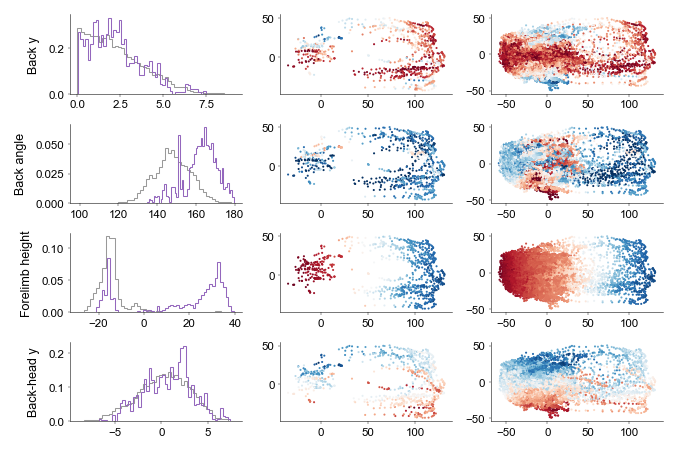

In [35]:
back_ix = arms.keypoint_names.inverse['back']
back_y = abs(canonicalized.get_session(session)[:, back_ix, 1])
back_ix = joint_names.index('Hi-lo back')
back_gl = _joint_angles(canonicalized.get_session(session), joint_kp_ixs)[:, back_ix]
Xall_pc = shared_pc_10.transform(canonicalized.get_session(session).reshape(-1, arms.n_kpts * 3))
flimb_ix = [arms.keypoint_names.inverse[f"{s}f_foot"] for s in ['l', 'r']]
flimb_ht = canonicalized.get_session(session)[:, flimb_ix, 2].mean(axis = 1)
backhead_ix = [arms.keypoint_names.inverse[i] for i in ['head', 'back']]
backhead_y = np.diff(canonicalized.get_session(session)[:, backhead_ix, 1], axis = 1)[:, 0]

fig, ax = plt.subplots(4, 3, figsize = (4.5, 3), dpi=150)

ax[0, 0].hist(back_y, bins=50, color='.6', lw=0.5, density=True, histtype='step')
ax[0, 0].hist(back_y[selected], bins=50, color='C4', lw=0.5, density=True, histtype='step')
ax[0, 1].scatter(*X_pc[:, [0, 1]].T, c = back_y[selected], cmap = 'RdBu', s=1, lw=0)
ax[0, 2].scatter(*Xall_pc[:, [0, 1]].T, c = back_y, cmap = 'RdBu', s=1, lw=0)
ax[0, 0].set_ylabel("Back y")

ax[1, 0].hist(back_gl, bins=50, color='.6', lw=0.5, density=True, histtype='step')
ax[1, 0].hist(back_gl[selected], bins=50, color='C4', lw=0.5, density=True, histtype='step')
ax[1, 1].scatter(*X_pc[:, [0, 1]].T, c = back_gl[selected], cmap = 'RdBu', s=1, lw=0, vmin = 125, vmax = 170)
ax[1, 2].scatter(*Xall_pc[:, [0, 1]].T, c = back_gl, cmap = 'RdBu', s=1, lw=0, vmin = 125, vmax = 170)
ax[1, 0].set_ylabel("Back angle")

ax[2, 0].hist(flimb_ht, bins=50, color='.6', lw=0.5, density=True, histtype='step')
ax[2, 0].hist(flimb_ht[selected], bins=50, color='C4', lw=0.5, density=True, histtype='step')
ax[2, 1].scatter(*X_pc[:, [0, 1]].T, c = flimb_ht[selected], cmap = 'RdBu', s=1, lw=0)
ax[2, 2].scatter(*Xall_pc[:, [0, 1]].T, c = flimb_ht, cmap = 'RdBu', s=1, lw=0)
ax[2, 0].set_ylabel("Forelimb height")

ax[3, 0].hist(backhead_y, bins=50, color='.6', lw=0.5, density=True, histtype='step')
ax[3, 0].hist(backhead_y[selected], bins=50, color='C4', lw=0.5, density=True, histtype='step')
ax[3, 1].scatter(*X_pc[:, [0, 1]].T, c = backhead_y[selected], cmap = 'RdBu', s=1, lw=0)
ax[3, 2].scatter(*Xall_pc[:, [0, 1]].T, c = backhead_y, cmap = 'RdBu', s=1, lw=0)
ax[3, 0].set_ylabel("Back-head y")

plotter.finalize(fig, None)

Text(0, 0.5, 'Forelimb height')

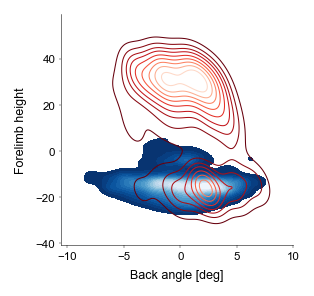

In [36]:
fig, ax = plt.subplots(1, 1, figsize = (2, 2), dpi=150)
# 2d kde plot of back_gl and flimb_ht
sns.kdeplot(x=backhead_y, y=flimb_ht, ax = ax, cmap='Blues_r', fill=True, levels=20)
# non-filled kdeplot plot of backhead_y and flimb_ht with selected frames
sns.kdeplot(x=backhead_y[selected], y=flimb_ht[selected], ax = ax, cmap='Reds_r', fill=False, levels=10, linewidths=0.5)
ax.set_xlabel("Back angle [deg]")
ax.set_ylabel("Forelimb height")

#### Approximate fixed-bone-length morphing

In [37]:
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats, merged_params, rescale=True, _align_meta=align_meta, scale_to=scale_to)
roots_canon, bones_canon, ls_mat = blscale_ls.roots_and_bones({s: canonicalized.get_session(s) for s in dataset_feats.sessions}, arms.bones, arms.keypoint_names.inverse[arms.root])
roots_raw, bones_raw, _ = blscale_ls.roots_and_bones({s: raw.get_session(s) for s in dataset_feats.sessions}, arms.bones, arms.keypoint_names.inverse[arms.root])
bl_ratios = {s: (np.linalg.norm(bones_raw[s], axis = -1) / np.linalg.norm(bones_canon[s], axis = -1)) for s in dataset_feats.sessions}
fixed_bl_ratios = {s: bl_ratios[s].mean(axis = 0) for s in dataset_feats.sessions}

# canonicalized 52week frame, placed back onto 52 week body using "fixed bone
# length" morph
bones_poseind_canon = {s: bones_raw[s] / bl_ratios[s][:, :, None] * fixed_bl_ratios[s][None, :, None] for s in dataset_feats.sessions}
frames_C = {s: blscale_ls.inverse_transform(roots_raw[s], bones_poseind_canon[s], ls_mat) for s in dataset_feats.sessions}

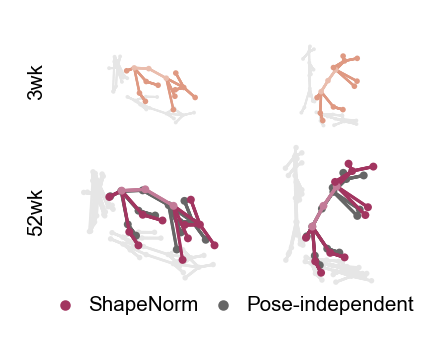

In [47]:
rescale = True
_align_meta= {'scale': np.array(align_meta['scale'])}
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats, merged_params, None, rescale=rescale, scale_to=scale_to, _align_meta=_align_meta, canon_to=scale_to)

ex_sess = f'7wk_m1'
tgt_canon = canonicalized.get_session(ex_sess)
tgt_raw = raw.get_session(ex_sess)

back_ix = [bone_names.index(short_names.inverse[b]) for b in ['lo back', 'hi back']]
tl_canon = _bone_lengths(tgt_canon, arms)[:, back_ix].mean(axis = 1)
tl_raw = _bone_lengths(tgt_raw, arms)[:, back_ix].mean(axis = 1)
tl_ratio = tl_raw / tl_canon
frame_order = np.argsort(tl_ratio)
n_display=2
display = [20, -15]



gs_r0 = plt.GridSpec(2, 6, height_ratios=[1, 1.5], width_ratios = [0.13, 0.5, 0.1, 0.13, 0.5, 0.1], wspace=0, hspace=0)
gs_r1 = plt.GridSpec(2, 4, height_ratios=[0.5, 1.5], wspace=0, hspace=0)
fig = plt.figure(figsize=(1.7, 1.5), dpi=270)
row0_shad = np.array([fig.add_subplot(gs_r0[0, 3*i+1], projection='3d') for i in range(2)])
row1_shad = np.array([fig.add_subplot(gs_r1[1, 2*i:2*i+2], projection='3d') for i in range(2)])
row0_back = np.array([fig.add_subplot(gs_r0[0, 3*i+1], projection='3d') for i in range(2)])
row1_back = np.array([fig.add_subplot(gs_r1[1, 2*i:2*i+2], projection='3d') for i in range(2)])
row1_frnt = np.array([fig.add_subplot(gs_r1[1, 2*i:2*i+2], projection='3d') for i in range(2)])

for i in range(2):
    for tgt in [row0_shad, row1_shad, row1_back, row1_frnt]:
        tgt[i].sharex(row0_back[i])
        tgt[i].sharey(row0_back[i])
        tgt[i].sharez(row0_back[i])

back_clr = lambda c, d: [mpl_col.to_rgba(c) if arms.keypoint_names[i] not in ['hips', 'back', 'shldr'] else d for i in range(arms.n_kpts)]
for i in range(2):
    over = dict(colors=back_clr(ref_color, viz.util.lighten(ref_color, 0.35)))
    plotdrop(canonicalized.get_session(ex_sess)[frame_order[display[i]]], row0_back[i], ref_color, 0.15, 0.3, True, shady=False, dropax=row0_shad[i], arms=arms, override=over)
    over = dict(colors=back_clr(tgt_color, viz.util.lighten(tgt_color, 0.35)))
    plotdrop(raw.get_session(ex_sess)[frame_order[display[i]]], row1_frnt[i], tgt_color, 0.3, 0.5, True, shady=False, arms=arms, dropax = row1_shad[i], override=over)
    plotdrop(frames_C[ex_sess][frame_order[display[i]]], row1_back[i], mpl_col.to_rgba('.4'), 0.3, 0.5, True, shady=False, arms=arms, dropax = row1_shad[i])

    # plotdrop(anchors_scaled[ref_body, i], row0_back[i], ref_color, 0.15, 0.3, True, shady=False, dropax=row0_shad[i], arms=arms)
    # plotdrop(anchors_scaled[tgt_body, i], row1_frnt[i], tgt_color, 0.3, 0.3, True, shady=False, dropax=row1_shad[i], arms=arms)
    # plotdrop(anchors_bl_only[i], row1_back[i], mpl_col.to_rgba('.4'), 0.3, 0.5, True, shady=False, dropax=row1_shad[i], arms=arms)


t = mpl.transforms.blended_transform_factory(fig.transFigure, row0_back[0].transAxes)
row0_back[0].text2D(0.07, 0.55, f"{ref_age}wk", ha = 'center', va = 'center', rotation=90, size=5.5, transform=t)
t = mpl.transforms.blended_transform_factory(fig.transFigure, row1_back[0].transAxes)
row1_back[0].text2D(0.07, 0.55, f"{tgt_age}wk", ha = 'center', va = 'center', rotation=90, size=5.5, transform=t)



legax = fig.add_subplot(335)
legax.set_axis_off()
legax.scatter([np.nan], [np.nan], color=tgt_color, s=4, label = "ShapeNorm")
legax.scatter([np.nan], [np.nan], color='.4', s=4, label = "Pose-independent")
viz.util.legend(legax, loc='center', bbox_to_anchor = (0.4, -0.85), ncol = 2, columnspacing=0.2, handletextpad=0.1)

plotter.finalize(fig, None, tight=False)

In [48]:
_align_meta = {"scale": np.array(align_meta["scale"])}
canonicalized, raw, _ = canonicalized_and_raw(
    dataset_feats_full, merged_params, None, rescale=True, scale_to=scale_to, _align_meta=_align_meta, canon_to=scale_to
)
_, rigid, _ = canonicalized_and_raw(
    dataset_feats_full, merged_params, None, rescale=False, canon_to=scale_to,
)
ages = [ref_age] + tgt_ages
age_groups = {
    a: [ s for s in dataset_feats.sessions if re.search(r"(\d+)wk", s).group(1) == a ]
    for a in ages
}

# skeletal parameterization of canonicalized and raw frames
roots_canon, bones_canon, ls_mat = blscale_ls.roots_and_bones({s: canonicalized.get_session(s) for s in dataset_feats.sessions}, arms.bones, arms.keypoint_names.inverse[arms.root])
roots_raw, bones_raw, _ = blscale_ls.roots_and_bones({s: raw.get_session(s) for s in dataset_feats.sessions}, arms.bones, arms.keypoint_names.inverse[arms.root])
bl_ratios = {s: (np.linalg.norm(bones_canon[s], axis = -1) / np.linalg.norm(bones_raw[s], axis = -1)) for s in dataset_feats.sessions}
fixed_bl_ratios = {s: bl_ratios[s].mean(axis = 0) for s in dataset_feats.sessions}
# 52wk pose scaled by fixed bone length onto "3wk"
# (bl ratios = length(raw) / length(canon))
bones_canon_raw_length = {
    s: bones_canon[s] * np.linalg.norm(bones_raw[s], axis = -1, keepdims=True) / np.linalg.norm(bones_canon[s], axis = -1, keepdims=True)
    for s in dataset_feats.sessions}
bones_poseind_canon = {s: bones_canon_raw_length[s] * fixed_bl_ratios[s][None, :, None] for s in dataset_feats.sessions}
# bones_poseind_canon = {s: bones_canon[s] / (1/bl_ratios[s][:, :, None]) * (1/fixed_bl_ratios[s][None, :, None]) for s in dataset_feats.sessions}
frames_C = {
    s: blscale_ls.inverse_transform(
        roots_canon[s], bones_poseind_canon[s], ls_mat
    )
    for s in dataset_feats.sessions
}


# isolate to rearing frames
frame_mask = {s: bhv_masks["rear"][s] for s in dataset_feats.sessions}

# --- measure JSDs to reference session aross each
jsds = {}
for k, kpts in {
    "raw": {s: raw.get_session(s)[frame_mask[s]] for s in dataset_feats.sessions},
    "canon": {s: canonicalized.get_session(s)[frame_mask[s]] for s in dataset_feats.sessions},
    "rigid": {s: rigid.get_session(s)[frame_mask[s]] for s in dataset_feats.sessions},
    "fixie": {s: frames_C[s][frame_mask[s]] for s in dataset_feats.sessions},
}.items():
    feats = {
        s: features.reduce_to_features(a, cfg["features"])
        for s, a in kpts.items()
    }
    ref_cloud = clouds.PointCloudDensity(k=15).fit(feats[scale_to])
    jsds[k] = np.array(
        [
            clouds.ball_cloud_js(
                ref_cloud, clouds.PointCloudDensity(k=15).fit(feats[s])
            )
            for s in dataset_feats.sessions
            if s != scale_to
        ]
    )

(35922, 3) (35922, 3)
(35922, 3) (35922, 3)
(35922, 3) (35922, 3)
(35922, 3) (35922, 3)
(35922, 3) (35922, 3)
(35922, 3) (35922, 3)
(35922, 3) (35922, 3)
(35922, 3) (35922, 3)
(35922, 3) (35922, 3)
(35922, 3) (35922, 3)
(35922, 3) (35922, 3)
(35922, 3) (35922, 3)
(35922, 3) (35922, 3)


Text(0.5, 0, 'Dynamic / fixed ratio\ncolor=bone')

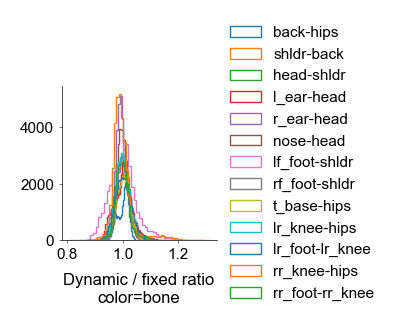

In [49]:
fig, ax = plt.subplots(figsize = (1, 1), dpi = 200)
for i in range(len(bone_names)):
    print(bones_canon[ex_sess][:, i].shape, bones_poseind_canon[ex_sess][:, i].shape)
    plt.hist(
        np.linalg.norm(bones_canon[ex_sess][:, i], axis = -1) / np.linalg.norm(bones_poseind_canon[ex_sess][:, i], axis = -1),
        bins=50,
        histtype='step',
        lw = 0.5,
        label = bone_names[i]
    )
viz.util.legend(ax)
ax.set_xlabel("Dynamic / fixed ratio\ncolor=bone")

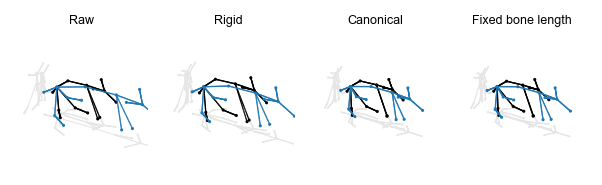

In [50]:
fig, ax = plt.subplots(1, 4, figsize=(4, 1.5), dpi=150, subplot_kw=dict(projection='3d'))
for a in ax:
    a.sharex(ax[-1])
    a.sharey(ax[-1])
    a.sharez(ax[-1])


frame = 0
plotdrop(frames_C[ex_sess][frame], ax[3], 'k', 0.15, 0.3, True, shady=False, arms=arms)
ax[3].set_title("Fixed bone length")
plotdrop(raw.get_session(ex_sess)[frame], ax[0], 'k', 0.15, 0.3, True, shady=False, arms=arms)
ax[0].set_title("Raw")
plotdrop(rigid.get_session(ex_sess)[frame], ax[1], 'k', 0.15, 0.3, True, shady=False, arms=arms)
ax[1].set_title("Rigid")
plotdrop(canonicalized.get_session(ex_sess)[frame], ax[2], 'k', 0.15, 0.3, True, shady=False, arms=arms)
ax[2].set_title("Canonical")

frame = 10
plotdrop(frames_C['52wk_m0'][frame], ax[3], 'C0', 0.15, 0.3, True, shady=False, arms=arms)
ax[3].set_title("Fixed bone length")
plotdrop(raw.get_session('52wk_m0')[frame], ax[0], 'C0', 0.15, 0.3, True, shady=False, arms=arms)
ax[0].set_title("Raw")
plotdrop(rigid.get_session('52wk_m0')[frame], ax[1], 'C0', 0.15, 0.3, True, shady=False, arms=arms)
ax[1].set_title("Rigid")
plotdrop(canonicalized.get_session('52wk_m0')[frame], ax[2], 'C0', 0.15, 0.3, True, shady=False, arms=arms)
ax[2].set_title("Canonical")


plotter.finalize(fig, None)

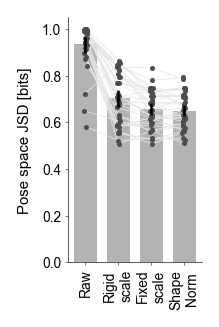

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/f-posespace-jsd-progression.pdf')

In [51]:
fig, ax = plt.subplots(figsize = (1.2, 1.8), dpi=180)

viz.util.grouped_stripplot(
    [jsds['raw'], jsds['rigid'], jsds['fixie'], jsds['canon']],
    x = [0, 1, 2, 3],
    colors = mpl_col.to_rgba('k'),
    points_kw={'ms': 1},
    lighten_points=0.3,
    errorbar_kw=dict(ms=0),
    error = lambda a, **kw: viz.util.ci(a, level=0.95, n=1000),
    connect=True,
    connection_kw = dict(lw=0.3, color='.9', ls='-'),
)
ax.bar([0], color = '.7', width=0.7, **viz.util.stem_bar(np.mean(jsds['raw']), 0),)
ax.bar([1], color = '.7', width=0.7, **viz.util.stem_bar(np.mean(jsds['rigid']), 0),)
ax.bar([2], color = '.7', width=0.7, **viz.util.stem_bar(np.mean(jsds['fixie']), 0),)
ax.bar([3], color = '.7', width=0.7, **viz.util.stem_bar(np.mean(jsds['canon']), 0),)

ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(["Raw", "Rigid\nscale", "Fixed\nscale", "Shape\nNorm"], rotation=90)
ax.set_ylabel("Pose space JSD [bits]")

plotter.finalize(fig, 'f-posespace-jsd-progression', despine=False)

#### Fixed-BL morphing II

Done more carefuly: still see basically no effect

In [94]:
def calc_dynamic_ratios(frames_A, frames_B):
    """|bones_B| / |bones_A|"""
    roots, bones, ls_mat = blscale_ls.roots_and_bones(
        {"A": frames_A, "B": frames_B},
        arms.bones,
        arms.keypoint_names.inverse[arms.root],
    )
    return np.linalg.norm(bones["B"], axis=-1) / np.linalg.norm(bones["A"], axis=-1)


def remove_dynamic_length_component(frames_A, frames_B, fixed_ratios):
    """
    Parameters
    ----------
    frames_A, frames_B : np.ndarray
        Frames to remove the dynamic length component from.
    fixed_ratios : np.ndarray, shape (n_frames, n_bones)
        Ratios |target_C| / |bones_A|.
        
    Returns
    -------
    frames_C : np.ndarray
        Frames with angles of frames_B and lengths of frames_A times fixed_ratios."""
    
    # result has:
    # - angles of frames_B
    # - lengths of frames_A times fixed_ratios
    # => bones_C = bones_B * |bones_A| / |bones_B| * fixed_ratios

    roots, bones, ls_mat = blscale_ls.roots_and_bones(
        {"A": frames_A, "B": frames_B},
        arms.bones,
        arms.keypoint_names.inverse[arms.root],
    )
    dynamic_rto = np.linalg.norm(bones["A"], axis=-1) / np.linalg.norm(bones["B"], axis=-1)
    bones_C = bones["B"] * dynamic_rto[:, :, None] * fixed_ratios[:, :, None]
    return blscale_ls.inverse_transform(roots["B"], bones_C, ls_mat)


In [97]:
ex_sess = "52wk_m0"
frame = 700
_align_meta = {"scale": np.array(align_meta["scale"])}
canonicalized, raw, _ret_align_meta = canonicalized_and_raw(dataset_feats, merged_params, None, rescale=True, scale_to=scale_to, canon_to=scale_to, _align_meta=_align_meta)


# no bone scaling
# rtos = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])[None]
# rigid bone scaling
# rtos = 0.5 * np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])[None]
# dynamic bone scaling
# rtos = calc_dynamic_ratios(raw.get_session(ex_sess), canonicalized.get_session(ex_sess),)
# fixed bone scaling
rtos = calc_dynamic_ratios(raw.get_session(ex_sess), canonicalized.get_session(ex_sess),).mean(axis=0)[None]

frames_C = remove_dynamic_length_component(
    raw.get_session(ex_sess),
    canonicalized.get_session(ex_sess),
    rtos
)



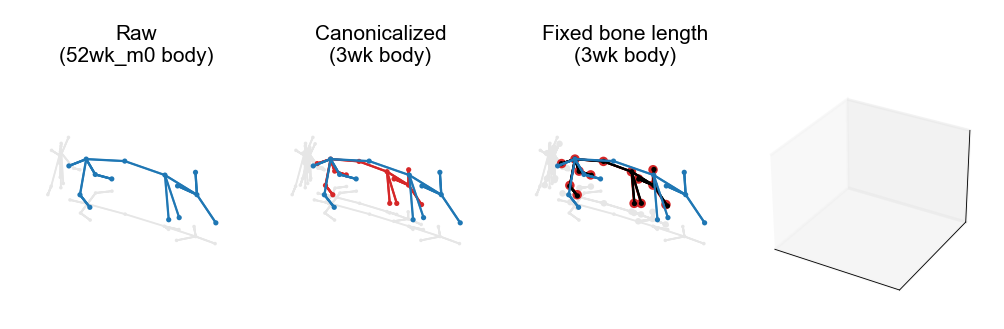

In [100]:
fig, ax = plt.subplots(1, 4, figsize=(4, 1.5), dpi=250, subplot_kw=dict(projection='3d'))
for a in ax:
    a.sharex(ax[-1])
    a.sharey(ax[-1])
    a.sharez(ax[-1])


frame = 0

plotdrop(canonicalized.get_session(ex_sess)[frame], ax[1], 'C3', 0.15, 0.3, True, shady=False, arms=arms)
ax[1].set_title("Canonicalized\n(3wk body)")
# overlays of canon
plotdrop(canonicalized.get_session(ex_sess)[frame], ax[2], 'C3', 0.5, 0.3, True, shady=False, arms=arms)

plotdrop(raw.get_session(ex_sess)[frame], ax[0], 'C0', 0.15, 0.3, True, shady=False, arms=arms)
ax[0].set_title(f"Raw\n({ex_sess} body)")
# overlays of raw
plotdrop(raw.get_session(ex_sess)[frame], ax[1], 'C0', 0.15, 0.3, True, shady=False, arms=arms)
plotdrop(raw.get_session(ex_sess)[frame], ax[2], 'C0', 0.15, 0.3, True, shady=False, arms=arms)


plotdrop(frames_C[frame], ax[2], 'k', 0.15, 0.3, True, shady=False, arms=arms)
ax[2].set_title("Fixed bone length\n(3wk body)")

plotter.finalize(fig, None)

In [114]:
_align_meta = {"scale": np.array(align_meta["scale"])}
canonicalized, raw, _ = canonicalized_and_raw(
    dataset_feats_full, merged_params, None, rescale=True, scale_to=scale_to, _align_meta=_align_meta, canon_to=scale_to
)
_, rigid, _ = canonicalized_and_raw(
    dataset_feats_full, merged_params, None, rescale=False, canon_to=scale_to,
)
frames_C = {
    s: remove_dynamic_length_component(
        raw.get_session(s),
        canonicalized.get_session(s),
        calc_dynamic_ratios(raw.get_session(s), canonicalized.get_session(s),).mean(axis=0)[None]
    )
    for s in dataset_feats.sessions
}


# isolate to rearing frames
# frame_mask = {s: bhv_masks["rear"][s] for s in dataset_feats.sessions}

# --- measure JSDs to reference session aross each
jsds = {}
for k, kpts in {
    "raw": {s: raw.get_session(s)[::5] for s in dataset_feats.sessions},
    "canon": {s: canonicalized.get_session(s)[::5] for s in dataset_feats.sessions},
    "rigid": {s: rigid.get_session(s)[::5] for s in dataset_feats.sessions},
    "fixie": {s: frames_C[s][::5] for s in dataset_feats.sessions},
}.items():
    feats = {
        s: features.reduce_to_features(a, cfg["features"])
        for s, a in kpts.items()
    }
    ref_cloud = clouds.PointCloudDensity(k=15).fit(feats[scale_to])
    jsds[k] = np.array(
        [
            clouds.ball_cloud_js(
                ref_cloud, clouds.PointCloudDensity(k=15).fit(feats[s])
            )
            for s in dataset_feats.sessions
            if s != scale_to
        ]
    )

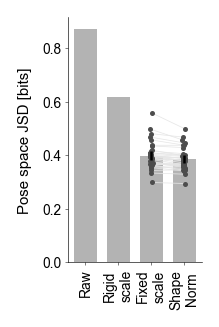

In [115]:
fig, ax = plt.subplots(figsize = (1.2, 1.8), dpi=180)

viz.util.grouped_stripplot(
    [jsds['fixie'], jsds['canon']],
    x = [2, 3],
    colors = mpl_col.to_rgba('k'),
    points_kw={'ms': 1},
    lighten_points=0.3,
    errorbar_kw=dict(ms=0),
    error = lambda a, **kw: viz.util.ci(a, level=0.95, n=1000),
    connect=True,
    connection_kw = dict(lw=0.3, color='.9', ls='-'),
)
ax.bar([0], color = '.7', width=0.7, **viz.util.stem_bar(np.mean(jsds['raw']), 0),)
ax.bar([1], color = '.7', width=0.7, **viz.util.stem_bar(np.mean(jsds['rigid']), 0),)
ax.bar([2], color = '.7', width=0.7, **viz.util.stem_bar(np.mean(jsds['fixie']), 0),)
ax.bar([3], color = '.7', width=0.7, **viz.util.stem_bar(np.mean(jsds['canon']), 0),)

ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(["Raw", "Rigid\nscale", "Fixed\nscale", "Shape\nNorm"], rotation=90)
ax.set_ylabel("Pose space JSD [bits]")

plotter.finalize(fig, None, despine=False)

### i. Rearing component

17.799999999999997 0.052488745250272605


/Users/kaifox/projects/mph/generative_api/shape_norm/viz/_style.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


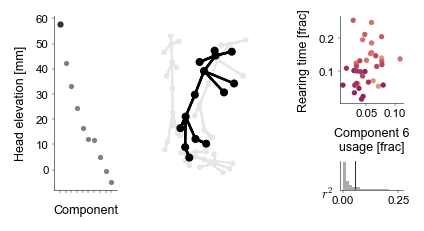

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/g-rearing-example.pdf')

In [683]:
head_ix = arms.keypoint_names.inverse['head']
means = features.inflate(params.pose.means, cfg['features'])
heat_ht = means[:, head_ix, 2]
head_ord = np.argsort(heat_ht)[::-1]
ord_num = 0
rear_usages = {s: bhv_masks['rear'][s].mean() for s in dataset.sessions}


fig = plt.figure(figsize = (3, 1.5), dpi=150)
gs = plt.GridSpec(2, 4, width_ratios = [1, 3, 1, 1], wspace=-0.1, hspace = 1, height_ratios = [3, 1])
ax = fig.add_subplot(gs[:, 0])
ax.plot([ord_num], heat_ht[head_ord[ord_num]], 'o', mfc = '.2', mew = 0, ms = 3.)
ax.plot(np.arange(1, params.pose.n_components), heat_ht[head_ord[1:]], 'o', mfc = '.5', mew = 0, ms = 2.5)
ax.set_xticks(np.arange(params.pose.n_components))
ax.set_xticklabels([""] * params.pose.n_components)
ax.set_ylabel("Head elevation [mm]")
ax.set_xlabel("Component")
ax.set_xlim(-1, params.pose.n_components - 1 + 1)

ax = fig.add_subplot(gs[:, 1], projection = '3d')
plotdrop(means[head_ord[ord_num]], ax, 'k', arms=arms)
# ax.set_title(f"Component {head_ord[ord_num]}")



ax = fig.add_subplot(gs[0, 3])
corr_x = [
    (params.pose.subj_weights[dataset.session_id(s), head_ord[ord_num]]
    )
    for s in dataset.sessions
]
corr_y = [
    rear_usages[s]
    for s in dataset.sessions
]
age_clr = [age_pal[re.search(r"(\d+)wk", s).group(1)] for s in dataset.sessions]
ax.scatter(corr_x, corr_y, c = age_clr, s = 3)
# vmin = min(ax.get_xlim()[0], ax.get_ylim()[0])
# vmax = max(ax.get_xlim()[1], ax.get_ylim()[1])
# vmin, vmax = vmin - 0.05 * (vmax - vmin), vmax + 0.05 * (vmax - vmin)
# ax.set_xlim(vmin, vmax)
# ax.set_ylim(vmin, vmax)
# ax.plot([vmin, vmax], [vmin, vmax], 'k--', lw = 0.3)
# ax.set_xticks([0.0, 0.2])
# ax.set_yticks([0.0, 0.2])
# ax.set_aspect(1.)
ax.set_xlabel(f"Component {head_ord[ord_num]}\nusage [frac]")
ax.set_ylabel("Rearing time [frac]")

ax = fig.add_subplot(gs[1, 3])
corr = lambda x, y: np.corrcoef(x, y)[0, 1] ** 2
r = corr(corr_x, corr_y)
ax.axvline(r, color = '.2', lw = 0.5)
rng = np.random.default_rng(623)
shuf = [corr(rng.permutation(corr_x), corr_y) for _ in range(1000)]
ax.hist(shuf, bins = 20, color = '.67', density = True)
print(100-stats.percentileofscore(shuf,r ), r)
ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.text(-0.1, 0.1, f"$r^2$", math_fontfamily = 'cm', ha = 'right', va = 'top', fontsize = 6, transform = ax.transAxes)



plotter.finalize(fig, 'g-rearing-example')


#### high rears only

In [909]:
def intervals_to_signal(n, intervals):
    y = np.zeros(n).astype(bool)
    for s, e in intervals:
        y[s:e] = True
    return y

In [942]:
raw_full, _ = unalign_scales(_align_meta, dataset_versions_full['aligned'], None, None)
elevation = lambda arr: (np.arccos(np.clip(cos(arr, arr * np.array([1, 1, 0])[None], axis = -1), -1, 1)) * np.sign(arr[:, 2])) * 180 / np.pi
# head_ix = [arms.keypoint_names.inverse['lf_foot'], arms.keypoint_names.inverse['rf_foot']] 
head_ix = [arms.keypoint_names.inverse['head']]
head_elev = {s: elevation(raw_full.get_session(s)[:, head_ix].mean(axis = -2)) for s in dataset_feats_full.sessions}
session_lengths = {s: len(head_elev[s]) for s in dataset_feats_full.sessions}
rear_heights = {
    s: [head_elev[s][a: b].max() for (a, b) in sup_bhv['intervals']['angle_reer'][s]]
    for s in dataset_feats.sessions
}
high_rear_intervals = {
    s: [(a, b) for (a, b) in sup_bhv['intervals']['angle_reer'][s] if head_elev[s][a: b].max() < 66]
    for s in dataset_feats.sessions
}
high_rear_masks = {
    s: intervals_to_signal(session_lengths[s], high_rear_intervals[s])
    for s in dataset_feats.sessions
}
high_rear_time = {
    s: sum([(head_elev[s][a: b].max() > 66).sum() for (a, b) in sup_bhv['intervals']['angle_reer'][s]]) / session_lengths[s]
    for s in dataset_feats.sessions
}

(35910, 3) (35910, 3)
0.9567046
0.9567046


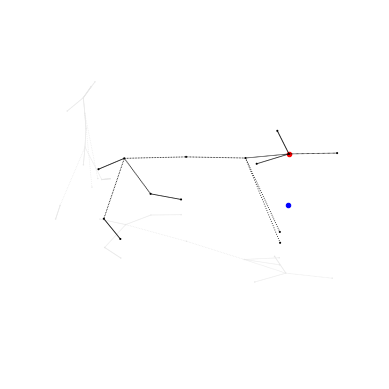

In [891]:
fig = plt.figure()
cos = lambda a, b, **k: (a * b).sum(**k) / jnp.sqrt((a * a).sum(**k) * (b * b).sum(**k))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(30, -45)
_keypts = raw_full.get_session('52wk_m0')
arr = _keypts[:, head_ix]
frame = 20
arr_flat = arr * np.array([1, 1, 0])[None]
plotdrop(_keypts[frame], ax, 'k', 0.15, 0.3, True, shady=False, arms=arms)
ax.scatter(*arr[frame].T, c = 'r', s = 10)
ax.scatter(*arr_flat[frame].T, c = 'b', s = 10)
print(arr.shape, arr_flat.shape)
print(cos(arr[frame], arr_flat[frame]))
print(cos(arr, arr_flat, axis = -1)[frame])

66.1167844110462


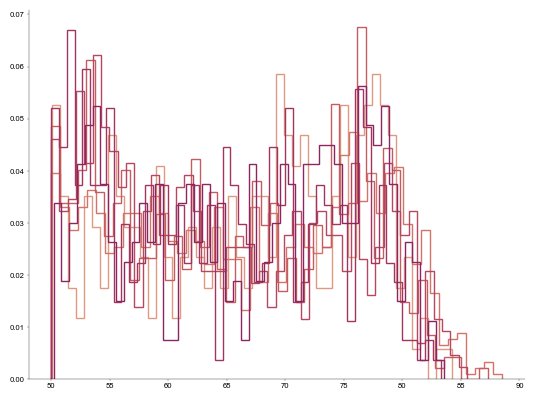

In [936]:
for a in age_groups:
    plt.hist(np.concatenate([rear_heights[s] for s in age_groups[a]]), bins=50, color = age_pal[a], histtype='step', lw=1, density=True)
print(np.median(np.concatenate([rear_heights[s] for s in dataset_feats.sessions])))

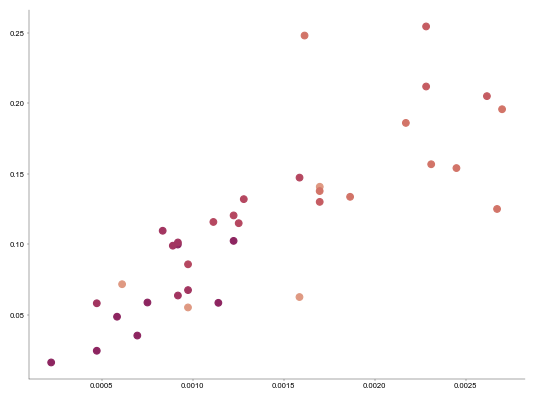

In [944]:
# x = {s: high_rear_masks[s].mean() for s in dataset.sessions}
x = high_rear_time
y = {s: bhv_masks['rear'][s].mean() for s in dataset.sessions}
plt.scatter([x[s] for s in dataset.sessions], [y[s] for s in dataset.sessions], c = [age_pal[re.search(r"(\d+)wk", s).group(1)] for s in dataset.sessions])
# plt.gca().set_aspect(1)

16.89999999999999 0.05158071310328069


/Users/kaifox/projects/mph/generative_api/shape_norm/viz/_style.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


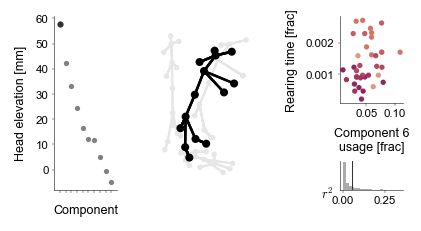

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/g-rearing-example.pdf')

In [945]:
head_ix = arms.keypoint_names.inverse['head']
means = features.inflate(params.pose.means, cfg['features'])
heat_ht = means[:, head_ix, 2]
head_ord = np.argsort(heat_ht)[::-1]
ord_num = 0
# rear_usages = {s: high_rear_masks[s].mean() for s in dataset.sessions}
rear_usages = {s: high_rear_time[s] for s in dataset.sessions}


fig = plt.figure(figsize = (3, 1.5), dpi=150)
gs = plt.GridSpec(2, 4, width_ratios = [1, 3, 1, 1], wspace=-0.1, hspace = 1, height_ratios = [3, 1])
ax = fig.add_subplot(gs[:, 0])
ax.plot([ord_num], heat_ht[head_ord[ord_num]], 'o', mfc = '.2', mew = 0, ms = 3.)
ax.plot(np.arange(1, params.pose.n_components), heat_ht[head_ord[1:]], 'o', mfc = '.5', mew = 0, ms = 2.5)
ax.set_xticks(np.arange(params.pose.n_components))
ax.set_xticklabels([""] * params.pose.n_components)
ax.set_ylabel("Head elevation [mm]")
ax.set_xlabel("Component")
ax.set_xlim(-1, params.pose.n_components - 1 + 1)

ax = fig.add_subplot(gs[:, 1], projection = '3d')
plotdrop(means[head_ord[ord_num]], ax, 'k', arms=arms)
# ax.set_title(f"Component {head_ord[ord_num]}")



ax = fig.add_subplot(gs[0, 3])
corr_x = [
    (params.pose.subj_weights[dataset.session_id(s), head_ord[ord_num]]
    )
    for s in dataset.sessions
]
corr_y = [
    rear_usages[s]
    for s in dataset.sessions
]
age_clr = [age_pal[re.search(r"(\d+)wk", s).group(1)] for s in dataset.sessions]
ax.scatter(corr_x, corr_y, c = age_clr, s = 3)
# vmin = min(ax.get_xlim()[0], ax.get_ylim()[0])
# vmax = max(ax.get_xlim()[1], ax.get_ylim()[1])
# vmin, vmax = vmin - 0.05 * (vmax - vmin), vmax + 0.05 * (vmax - vmin)
# ax.set_xlim(vmin, vmax)
# ax.set_ylim(vmin, vmax)
# ax.plot([vmin, vmax], [vmin, vmax], 'k--', lw = 0.3)
# ax.set_xticks([0.0, 0.2])
# ax.set_yticks([0.0, 0.2])
# ax.set_aspect(1.)
ax.set_xlabel(f"Component {head_ord[ord_num]}\nusage [frac]")
ax.set_ylabel("Rearing time [frac]")

ax = fig.add_subplot(gs[1, 3])
corr = lambda x, y: np.corrcoef(x, y)[0, 1] ** 2
r = corr(corr_x, corr_y)
ax.axvline(r, color = '.2', lw = 0.5)
rng = np.random.default_rng(623)
shuf = [corr(rng.permutation(corr_x), corr_y) for _ in range(1000)]
ax.hist(shuf, bins = 20, color = '.67', density = True)
print(100-stats.percentileofscore(shuf,r ), r)
ax.set_yticks([])
ax.spines['left'].set_visible(False)
ax.text(-0.1, 0.1, f"$r^2$", math_fontfamily = 'cm', ha = 'right', va = 'top', fontsize = 6, transform = ax.transAxes)



plotter.finalize(fig, 'g-rearing-example')


### i, j. Behavior classifiaction by components

#### All component usages as during bouts

In [14]:
def compute_bhv_example_dataframes(logprobs, intervals, res, buffer, temp = 1., probs_are_log=True):
    
    bhvs = list(intervals.keys())
    sessions = list(logprobs.keys())
    n_components = logprobs[sessions[0]].shape[1]
    examples = {k: {"x": [], 'on': [], 'n': [], 's': [], 'i': [], **{j: [] for j in range(n_components)}} for k in bhvs}
    n = 0
    for k in bhvs:
        for s in sessions:
            if probs_are_log:
                probs = np.exp(logprobs[s] * temp)
                probs /= probs.sum(axis = 1, keepdims = True)
            else:
                probs = logprobs[s]
            slices = intervals[k][s]
            animal_n = 0
            for start, end in slices:
                if start - buffer < 0 or end + buffer >= len(probs):
                    continue
                example = probs[start - buffer:end + buffer]
                x = np.concatenate([np.arange(-buffer, 0), np.linspace(0, res, end - start), np.arange(res + 1, res + buffer + 1)])
                bout_on = np.concatenate([np.zeros(buffer), np.ones(end - start), np.zeros(buffer)]).astype(bool)
                examples[k]['x'].extend(x.tolist())
                examples[k]['on'].extend(bout_on.tolist())
                for j in range(n_components):
                    examples[k][j].extend(example[:, j].tolist())
                examples[k]['n'].extend([n] * len(x))
                examples[k]['s'].extend([s] * len(x))
                examples[k]['i'].extend([animal_n] * len(x))
                n += 1
                animal_n += 1/len(slices)
        examples[k] = pd.DataFrame(examples[k])
    return examples


In [15]:
canonicalized_full, _, _ = canonicalized_and_raw(dataset_feats_full, merged_params, rescale=False, scale_to=scale_to, canon_to=scale_to)
pose_logprobs = pose.gmm.pose_logprob(params.pose, features.reduce_to_features(canonicalized_full, cfg['features']))
pose_logprobs = {s: pose_logprobs[slice(*dataset_feats_full.get_slice(s))] for s in dataset_feats.sessions}

sup_bhv_intervals = {
    k: {
        s: sup_bhv["intervals"][bhv_keys[k]][s]
        for s in dataset_feats.sessions
    }
    for k in bhv_order
}
invtemp = 0.2
pose_temp_probs = {
    s: np.exp(pose_logprobs[s] * invtemp) / np.exp(pose_logprobs[s] * invtemp).sum(axis = 1, keepdims = True)
    for s in dataset_feats.sessions
}
examples = compute_bhv_example_dataframes(
    pose_temp_probs, sup_bhv_intervals, 40, 10, probs_are_log=False
)

canonicalizedin to: body-3wk_m0


100%|██████████| 45/45 [00:04<00:00, 10.53it/s]


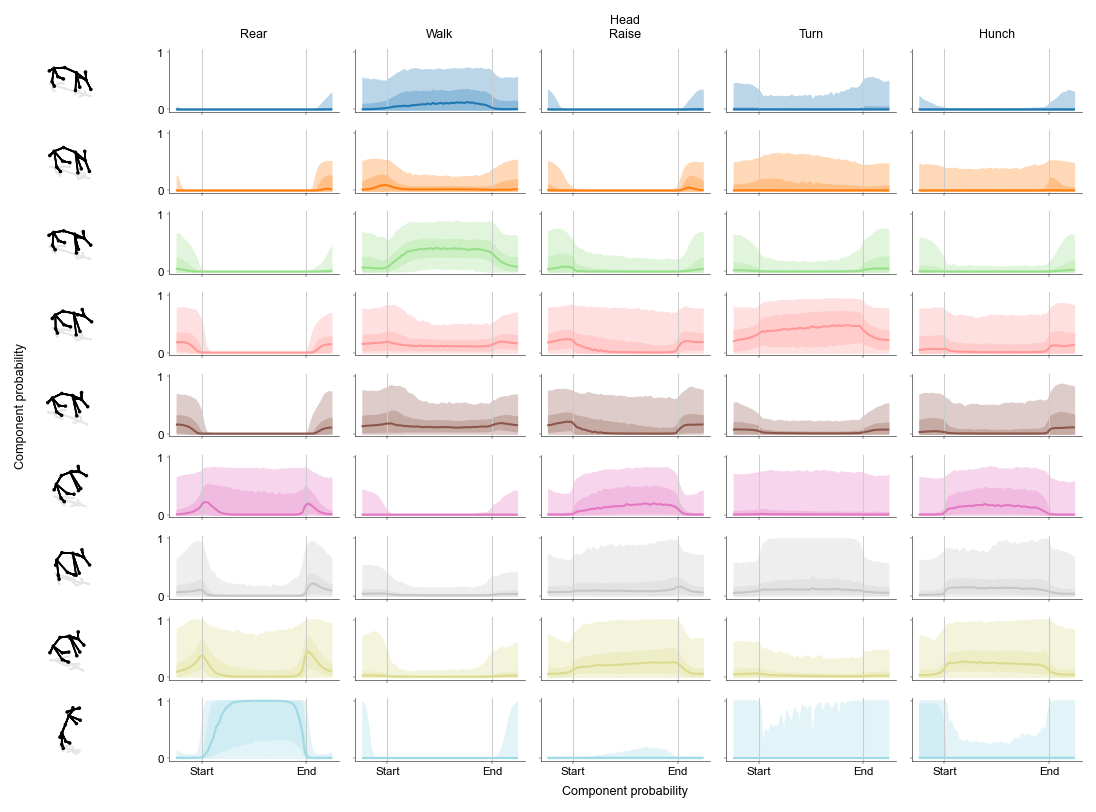

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/iS-all-trajs.pdf')

In [675]:
use_components = [0, 9, 7, 1, 3, 4, 5, 8, 6]
n_components = len(use_components)
n_etho = len(bhv_order)
res, buffer = 40, 10
comp_pal = Colormap('tab20')(np.linspace(0, 1, n_components))
fig, axes = plt.subplots(n_components, n_etho + 1, figsize = (1.5 * n_etho, 0.6 * n_components), dpi = 150, sharex=True)
for ax in axes[:, 0]:
    ax.set_visible(False)

col0 = [fig.add_subplot(n_components, n_etho + 1, 1+i*(n_etho + 1), projection='3d') for i in range(n_components)]
for i, (c, ax) in enumerate(zip(use_components, col0)):
    mean = params.pose.means[c]
    mean = features.inflate(mean[None], cfg['features'])[0]
    plotdrop(mean, ax, 'k', 0.2, 0.5, arms = arms, shady=False, shadx=False)


ax = axes[:, 1:]
bins = np.linspace(-buffer - 1e-2, res + buffer + 1e-2, res + 2 * buffer + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2
with tqdm.tqdm(total = len(bhv_order) * n_components) as pbar:
    for i, k in enumerate(bhv_order):
        for j, c in enumerate(use_components):
            # for _, df in examples[k].query("n % 20 == 0").groupby('n'):
            #     ax[j, i].plot(df['x'], df[j], color = viz.util.lighten(comp_pal[j], 0.5), lw = 0.1)
            y, lo, hi, lo50, hi50 = np.zeros([5, len(bin_centers)])
            for l, (x1, x2) in enumerate(zip(bins[:-1], bins[1:])):
                d = examples[k].query("x > @x1 and x <= @x2")[c]
                # y[l] = d.mean()
                # ci = viz.util.ci(d.values, level=0.95, n=1000, absolute=True)
                lo[l], hi[l] = np.nanquantile(d.values, [0.025, 0.975])
                lo50[l], hi50[l] = np.nanquantile(d.values, [0.25, 0.75])
                y[l] = np.nanmedian(d.values)
                # lo[l] = ci[0]
                # hi[l] = ci[1]
            
            ax[j, i].plot(bin_centers, y, color = comp_pal[j], lw = 1)
            ax[j, i].fill_between(bin_centers, lo, hi, color = viz.util.lighten(comp_pal[j], 0.7), zorder = -3)
            ax[j, i].fill_between(bin_centers, lo50, hi50, color = viz.util.lighten(comp_pal[j], 0.5), zorder = -2)
            ax[j, i].axvline(0, color = '.8', lw = 0.5, zorder = 1)
            ax[j, i].axvline(res, color = '.8', lw = 0.5, zorder = 1)
            ax[j, i].set_ylim(-0.05, 1.05)
            ax[j, i].set_yticks([0, 1])
            ax[j, i].set_yticklabels(["", ""])
            pbar.update()
        ax[0, i].set_title(bhv_names[k])
        ax[-1, i].set_xticks([0, res])
        ax[-1, i].set_xticklabels(["Start", "End"])


for a in ax[:, 0]:
    a.set_yticklabels(["0", "1"])
ax[-1, 2].set_xlabel("Component probability")
fig.tight_layout()

col0[4].text2D(-0.25, 0.5, "Component probability", ha = 'center', va = 'center', rotation = 90, transform = col0[4].transAxes)
plotter.finalize(fig, 'iS-all-trajs', tight=False)

100%|██████████| 6/6 [00:00<00:00, 10.55it/s]


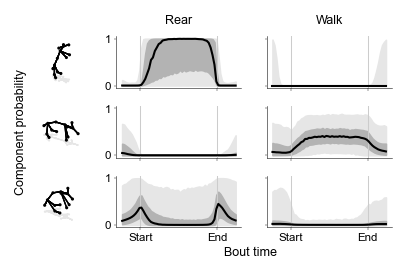

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/i-component-prob-traj.pdf')

In [681]:
use_components = [6, 7, 8]
use_bhv = ['rear', 'loco']
n_components = len(use_components)
n_etho = len(use_bhv)
res, buffer = 40, 10

fig, axes = plt.subplots(n_components, n_etho + 1, figsize = (1.3 * n_etho, 1.7), dpi = 150, sharex=True,
    width_ratios=[0.5, 1, 1])
for ax in axes[:, 0]:
    ax.set_visible(False)

col0 = [fig.add_subplot(n_components, n_etho + 1, 1+i*(n_etho + 1), projection='3d') for i in range(n_components)]
for i, (c, ax) in enumerate(zip(use_components, col0)):
    mean = params.pose.means[c]
    mean = features.inflate(mean[None], cfg['features'])[0]
    plotdrop(mean, ax, 'k', 0.15, 0.3, arms = arms, shady=False, shadx=False)


ax = axes[:, 1:]
bins = np.linspace(-buffer - 1e-2, res + buffer + 1e-2, res + 2 * buffer + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2
with tqdm.tqdm(total = len(use_bhv) * n_components) as pbar:
    for i, k in enumerate(use_bhv):
        for j, c in enumerate(use_components):
            # for _, df in examples[k].query("n % 20 == 0").groupby('n'):
            #     ax[j, i].plot(df['x'], df[j], color = viz.util.lighten(comp_pal[j], 0.5), lw = 0.1)
            y, lo, hi, lo50, hi50 = np.zeros([5, len(bin_centers)])
            for l, (x1, x2) in enumerate(zip(bins[:-1], bins[1:])):
                d = examples[k].query("x > @x1 and x <= @x2")[c]
                # y[l] = d.mean()
                # ci = viz.util.ci(d.values, level=0.95, n=1000, absolute=True)
                lo[l], hi[l] = np.nanquantile(d.values, [0.025, 0.975])
                lo50[l], hi50[l] = np.nanquantile(d.values, [0.25, 0.75])
                y[l] = np.nanmedian(d.values)
                # lo[l] = ci[0]
                # hi[l] = ci[1]
            
            ax[j, i].plot(bin_centers, y, color = 'k', lw = 1)
            ax[j, i].fill_between(bin_centers, lo, hi, color = viz.util.lighten('k', 0.9), zorder = -3)
            ax[j, i].fill_between(bin_centers, lo50, hi50, color = viz.util.lighten('k', 0.7), zorder = -2)
            ax[j, i].axvline(0, color = '.8', lw = 0.5, zorder = 1)
            ax[j, i].axvline(res, color = '.8', lw = 0.5, zorder = 1)
            ax[j, i].set_ylim(-0.05, 1.05)
            ax[j, i].set_yticks([0, 1])
            ax[j, i].set_yticklabels(["", ""])
            pbar.update()
        ax[0, i].set_title(bhv_names[k])
        ax[-1, i].set_xticks([0, res])
        ax[-1, i].set_xticklabels(["Start", "End"])


ax[1, 0].set_yticks([0, 1])
for a in ax[:, 0]:
    a.set_yticklabels(["0", "1"])

fig.tight_layout()

col0[1].text2D(-0.25, 0.5, "Component probability", ha = 'center', va = 'center', rotation = 90, transform = col0[1].transAxes)
ax[-1, 0].text(1.07, -0.5, "Bout time", transform=ax[-1, 0].transAxes, ha = 'center', va = 'center')

plotter.finalize(fig, 'i-component-prob-traj', tight=False)

#### trajectories by age

100%|██████████| 6/6 [00:02<00:00,  2.54it/s]


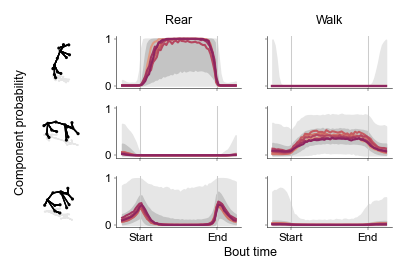

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/i-agewise-traces.pdf')

In [847]:
use_components = [6, 7, 8]
use_bhv = ['rear', 'loco']
n_components = len(use_components)
n_etho = len(use_bhv)
res, buffer = 40, 10

fig, axes = plt.subplots(n_components, n_etho + 1, figsize = (1.3 * n_etho, 1.7), dpi = 150, sharex=True,
    width_ratios=[0.5, 1, 1])
for ax in axes[:, 0]:
    ax.set_visible(False)

col0 = [fig.add_subplot(n_components, n_etho + 1, 1+i*(n_etho + 1), projection='3d') for i in range(n_components)]
for i, (c, ax) in enumerate(zip(use_components, col0)):
    mean = params.pose.means[c]
    mean = features.inflate(mean[None], cfg['features'])[0]
    plotdrop(mean, ax, 'k', 0.15, 0.3, arms = arms, shady=False, shadx=False)


ax = axes[:, 1:]
bins = np.linspace(-buffer - 1e-2, res + buffer + 1e-2, res + 2 * buffer + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2
with tqdm.tqdm(total = len(use_bhv) * n_components ) as pbar:
    for i, k in enumerate(use_bhv):
        for j, c in enumerate(use_components):
            for a, sl in age_groups.items():
                e = examples[k].loc[examples[k].s.isin(sl)]
                y = np.zeros([len(bin_centers)])
                for l, (x1, x2) in enumerate(zip(bins[:-1], bins[1:])):
                    d = e.query("x > @x1 and x <= @x2")[c]
                    
                    y[l] = np.nanmedian(d.values)

                ax[j, i].plot(bin_centers, y, color = age_pal[a], lw = 1)
            
            lo, hi, lo50, hi50 = np.zeros([4, len(bin_centers)])
            for l, (x1, x2) in enumerate(zip(bins[:-1], bins[1:])):
                d = examples[k].query("x > @x1 and x <= @x2")[c]
                lo[l], hi[l] = np.nanquantile(d.values, [0.025, 0.975])
                lo50[l], hi50[l] = np.nanquantile(d.values, [0.25, 0.75])
                

            ax[j, i].fill_between(bin_centers, lo, hi, color = viz.util.lighten('k', 0.9), zorder = -3)
            ax[j, i].fill_between(bin_centers, lo50, hi50, color = viz.util.lighten('k', 0.77), zorder = -2)
            ax[j, i].axvline(0, color = '.8', lw = 0.5, zorder = 1)
            ax[j, i].axvline(res, color = '.8', lw = 0.5, zorder = 1)
            ax[j, i].set_ylim(-0.05, 1.05)
            ax[j, i].set_yticks([0, 1])
            ax[j, i].set_yticklabels(["", ""])
            pbar.update()
        ax[0, i].set_title(bhv_names[k])
        ax[-1, i].set_xticks([0, res])
        ax[-1, i].set_xticklabels(["Start", "End"])


ax[1, 0].set_yticks([0, 1])
for a in ax[:, 0]:
    a.set_yticklabels(["0", "1"])

fig.tight_layout()

col0[1].text2D(-0.25, 0.5, "Component probability", ha = 'center', va = 'center', rotation = 90, transform = col0[1].transAxes)
ax[-1, 0].text(1.07, -0.5, "Bout time", transform=ax[-1, 0].transAxes, ha = 'center', va = 'center')

plotter.finalize(fig, 'i-agewise-traces', tight=False)

#### Bout frame classifier funcs

In [33]:
def create_classification_dataset(XYdf, n_components, s_trn, s_val, i_trn, i_val, trn_max = 10000, val_max = 10000, seed = 42):
    if isinstance(seed, int):
        rng = np.random.default_rng(seed)
    else:
        rng = seed

    trn_df = XYdf.loc[XYdf['s'].isin(s_trn) & (XYdf['i'] >= i_trn[0]) & (XYdf['i'] < i_trn[1])]
    x_trn = trn_df[list(range(n_components))].values
    y_trn = trn_df['label'].values
    if len(x_trn) > trn_max:
        subsample = rng.choice(len(x_trn), trn_max, replace = False)
        x_trn = x_trn[subsample]
        y_trn = y_trn[subsample]
    
    val_df = XYdf.loc[XYdf['s'].isin(s_val) & (XYdf['i'] >= i_val[0]) & (XYdf['i'] < i_val[1])]
    x_val = val_df[list(range(n_components))].values
    y_val = val_df['label'].values
    if len(x_val) > val_max:
        print(len(x_val), val_max)
        subsample = rng.choice(len(x_val), val_max, replace = False)
        x_val = x_val[subsample]
        y_val = y_val[subsample]
    
    return x_trn, y_trn, x_val, y_val

def fit_and_score(classifier, X_trn, y_trn, X_val, y_val, return_trn_confusion = False):
    classifier.fit(X_trn, y_trn)
    trn_yhat = classifier.predict(X_trn)
    val_yhat = classifier.predict(X_val)
    trn_acc = metrics.accuracy_score(y_trn, trn_yhat)
    val_acc = metrics.accuracy_score(y_val, val_yhat)
    val_confusion = metrics.confusion_matrix(y_val, val_yhat)
    if return_trn_confusion:
        trn_confusion = metrics.confusion_matrix(y_trn, trn_yhat)
        return trn_acc, val_acc, val_confusion, trn_confusion
    return trn_acc, val_acc, val_confusion


#### Held out cohort bout classification

#### debugging

<Axes: >

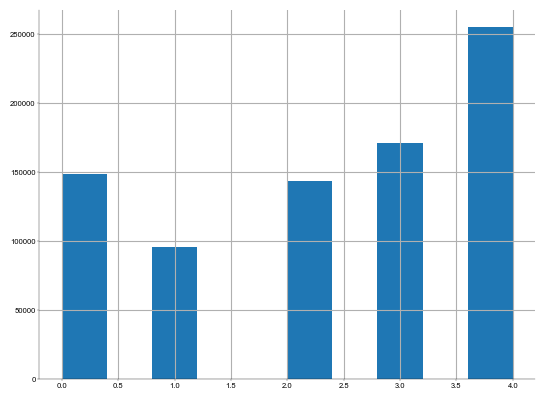

In [697]:
XYdf.label.hist()

3
5
7
24
52
72


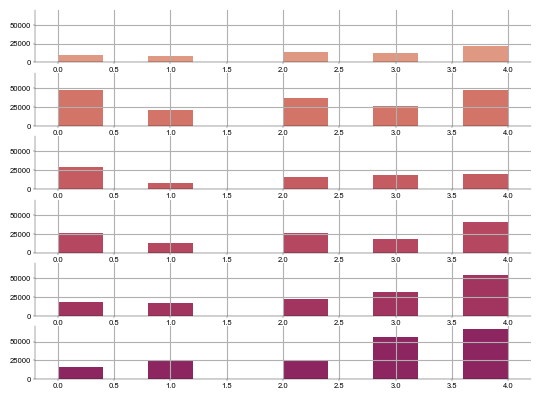

In [715]:
fig, ax = plt.subplots(len(ages), 1, sharey=True)
ages = [ref_age] + tgt_ages
for a, A in zip(ages, ax):
    print(a)
    d = XYdf.query("on")
    d.loc[d.s.isin(age_groups[a])].label.hist(color = age_pal[a], ax = A)


In [732]:
XYdf

,x,on,n,s,i,0,1,2,3,4,5,6,7,8,9,label
0,-10.0,False,0,3wk_m0,0.000000,0.000000e+00,9.916418e-01,0.0,7.535628e-05,1.548958e-18,8.531093e-08,1.714996e-21,2.053911e-05,8.262176e-03,0.000000,0
1,-9.0,False,0,3wk_m0,0.000000,0.000000e+00,9.548039e-01,0.0,6.394826e-05,1.838080e-17,1.877119e-07,7.548771e-20,5.730948e-06,4.512616e-02,0.000000,0
2,-8.0,False,0,3wk_m0,0.000000,0.000000e+00,6.712347e-01,0.0,1.833525e-05,4.610200e-18,3.199303e-07,1.174772e-18,3.867792e-07,3.287462e-01,0.000000,0
3,-7.0,False,0,3wk_m0,0.000000,0.000000e+00,2.902987e-06,0.0,2.857654e-13,0.000000e+00,4.812980e-08,2.742462e-17,3.604110e-18,9.999971e-01,0.000000,0
4,-6.0,False,0,3wk_m0,0.000000,0.000000e+00,1.070233e-12,0.0,2.986176e-21,0.000000e+00,1.047387e-09,4.267306e-17,0.000000e+00,1.000000e+00,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319110,46.0,False,18804,52wk_m5,0.989011,8.100105e-05,4.660115e-04,0.0,7.765060e-03,0.000000e+00,8.123305e-07,0.000000e+00,1.136452e-04,1.644949e-09,0.991573,2
319111,47.0,False,18804,52wk_m5,0.989011,2.209478e-03,3.524194e-04,0.0,4.420739e-02,0.000000e+00,2.273279e-07,0.000000e+00,2.171568e-02,3.859824e-10,0.931515,2
319112,48.0,False,18804,52wk_m5,0.989011,1.045493e-04,2.882803e-04,0.0,1.587398e-01,0.000000e+00,8.224210e-07,0.000000e+00,7.026381e-01,8.304711e-11,0.138228,2
319113,49.0,False,18804,52wk_m5,0.989011,3.008446e-06,1.272167e-04,0.0,4.490746e-01,0.000000e+00,1.212637e-05,0.000000e+00,4.591580e-01,5.101779e-10,0.091625,2


In [ ]:
XY

(1189599, 16)
(597685, 16)
AGE: 3
LABELS: {2: 26650, 3: 9416, 0: 7251, 1: 6456}
TRAIN: (10000, 10) (10000,)
  VAL: (10000, 10) (10000,)
AGE: 5
LABELS: {2: 62310, 0: 35274, 3: 19436, 1: 15659}
TRAIN: (10000, 10) (10000,)
  VAL: (10000, 10) (10000,)
AGE: 7
LABELS: {2: 26713, 0: 21185, 3: 13499, 1: 6049}
TRAIN: (10000, 10) (10000,)
  VAL: (10000, 10) (10000,)
AGE: 24
LABELS: {2: 48887, 0: 18885, 3: 12800, 1: 9649}
TRAIN: (10000, 10) (10000,)
  VAL: (10000, 10) (10000,)
AGE: 52
LABELS: {2: 56238, 3: 22638, 0: 13194, 1: 12727}
TRAIN: (10000, 10) (10000,)
  VAL: (10000, 10) (10000,)
AGE: 72
LABELS: {2: 68685, 3: 40794, 1: 17364, 0: 11679}
TRAIN: (10000, 10) (10000,)
  VAL: (10000, 10) (10000,)


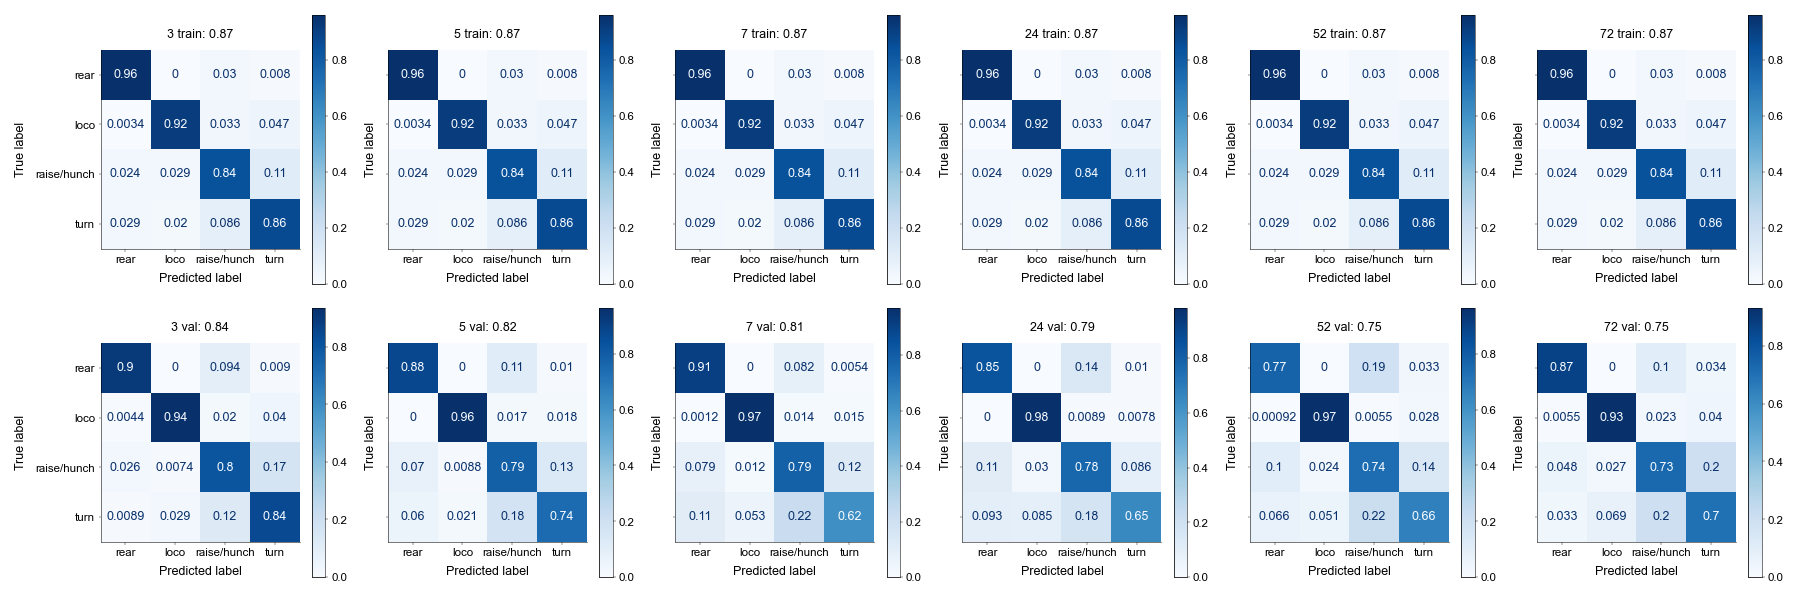

In [746]:
fig, ax = plt.subplots(2, len(ages), figsize = (2 * len(ages), 4), dpi = 150, sharey=True)
bhv_labels = {'rear': 0, 'loco': 1, 'raise': 2, 'turn': 3, 'hunch': 2}
label_names = ['rear', 'loco', 'raise/hunch', 'turn']
XYdf = pd.concat([examples[k].assign(label = bhv_labels[k]) for i, k in enumerate(bhv_order)])
print(XYdf.shape)
XYdf = XYdf.query("on and (x >= 5 and x <= 35)")
print(XYdf.shape)
n_components = params.pose.n_components

for a, A in zip(ages, ax.T):
    print("AGE:", a)
    print("LABELS:", XYdf[XYdf.s.isin(age_groups[a])].label.value_counts().to_dict())
    Xt, yt, Xv, yv = create_classification_dataset(XYdf, n_components, age_groups['3'], age_groups[a], [0, 0.6], [0.6, 1], trn_max = 10000, val_max = 10000)
    print("TRAIN:", Xt.shape, yt.shape)
    print("  VAL:", Xv.shape, yv.shape)
    classifier = RandomForestClassifier(max_depth=5, n_estimators=20, max_features=2, random_state=43, class_weight='balanced')
    trn_acc, val_acc, val_confusion, trn_confusion = fit_and_score(classifier, Xt, yt, Xv, yv, return_trn_confusion = True)
    
    from sklearn.metrics import ConfusionMatrixDisplay
    trn_confusion = trn_confusion / trn_confusion.sum(axis = 1, keepdims = True)
    val_confusion = val_confusion / val_confusion.sum(axis = 1, keepdims = True)
    ConfusionMatrixDisplay(trn_confusion, display_labels = label_names).plot(ax = A[0], cmap = 'Blues')
    ConfusionMatrixDisplay(val_confusion, display_labels = label_names).plot(ax = A[1], cmap = 'Blues')
    A[0].set_title(f"{a} train: {trn_acc:.2f}")
    A[1].set_title(f"{a} val: {val_acc:.2f}")

plotter.finalize(fig, None)


#### actual plot

In [30]:

for a in iit.product(ages):
    print(k, a, len(examples[k][examples[k].s.isin(age_groups[a])].query('on and (x >= 5 and x <= 35)')))

rear 3 8698
rear 5 35274
rear 7 21185
rear 24 18885
rear 52 13194
rear 72 11679
loco 3 8258
loco 5 15659
loco 7 6049
loco 24 9649
loco 52 12727
loco 72 17364
raise 3 12940
raise 5 26678
raise 7 11765
raise 24 18936
raise 52 16147
raise 72 19121
turn 3 15447
turn 5 19436
turn 7 13499
turn 24 12800
turn 52 22638
turn 72 40794
hunch 3 18677
hunch 5 35632
hunch 7 14948
hunch 24 29951
hunch 52 40091
hunch 72 49564


In [37]:
examples = compute_bhv_example_dataframes(
    pose_logprobs, sup_bhv_intervals, 40, 10, probs_are_log=True
)



n_components = params.pose.n_components
bhv_labels = {'rear': 0, 'loco': 1, 'raise': 2, 'turn': 3, 'hunch': 2}
label_names = ['rear', 'loco', 'raise/hunch', 'turn']
XYdf = pd.concat([examples[k].assign(label = bhv_labels[k]) for i, k in enumerate(bhv_order)])
XYdf = XYdf.query("on and (x >= 5 and x <= 35)")
XYdf = XYdf.dropna()
# XYdf = XYdf.groupby('n').agg({c: ('first' if c in ['s', 'label'] else 'median') for c in XYdf.columns})
ages = [ref_age] + tgt_ages
age_groups = {
    a: [ s for s in dataset_feats.sessions if re.search(r"(\d+)wk", s).group(1) == a ]
    for a in ages
}

scores = {"out": [], "trn_acc": [], "val_acc": [], "trn_null": [], **{f"by_bhv-{k}": [] for k in label_names}}
n_iter = 5
rng = np.random.default_rng(48)

with tqdm.tqdm(total = (len(age_groups) - 1) * n_iter) as pbar:
    for a, age_group in age_groups.items():
        if a == '3':
            continue
        for i in range(n_iter):
            # trn_s = [s for s in dataset_feats.sessions if s not in age_group]
            trn_s = age_groups['3']
            val_s = age_group

            Xt, yt, Xv, yv = create_classification_dataset(XYdf, n_components, trn_s, val_s, (0, 1), (0, 1), trn_max=30000, val_max=30000, seed=rng)
            classifier = RandomForestClassifier(max_depth=5, n_estimators=20, max_features=2, random_state=43, class_weight='balanced')
            # classifier = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=43)
            trn_acc, val_acc, val_confusion = fit_and_score(classifier, Xt, yt, Xv, yv)
            scores["out"].append(a)
            scores["trn_acc"].append(trn_acc)
            scores["val_acc"].append(val_acc)
            by_bhv_acc = np.diag(val_confusion / val_confusion.sum(axis = 1, keepdims = True))
            
            for i, k in enumerate(label_names):
                scores[f'by_bhv-{k}'].append(by_bhv_acc[i])

            shuf_yt = rng.permutation(yt)
            trn_acc, val_acc, val_confusion = fit_and_score(classifier, Xt, shuf_yt, Xv, yv)
            scores["trn_null"].append(trn_acc)
            pbar.update()

scores = pd.DataFrame(scores)

/var/folders/yl/fzvpkkfs7md45qk6gcq3q27r0000gn/T/ipykernel_32095/3913554723.py:12: RuntimeWarning: invalid value encountered in divide
  probs /= probs.sum(axis = 1, keepdims = True)
  0%|          | 0/25 [00:00<?, ?it/s]

132615 30000


  4%|▍         | 1/25 [00:00<00:12,  1.87it/s]

132615 30000


  8%|▊         | 2/25 [00:01<00:12,  1.91it/s]

...

 92%|█████████▏| 23/25 [00:12<00:01,  1.90it/s]

138511 30000


 96%|█████████▌| 24/25 [00:12<00:00,  1.90it/s]

138511 30000


100%|██████████| 25/25 [00:13<00:00,  1.90it/s]


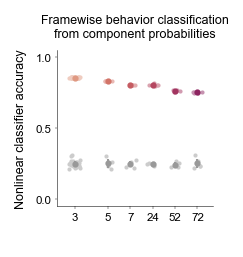

In [38]:
fig, ax = plt.subplots(1, 1, figsize = (1.5, 1.7), dpi = 150)
age_order = sorted(age_groups.keys(), key=lambda x: int(x))
for i, a in enumerate(tgt_ages):
    viz.util.grouped_stripplot(
        [scores.query("out == @a")['val_acc'].values],
        x = [i],
        ax = ax,
        colors = age_pal[a],
        points_kw={'ms': 2, 'mew': 0},
        jitter = 0.25,
        lighten_points=0.5,
        errorbar_kw={'lw': 0.5, 'ms': 2},
        # labels='true'
    )
    viz.util.grouped_stripplot(
        [scores.query("out == @a")['trn_null'].values],
        x = [i],
        ax = ax,
        colors = '.6',
        points_kw={'ms': 2, 'mew': 0},
        jitter=0.25,
        lighten_points=0.5,
        errorbar_kw={'lw': 0.5, 'ms': 2},
        # labels='shuffle'
    )

viz.util.grouped_stripplot(
    [scores['trn_acc'].values],
    x = [-1.5],
    ax = ax,
    colors = age_pal['3'],
    points_kw={'ms': 2, 'mew': 0},
    jitter = 0.25,
    lighten_points=0.5,
    errorbar_kw={'lw': 0.5, 'ms': 2},
)
viz.util.grouped_stripplot(
    [scores['trn_null'].values],
    x = [-1.5],
    ax = ax,
    colors = '.6',
    points_kw={'ms': 2, 'mew': 0},
    jitter = 0.25,
    lighten_points=0.5,
    errorbar_kw={'lw': 0.5, 'ms': 2},
)

ax.set_xticks([-1.5] + list(range(len(tgt_ages))))
ax.set_xticklabels(ages)
ax.set_xlim(-2.3, len(tgt_ages) - 0.3)
ax.set_xlabel(" ")
ax.set_ylabel("Nonlinear classifier accuracy")
ax.set_title("Framewise behavior classification\nfrom component probabilities")
ax.set_ylim(-0.05, 1.05)
ax.set_yticks([0, 0.5, 1])
# viz.util.legend(ax, viz.util.unique_handles(ax))
plotter.finalize(fig, 'j-classification-acc', save=False)

#### quick check: raw / rigid GMM (no clean result)

In [775]:
from sklearn.mixture import GaussianMixture as GMM
raw, _ = unalign_scales(_align_meta, dataset_versions['aligned'], None, None)
raw_full, _ = unalign_scales(_align_meta, dataset_versions_full['aligned'], None, None)
nfeat = arms.n_kpts * 3
raw_feats = raw._data.reshape(-1, nfeat)
rawgmm = GMM(n_components=params.pose.n_components).fit(raw_feats)

In [777]:
rigid_pose_logprobs = {s: rawgmm.predict_proba(raw_full.get_session(s).reshape(-1, nfeat)) for s in dataset_feats.sessions}
rigid_examples = compute_bhv_example_dataframes(
    rigid_pose_logprobs, sup_bhv_intervals, 40, 10, probs_are_log=False
)

n_components = params.pose.n_components
bhv_labels = {'rear': 0, 'loco': 1, 'raise': 2, 'turn': 3, 'hunch': 2}
label_names = ['rear', 'loco', 'raise/hunch', 'turn']
rXYdf = pd.concat([rigid_examples[k].assign(label = bhv_labels[k]) for i, k in enumerate(bhv_order)])
rXYdf = rXYdf.query("on and (x >= 5 and x <= 35)")
# rXYdf = rXYdf.groupby('n').agg({c: ('first' if c in ['s', 'label'] else 'median') for c in rXYdf.columns})


rigid_scores = {"out": [], "trn_acc": [], "val_acc": [], "trn_null": [], **{f"by_bhv-{k}": [] for k in label_names}}
n_iter = 5
rng = np.random.default_rng(48)

with tqdm.tqdm(total = len(age_groups) * n_iter) as pbar:
    for a, age_group in age_groups.items():
        if a == '3':
            continue
        for i in range(n_iter):
            # trn_s = [s for s in dataset_feats.sessions if s not in age_group]
            trn_s = age_groups['3']
            val_s = age_group

            Xt, yt, Xv, yv = create_classification_dataset(rXYdf, n_components, trn_s, val_s, (0, 1), (0, 1), trn_max=5000, val_max=5000, seed=rng)
            classifier = RandomForestClassifier(max_depth=5, n_estimators=20, max_features=2, random_state=43, class_weight='balanced')
            trn_acc, val_acc, val_confusion = fit_and_score(classifier, Xt, yt, Xv, yv)
            rigid_scores["out"].append(a)
            rigid_scores["trn_acc"].append(trn_acc)
            rigid_scores["val_acc"].append(val_acc)
            by_bhv_acc = np.diag(val_confusion / val_confusion.sum(axis = 1, keepdims = True))
            
            for i, k in enumerate(label_names):
                rigid_scores[f'by_bhv-{k}'].append(by_bhv_acc[i])

            shuf_yt = rng.permutation(yt)
            trn_acc, val_acc, val_confusion = fit_and_score(classifier, Xt, shuf_yt, Xv, yv)
            rigid_scores["trn_null"].append(trn_acc)
            pbar.update()

rigid_scores = pd.DataFrame(rigid_scores)

 83%|████████▎ | 25/30 [00:03<00:00,  7.47it/s]


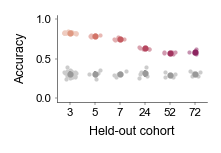

In [784]:
fig, ax = plt.subplots(1, 1, figsize = (1.5, 1), dpi = 150)
age_order = sorted(age_groups.keys(), key=lambda x: int(x))
for i, a in enumerate(tgt_ages):
    viz.util.grouped_stripplot(
        [rigid_scores.query("out == @a")['val_acc'].values],
        x = [i],
        ax = ax,
        colors = age_pal[a],
        points_kw={'ms': 2, 'mew': 0},
        jitter = 0.25,
        lighten_points=0.5,
        errorbar_kw={'lw': 0.5, 'ms': 2},
        # labels='true'
    )
    viz.util.grouped_stripplot(
        [rigid_scores.query("out == @a")['trn_null'].values],
        x = [i],
        ax = ax,
        colors = '.6',
        points_kw={'ms': 2, 'mew': 0},
        jitter=0.25,
        lighten_points=0.5,
        errorbar_kw={'lw': 0.5, 'ms': 2},
        # labels='shuffle'
    )

viz.util.grouped_stripplot(
    [rigid_scores['trn_acc'].values],
    x = [-1],
    ax = ax,
    colors = age_pal['3'],
    points_kw={'ms': 2, 'mew': 0},
    jitter = 0.25,
    lighten_points=0.5,
    errorbar_kw={'lw': 0.5, 'ms': 2},
)
viz.util.grouped_stripplot(
    [rigid_scores['trn_null'].values],
    x = [-1],
    ax = ax,
    colors = '.6',
    points_kw={'ms': 2, 'mew': 0},
    jitter = 0.25,
    lighten_points=0.5,
    errorbar_kw={'lw': 0.5, 'ms': 2},
)

ax.set_xticks(range(-1, len(tgt_ages)))
ax.set_xticklabels(ages)
ax.set_xlabel("Held-out cohort")
ax.set_ylabel("Accuracy")
ax.set_ylim(-0.05, 1.05)
# viz.util.legend(ax, viz.util.unique_handles(ax))
plotter.finalize(fig, None)

In [785]:
from sklearn.mixture import GaussianMixture as GMM
_, rigid, _ = canonicalized_and_raw(dataset_feats, merged_params, rescale=False)
_, rigid_full, _ = canonicalized_and_raw(dataset_feats_full, merged_params, rescale=False)
nfeat = arms.n_kpts * 3
rigid_feats = rigid._data.reshape(-1, nfeat)
rigidgmm = GMM(n_components=params.pose.n_components).fit(rigid_feats)
rig_pose_logprobs = {s: rigidgmm.predict_proba(rigid_full.get_session(s).reshape(-1, nfeat)) for s in dataset_feats.sessions}

In [794]:
rig_pose_logprobs = {s: rigidgmm.predict_proba(rigid_full.get_session(s).reshape(-1, nfeat)) for s in dataset_feats.sessions}
rig_examples = compute_bhv_example_dataframes(
    rig_pose_logprobs, sup_bhv_intervals, 40, 10, probs_are_log=False
)

n_components = params.pose.n_components
bhv_labels = {'rear': 0, 'loco': 1, 'raise': 2, 'turn': 3, 'hunch': 2}
label_names = ['rear', 'loco', 'raise/hunch', 'turn']
RXYdf = pd.concat([rig_examples[k].assign(label = bhv_labels[k]) for i, k in enumerate(bhv_order)])
RXYdf = RXYdf.query("on and (x >= 5 and x <= 35)")
# RXYdf = RXYdf.groupby('n').agg({c: ('first' if c in ['s', 'label'] else 'median') for c in RXYdf.columns})


rig_scores = {"out": [], "trn_acc": [], "val_acc": [], "trn_null": [], **{f"by_bhv-{k}": [] for k in label_names}}
n_iter = 5
rng = np.random.default_rng(48)

with tqdm.tqdm(total = len(age_groups) * n_iter) as pbar:
    for a, age_group in age_groups.items():
        if a == '3':
            continue
        for i in range(n_iter):
            # trn_s = [s for s in dataset_feats.sessions if s not in age_group]
            trn_s = age_groups['3']
            val_s = age_group

            Xt, yt, Xv, yv = create_classification_dataset(RXYdf, n_components, trn_s, val_s, (0, 1), (0, 1), trn_max=5000, val_max=5000, seed=rng)
            classifier = RandomForestClassifier(max_depth=5, n_estimators=20, max_features=2, random_state=43, class_weight='balanced')
            trn_acc, val_acc, val_confusion = fit_and_score(classifier, Xt, yt, Xv, yv)
            rig_scores["out"].append(a)
            rig_scores["trn_acc"].append(trn_acc)
            rig_scores["val_acc"].append(val_acc)
            by_bhv_acc = np.diag(val_confusion / val_confusion.sum(axis = 1, keepdims = True))
            
            for i, k in enumerate(label_names):
                rig_scores[f'by_bhv-{k}'].append(by_bhv_acc[i])

            shuf_yt = rng.permutation(yt)
            trn_acc, val_acc, val_confusion = fit_and_score(classifier, Xt, shuf_yt, Xv, yv)
            rig_scores["trn_null"].append(trn_acc)
            pbar.update()

rig_scores = pd.DataFrame(rig_scores)

 83%|████████▎ | 25/30 [00:03<00:00,  6.77it/s]


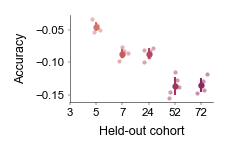

In [796]:
fig, ax = plt.subplots(1, 1, figsize = (1.5, 1), dpi = 150)
age_order = sorted(age_groups.keys(), key=lambda x: int(x))
for i, a in enumerate(tgt_ages):
    viz.util.grouped_stripplot(
        [rig_scores.query("out == @a")['val_acc'].values - rig_scores.query("out == @a")['trn_acc'].values],
        x = [i],
        ax = ax,
        colors = age_pal[a],
        points_kw={'ms': 2, 'mew': 0},
        jitter = 0.25,
        lighten_points=0.5,
        errorbar_kw={'lw': 0.5, 'ms': 2},
        # labels='true'
    )
#     viz.util.grouped_stripplot(
#         [rig_scores.query("out == @a")['trn_null'].values],
#         x = [i],
#         ax = ax,
#         colors = '.6',
#         points_kw={'ms': 2, 'mew': 0},
#         jitter=0.25,
#         lighten_points=0.5,
#         errorbar_kw={'lw': 0.5, 'ms': 2},
#         # labels='shuffle'
#     )

# viz.util.grouped_stripplot(
#     [rig_scores['trn_acc'].values],
#     x = [-1],
#     ax = ax,
#     colors = age_pal['3'],
#     points_kw={'ms': 2, 'mew': 0},
#     jitter = 0.25,
#     lighten_points=0.5,
#     errorbar_kw={'lw': 0.5, 'ms': 2},
# )
# viz.util.grouped_stripplot(
#     [rig_scores['trn_null'].values],
#     x = [-1],
#     ax = ax,
#     colors = '.6',
#     points_kw={'ms': 2, 'mew': 0},
#     jitter = 0.25,
#     lighten_points=0.5,
#     errorbar_kw={'lw': 0.5, 'ms': 2},
# )

ax.set_xticks(range(-1, len(tgt_ages)))
ax.set_xticklabels(ages)
ax.set_xlabel("Held-out cohort")
ax.set_ylabel("Accuracy")
# ax.set_ylim(-0.05, 1.05)
# viz.util.legend(ax, viz.util.unique_handles(ax))
plotter.finalize(fig, None)

### G. Learned TL ratio predicts weight within and across cohort

##### Supporting functions

In [950]:
def frame_spherical_morph(frame_A, frame_B, arms):
    """
    Given two frames of keypoints, construct a copy of B with the joint angles
    of A.
    """
    angles_A = _joint_angles(frame_A, joint_kp_ixs)
    angles_B = _joint_angles(frame_B, joint_kp_ixs)
    lengths_A = _bone_lengths(frame_A, arms)
    lengths_B = _bone_lengths(frame_B, arms)
    return angles_B - angles_A, lengths_B / lengths_A

def frame_tl_morph(frame_A, frame_B):
    lengths_A = _bone_lengths(frame_A, arms)
    lengths_B = _bone_lengths(frame_B, arms)
    back_ix = [bone_names.index(short_names.inverse[b]) for b in ['lo back', 'hi back']]
    tl_A = lengths_A[:, back_ix].mean(axis = 1)
    tl_B = lengths_B[:, back_ix].mean(axis = 1)
    return tl_B / tl_A

def logreg(x, y, eval_x, mode='log'):
    """Fit y = c log(a x + b) + d and evaluate at points.
    
    Parameters
    -----------
    x : np.ndarray
        Independent variable.
    y : np.ndarray
        Dependent variable.
    eval_x : np.ndarray
        Points to evaluate the fit at.
    
    Returns
    --------
    np.ndarray
        Evaluated fit.
    """
    # using scipy.curve_fit
    if mode == 'log':
        def func(x, a, b, c, d):
            # return np.where(a * x + b > 0, c * np.log(a * x + b) + d, 0)
            return c * np.log(a * x + b) + d
    else:
        def func(x, a, b):
            return (a * x + b)
    popt, _ = optimize.curve_fit(func, x, y, maxfev=10000)
    return func(eval_x, *popt)

def logreg_quantile(x, y, eval_x, q, seed = 0, n=50, mode='log'):
    """
    Sampling over subsets of the training data, estimate quantiles of the
    regression's value at `eval_x`."""
    x = np.array(x)
    y = np.array(y)
    rng = np.random.default_rng(seed)
    vals = np.zeros((n, len(eval_x)))
    for i in range(n):
        done = False
        nfail = 0
        while not done:
            try:
                ix = rng.choice(len(x), size = len(x), replace = True)
                vals[i] = logreg(x[ix], y[ix], eval_x, mode=mode)
                done = True
            except RuntimeError:
                nfail += 1
                if nfail > 20:
                    raise

    return np.nanquantile(vals, q, axis = 0)
    


def mae(x, y):
    """Mean asbolute error of independent variable x to dependent variable y
    based on sklearn linearregression"""
    from sklearn.linear_model import LinearRegression
    x = np.array(x)
    y = np.array(y)
    reg = LinearRegression().fit(x.reshape(-1, 1), y)
    return np.mean(np.abs(y - reg.predict(x.reshape(-1, 1))))

#### plots

In [341]:
rescale = True


# ---- canonicalize, compute bone lengths of canonical and raw

canonicalized, raw, scan_align_meta = canonicalized_and_raw(dataset_feats, merged_params, None, rescale, scale_to=scale_to, canon_to=scale_to)
subjwise_bls = {s: frame_spherical_morph(canonicalized.get_session(s), raw.get_session(s), arms)[1] for s in dataset_feats.sessions}
subjwise_tls = {s: frame_tl_morph(canonicalized.get_session(s), raw.get_session(s)) for s in dataset_feats.sessions}

subjwise_mean_bls = {
    s: _bone_lengths(raw.get_session(s), arms).mean(axis = 0) / _bone_lengths(raw.get_session(scale_to), arms).mean(axis = 0)
    for s in dataset_feats.sessions
}
subjwise_mean_tls = {
    s: (_bone_lengths(raw.get_session(s), arms)[:, back_ix].mean(axis = (0, 1)) /
         _bone_lengths(raw.get_session(scale_to), arms)[:, back_ix].mean(axis = (0, 1)))
    for s in dataset_feats.sessions
}


# --- bone lengths of anchor poses

anchors = anchor_keypoints(
    merged_params,
    _align_meta,
    magnitudes=anchor_magnitudes(dataset_feats, params.morph, q = 0.1),
    config=cfg,
    session_meta=dataset_feats.session_meta,
)
n_anchor = anchors.shape[1]
anchors = {s: anchors[dataset_feats.session_id(s)] for s in dataset_feats.sessions}
anchor_bls = {
    s: _bone_lengths(anchors[s], arms) / _bone_lengths(anchors[scale_to], arms)
    for s in dataset_feats.sessions
}

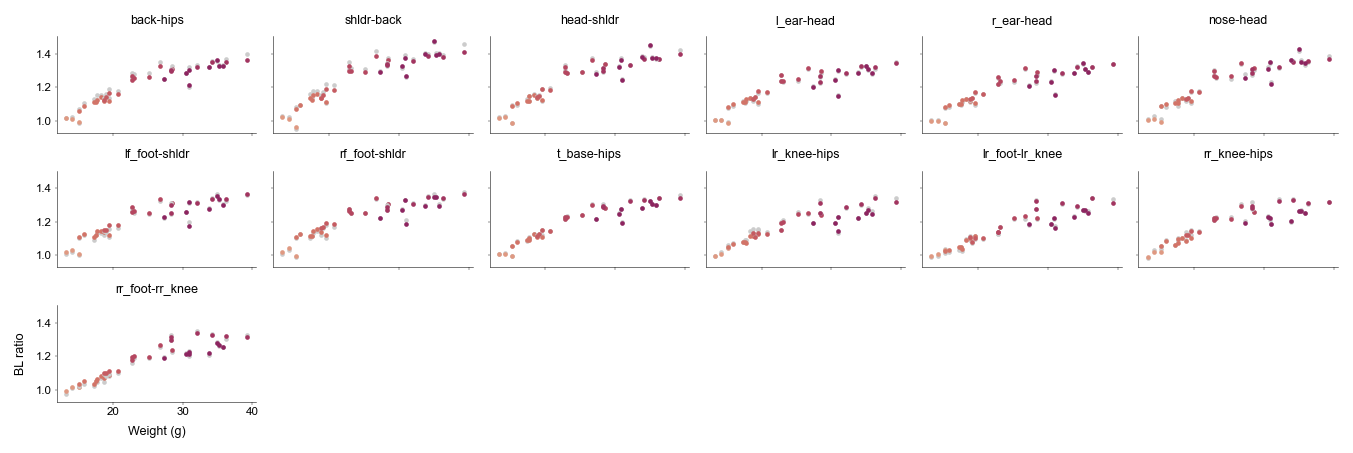

In [332]:
fig, axes, ax_grid = viz.util.flat_grid(arms.n_kpts - 1, min(6, arms.n_kpts - 1), ax_size = (1.5, 1), dpi=150, sharex=True, sharey=True)
age_order = sorted(age_groups.keys(), key=lambda x: int(x))
for i, (bname, ax) in enumerate(zip(bone_names, axes)):
    ax.set_title(bname)
    
    for a in age_order:
        x = np.array([subj_weights[s] for s in age_groups[a] if s != scale_to])
        y = np.array([subjwise_bls[s][:, i].mean() for s in age_groups[a] if s != scale_to])
        y1 = np.array([subjwise_mean_bls[s][i] for s in age_groups[a] if s != scale_to])
        ax.scatter(x, y1, lw=0, s = 5, color='.8', label = "central\ntendency")
        ax.scatter(x, y, lw=0, s = 5, color=age_pal[a], label = "mean, learned\nmorph")
ax_grid[-1, 0].set_xlabel("Weight (g)")
ax_grid[-1, 0].set_ylabel("BL ratio")
fig.tight_layout()

/var/folders/yl/fzvpkkfs7md45qk6gcq3q27r0000gn/T/ipykernel_6369/2876727329.py:41: RuntimeWarning: invalid value encountered in log
  return c * np.log(a * x + b) + d


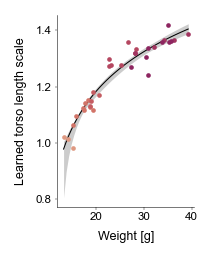

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/h-pop-prediction.pdf')

In [957]:
wmin, wmax = min(subj_weights.values()), max(subj_weights.values())
reg_x = np.linspace(wmin, wmax, 50)
x = np.array([subj_weights[s] for s in dataset_feats.sessions if s != scale_to])
y = np.array([subjwise_tls[s].mean() for s in dataset_feats.sessions if s != scale_to])
# y1 = np.array([subjwise_mean_tls[s] for s in dataset_feats.sessions if s != scale_to])
tl_log = logreg(x, y, reg_x)
tl_log_err = abs(logreg(x, y, x) - y)
tl_log_ci = logreg_quantile(x, y, reg_x, [0.025, 0.975])
# mean_tl_log = logreg(x, y1, reg_x)
# mean_tl_log_err = abs(logreg(x, y1, x) - y)
# mean_tl_log_ci = logreg_quantile(x, y1, reg_x, [0.025, 0.975])

fig, ax = plt.subplots(1, 1, figsize = (1.4, 1.7), dpi=150, sharex=True, sharey=True)
for a in age_order:
    x = np.array([subj_weights[s] for s in age_groups[a] if s != scale_to])
    y = np.array([subjwise_tls[s].mean() for s in age_groups[a] if s != scale_to])
    # y1 = np.array([subjwise_mean_tls[s] for s in age_groups[a] if s != scale_to])
    # ax[1].scatter(x, y1, lw=0, s = 5, color='.7', label = "central\ntendency")
    ax.scatter(x, y, lw=0, s = 5, color=age_pal[a], label = "mean, learned\nmorph")

ax.plot(reg_x, tl_log, 'k', zorder = -2, lw = 0.5)
ax.fill_between(reg_x, tl_log_ci[0], tl_log_ci[1], color = 'k', alpha = 0.2, zorder = -1, lw=0)
# ax[1].plot(reg_x, mean_tl_log, '.4', zorder = -2, lw = 0.5)
# ax[1].fill_between(reg_x, mean_tl_log_ci[0], mean_tl_log_ci[1], color = '.4', alpha = 0.2, zorder = -1, lw  = 0)

ax.set_ylabel("Learned torso length scale")
ax.set_yticks([0.8, 1.0, 1.2, 1.4])
ax.set_xlabel("Weight [g]")

fig.tight_layout()
plotter.finalize(fig, "h-pop-prediction")

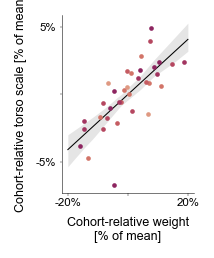

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/h-cohort-prediction.pdf')

In [959]:
reg_x = np.linspace(0.8, 1.2)
fig, ax = plt.subplots(1, 1, figsize = (1.4, 1.7), dpi=150, sharex=True, sharey=True)
xall, yall = [], []
for ia, a in enumerate([a for a in age_order]):

    a_weights = np.array([subj_weights[s] for s in age_groups[a] if s != scale_to])
    a_weights = (a_weights / a_weights.mean())
    a_rtos = np.array([subjwise_bls[s][:, i].mean() for s in age_groups[a] if s != scale_to])
    a_rtos = (a_rtos / a_rtos.mean())
    x = a_weights
    y = a_rtos
    ax.scatter(x, y, lw=0, s = 5, color=age_pal[a], label="mean, learned\nmorph")
    xall.extend(x)
    yall.extend(y)

tl_log = logreg(xall, yall, reg_x, mode='lin')
tl_log_ci = logreg_quantile(xall, yall, reg_x, [0.025, 0.975], mode='lin')
ax.plot(reg_x, tl_log, color='k', zorder = -2, lw = 0.5)
ax.fill_between(reg_x, tl_log_ci[0], tl_log_ci[1], color = 'k', alpha = 0.1, zorder = -3, lw=0)
    
ax.set_xticks(([0.8, 1, 1.2]))
ax.set_xticklabels(["-20%", "", "20%"])
ax.set_yticks([0.95, 1.0, 1.05])
ax.set_yticklabels(["-5%", "", "5%"])

ax.set_xlabel("Cohort-relative weight\n[% of mean]")
ax.set_ylabel("Cohort-relative torso scale [% of mean]")
    
plotter.finalize(fig, "h-cohort-prediction")

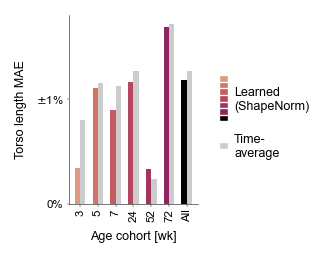

In [962]:
reg_x = np.linspace(0.8, 1.2)
fig, ax = plt.subplots(1, 1, figsize = (1.4, 1.7), dpi=150, sharex=True, sharey=True)
xall, yall, y1all = [], [], []
for ia, a in enumerate([a for a in age_order]):

    a_weights = np.array([subj_weights[s] for s in age_groups[a] if s != scale_to])
    a_weights = (a_weights / a_weights.mean())
    a_rtos = np.array([subjwise_bls[s][:, i].mean() for s in age_groups[a] if s != scale_to])
    a_rtos = (a_rtos / a_rtos.mean())
    a_mean_rtos = np.array([subjwise_mean_bls[s][i] for s in age_groups[a] if s != scale_to])
    a_mean_rtos = a_mean_rtos / a_mean_rtos.mean()
    x = a_weights
    y = a_rtos
    y1 = a_mean_rtos
    
    xall.extend(x)
    yall.extend(y)
    y1all.extend(y1)

    r = mae(x, y)
    r1 = mae(x, y1)

    ax.bar(2*ia+0.2, **viz.util.stem_bar(r, 0, True), color=age_pal[a], width=0.6)
    ax.bar(2*ia+1-0.2, **viz.util.stem_bar(r1, 0, True), color='.8', width=0.6)


r = mae(xall, yall)
r1 = mae(xall, y1all)
ax.bar(2*ia + 2.2, **viz.util.stem_bar(r, 0, True), color='k', width=0.6)
ax.bar(2*ia + 2.8, **viz.util.stem_bar(r1, 0, True), color='.8', width=0.6)

ax.set_xticks(np.arange(0, 2*(len(age_order))+2, 2) + 0.5)
ax.set_xticklabels(age_order + ['All'], rotation=90)

ax.set_ylabel("Torso length MAE")
ax.set_yticks([0, 0.01])
ax.set_yticklabels(["0%", "$\pm$1%"])
ax.set_xlabel("Age cohort [wk]")
fig.tight_layout()

handles = [mpl.patches.Patch(color=age_pal[a], label=f" ") for a in age_order]
handles.append(mpl.patches.Patch(color='k', label=" "))
handles_mean = [mpl.patches.Patch(color='.8', label=" ")]

hkw = dict(handlelength=0.5, handleheight=0.1)
leg = viz.util.legend(ax, (handles, " " * len(ages) + " "), loc='center left', bbox_to_anchor = (1.1, 0.55), labelspacing=-0.3, **hkw)
ax.text(1.28, 0.55, "Learned\n(ShapeNorm)", ha='left', va='center', transform=ax.transAxes)
viz.util.legend(ax, (handles_mean, [" "]), loc='center left', bbox_to_anchor = (1.1, 0.3), labelspacing=0., **hkw)
ax.text(1.28, 0.3, "Time-\naverage", ha='left', va='center', transform=ax.transAxes)
ax.add_artist(leg)

plotter.finalize(fig, None, tight=False)
    

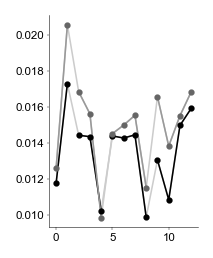

In [509]:

age_order = sorted(age_groups.keys(), key=lambda x: int(x))
r = []
r1 = []
for bi in bone_ix_order:
    xdata = []
    ydata = []
    y1data = []
    for ia, a in enumerate(age_order):
        a_weights = np.array([subj_weights[s] for s in age_groups[a] if s != scale_to])
        a_weights = a_weights / a_weights.mean()
        a_rtos = np.array([subjwise_bls[s][:, bi].mean() for s in age_groups[a] if s != scale_to])
        a_rtos = a_rtos / a_rtos.mean()
        a_mean_rtos = np.array([subjwise_mean_bls[s][bi] for s in age_groups[a] if s != scale_to])
        a_mean_rtos = a_mean_rtos / a_mean_rtos.mean()
        x = a_weights
        y = a_rtos
        y1 = a_mean_rtos
        xdata.extend(x.tolist())
        ydata.extend(y.tolist())
        y1data.extend(y1.tolist())
    
    r.append(mae(xdata, ydata))
    r1.append(mae(xdata, y1data))

r = np.array(r)
r1 = np.array(r1)

fig, ax = plt.subplots(1, 1, figsize = (1.4, 1.7), dpi=150, sharex=True, sharey=True)

ax.plot(r[:], '-', color = '.8', lw = 0.75, zorder = -2)
ax.plot(r1[:], '-', color = '.8', lw = 0.75, zorder = -2)
for bone_group in bone_groups:
    g = np.arange(bone_group[0], bone_group[1] + 1)
    ax.plot(g, r[g], '-', color = 'k', lw = 0.75, label = 'Raw')
    ax.plot(g, r1[g], '-', color = '.6', lw = 0.75, label = 'Canon.')

ax.plot(r[:], 'ko', ms = 2)
ax.plot(r1[:], 'o', color = '.4', ms = 2)

    
fig.tight_layout()
viz.util.legend(axes[-1], viz.util.unique_handles(axes[-1]))

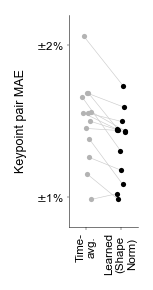

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/h-mae-kpts.pdf')

In [964]:
age_order = sorted(age_groups.keys(), key=lambda x: int(x))
r = []
r1 = []
for bi in range(len(bone_names)):
    xdata = []
    ydata = []
    y1data = []
    for ia, a in enumerate(age_order):
        a_weights = np.array([subj_weights[s] for s in age_groups[a] if s != scale_to])
        a_weights = a_weights / a_weights.mean()
        a_rtos = np.array([subjwise_bls[s][:, bi].mean() for s in age_groups[a] if s != scale_to])
        a_rtos = a_rtos / a_rtos.mean()
        a_mean_rtos = np.array([subjwise_mean_bls[s][bi] for s in age_groups[a] if s != scale_to])
        a_mean_rtos = a_mean_rtos / a_mean_rtos.mean()
        x = a_weights
        y = a_rtos
        y1 = a_mean_rtos
        xdata.extend(x.tolist())
        ydata.extend(y.tolist())
        y1data.extend(y1.tolist())
    
    r.append(mae(xdata, ydata))
    r1.append(mae(xdata, y1data))


fig, ax = plt.subplots(1, 1, figsize = (1, 1.7), dpi=150, sharex=True, sharey=True)

x = viz.util.jitter_points(np.stack([np.zeros_like(r1), np.ones_like(r)]), scale=0.15)   
ax.plot(x, np.stack([r1, r]), '-', color = '.8', lw = 0.3, zorder = -2)
ax.plot(x[0], r1, 'o', color = '.7', ms = 2.5, mew=0, zorder = -1)
ax.plot(x[1], r, 'o', color = 'k', ms = 2.5, mew=0, zorder = -1)
ax.set_xticks([0, 1])

ax.set_ylabel("Keypoint pair MAE")
ax.set_yticks([0.01, 0.02])
ax.set_ylim(0.008, 0.022)
ax.set_yticklabels(["$\pm$1%", "$\pm$2%"])
ax.set_xlim(-0.5, 1.5)
fig.tight_layout()
ax.set_xticklabels(["Time-\navg.", "Learned\n(Shape\nNorm)"], rotation=90)

plotter.finalize(fig, 'h-mae-kpts', tight=False)

In [536]:
canonicalized, raw, scan_align_meta = canonicalized_and_raw(dataset_feats_full, merged_params, None, rescale, scale_to=scale_to, canon_to=scale_to)

subjwise_mean_bls_bhv = {k: {
    s: (_bone_lengths(raw.get_session(s)[bhv_masks[k][s]], arms).mean(axis = 0) /
         _bone_lengths(raw.get_session(scale_to)[bhv_masks[k][scale_to]], arms).mean(axis = 0))
    for s in dataset_feats.sessions
}for k in bhv_keys}

In [545]:
bhv_weights = [bhv_masks[k][scale_to].mean() for k in bhv_order]
bhv_weights = {k: w / sum(bhv_weights) for k, w in zip(bhv_order, bhv_weights)}
subjwise_mean_bls_samp = {
    s: np.sum([bhv_weights[k] * subjwise_mean_bls_bhv[k][s] for k in bhv_order], axis = 0)
    for s in dataset_feats.sessions
}

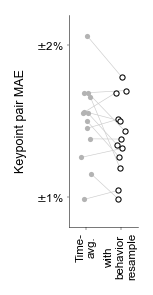

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f5_learns-ontog/h-resampled-bhv.pdf')

In [577]:
age_order = sorted(age_groups.keys(), key=lambda x: int(x))

fig, ax = plt.subplots(1, 1, figsize = (1, 1.7), dpi=150, sharex=True, sharey=True)

x_tot = viz.util.jitter_points(np.ones(len(bone_names)), scale=0.15)
r_bhv = {k: [] for k in bhv_keys}
r_smp = []
r_avg = []
r_lrn = []

over_mean = lambda x: x / x.mean()
wt_rto = lambda i, b, g: (
    over_mean(np.array([subj_weights[s] for s in g if s != scale_to])),
    over_mean(np.array([b[s][i] for s in g if s != scale_to])),
)


for bi in range(len(bone_names)):
    y3data = []
    x1data = []
    y1data = []
    y4data = []
    
    for ia, a in enumerate(age_order):
        
        x1, y1 = wt_rto(bi, subjwise_mean_bls, age_groups[a])
        _, y3 = wt_rto(bi, subjwise_mean_bls_samp, age_groups[a])
        _, y4 = wt_rto(bi, {s: a.mean(axis = 0) for s, a in subjwise_bls.items()}, age_groups[a])

        x1data.extend(x1.tolist())
        y1data.extend(y1.tolist())
        y3data.extend(y3.tolist())
        y4data.extend(y4.tolist())

    r_avg.append(mae(x1data, y1data))
    r_smp.append(mae(x1data, y3data))
    r_lrn.append(mae(x1data, y4data))


x = viz.util.jitter_points(np.zeros([ len(bhv_keys) + 3, len(bone_names),]), scale=0.15)
ax.plot(x[:2] + np.arange(2)[:, None], np.stack([r_avg, r_smp]), '-', color = '.8', lw = 0.3, zorder = -2)
ax.plot(x[0], r_avg, 'o', color = '.7', ms = 2.5, mew=0, zorder = -1)
ax.plot(x[1] + 1, r_smp, 'wo', mec = 'k', ms = 2.5, mew=0.5, zorder = -1)
ax.set_xticks([0, 1])

ax.set_ylabel("Keypoint pair MAE")
ax.set_yticks([0.01, 0.02])
ax.set_ylim(0.008, 0.022)
ax.set_yticklabels(["$\pm$1%", "$\pm$2%"])
ax.set_xlim(-0.5, 1.5)
fig.tight_layout()
ax.set_xticklabels(["Time-\navg.", "with\nbehavior\nresample"], rotation=90)

plotter.finalize(fig, 'h-resampled-bhv', tight=False)